In [1]:
import camb,sys,os,math,re
from matplotlib import pyplot as plt
import numpy as np
from camb import model
import multiprocessing as mp
from functools import partial
from matplotlib.gridspec import GridSpec
import scipy.integrate as integrate
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

def get_f_nr(z):
    sigma_nu = (4/11)**(1/3)
    N_eff = 4.044
    k_b = 8.617342e-5
    T_gama = 2.7255
    y = mnu/(sigma_nu*N_eff*k_b*T_gama*(1+z))
    Fy=integrate.quad(lambda u: (u**2*np.sqrt(u**2+y**2))/(1+np.exp(u)), 0,300)[0]
    f1=integrate.quad(lambda u: (u**2)/((1+np.exp(u))*np.sqrt(u**2+y**2)), 0,300)[0]
    f_nr = y**2*f1/Fy#*f_nu
    return f_nr
    
def get_a(n,typ): #get array a
    z = [0]*n
    a = [0]*n
    z[0] = z_max
    if typ == 'line':
        a = np.linspace(1/(1+z[0]),1,n+1)
    elif typ =='log':
        log_a = [np.log(1/(1+z[0])),0]
        log_a = interp_line(log_a,n)
        a = np.exp(log_a)
    else:
        print('no such type')
        sys.exit()
    return a

def get_Pk_nonlin(n,typ):
    a = get_a(n,typ)
    z = 1/a-1
    z.sort()
    nz = int(np.ceil(len(z)/n_PK))
    tau_i=[[0]*n_PK for i in range(0,nz)]
    Pk_nonlin = [0]*len(z)
    z_nonlin = [0]*len(z)
    tau = [0]*len(z)
    for i in range(0,nz):
        z_n=z[i*n_PK:(i+1)*n_PK]
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
        pars.omch2=0.122-pars.omnuh2
        pars.InitPower.set_params(ns=ns)
        print('i = %d/%d;z_max = %.3f;len = %d'%(i+1,nz,z_n[-1],len(z_n)))
        pars.set_matter_power(redshifts=z_n, kmax=kmax, nonlinear=True)
        pars.NonLinear = model.NonLinear_both
        results = camb.get_results(pars)
        kh_nonlin, z_nonlin[i*n_PK:i*n_PK+len(z_n)],Pk_nonlin[i*n_PK:i*n_PK+len(z_n)]= results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints = 200,var1='delta_tot',var2='delta_tot')
        tau_i=results.conformal_time(z_n, presorted=True, tol=None)
        tau[i*n_PK:i*n_PK+len(z_n)]=tau_i/299792.458
        pars = 0

    tau.sort()
    return [Pk_nonlin[::-1],'Pk_{HRes,tot}'],kh_nonlin,z_nonlin[::-1],a,tau

def get_Pk_nonlin_CDM(n,typ):
    a = get_a(n,typ)
    z = 1/a-1
    z.sort()
    nz = int(np.ceil(len(z)/n_PK))
    tau_i=[[0]*n_PK for i in range(0,nz)]
    Pk_nonlin_CDM = [0]*len(z)
    Pk_nonlin_nu = [0]*len(z)
    z_nonlin = [0]*len(z)
    tau = [0]*len(z)
    for i in range(0,nz):
        z_n=z[i*n_PK:(i+1)*n_PK]
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
        pars.omch2=0.122-pars.omnuh2
        pars.InitPower.set_params(ns=ns)
        print('i = %d/%d;z_max = %.3f;len = %d'%(i+1,nz,z_n[-1],len(z_n)))
        pars.set_matter_power(redshifts=z_n, kmax=kmax, nonlinear=True)
        pars.NonLinear = model.NonLinear_both
        results = camb.get_results(pars)
        kh_nonlin, z_nonlin[i*n_PK:i*n_PK+len(z_n)],Pk_nonlin_CDM[i*n_PK:i*n_PK+len(z_n)]= results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints = 200,var1='delta_cdm',var2='delta_cdm')
        kh_nonlin, z_nonlin[i*n_PK:i*n_PK+len(z_n)],Pk_nonlin_nu[i*n_PK:i*n_PK+len(z_n)]= results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints = 200,var1='delta_nu',var2='delta_nu')
        tau_i=results.conformal_time(z_n, presorted=True, tol=None)
        tau[i*n_PK:i*n_PK+len(z_n)]=tau_i/299792.458
        pars = 0

    tau.sort()
    return [Pk_nonlin_CDM[::-1],'Pk_{HRes,CDM}'],kh_nonlin,z_nonlin[::-1],a,tau

def get_line(y1,y2,x1,x2,x):
    a = (y2-y1)/(x2-x1)
    b = y1 - a*x1
    y = a*x+b
    return y

def interp_line(arr,ni,a=None):
    if a is None:
        a = range((len(arr)-1)*ni+1)
    # print('len_in=',len(arr)-1)
    arr_new =[]
    for i in range(0,len(arr)-1):
        arr_new.append(arr[i])
        for j in range(1,ni):
            arr_new.append(get_line(arr[i],arr[i+1],a[i*ni],a[i*ni+ni],a[i*ni+j] ))
    arr_new.append(arr[-1])
    arr_new = np.array(arr_new)
    # print('len_out',len(arr_new))
    return arr_new

def interp_quad(arr,ni,a):
    arr_new = []
    # print('len_in=',len(arr)-1)
    for i in range(0,len(arr)-2):
        arr_new.append(arr[i])
        a1 = (arr[i]-arr[i+1])/(a[i*ni]-a[(i+1)*ni])
        a2 = (arr[i+2]-arr[i+1])/(a[(i+2)*ni]-a[(i+1)*ni])
        k = (a1-a2)/(a[i*ni]-a[(i+2)*ni])
        b = a1-k*((a[i*ni]+a[(i+1)*ni]))
        c = (arr[i]-k*a[i*ni]**2-b*a[i*ni])
        for j in range(1,ni):
        #     print('i j inedx',i,j,i*ni+j-1,len(arr_new))
            arr_new.append( k * a[i*ni+j]**2 +b*a[i*ni+j] + c)
    i = len(arr)-2
    arr_new.append(arr[i])
    a1 = (arr[i]-arr[i-1])/(a[i*ni]-a[(i-1)*ni])
    a2 = (arr[i+1]-arr[i])/(a[(i+1)*ni]-a[(i)*ni])
    for j in range(1,ni):
        # print('i j inedx',i,j,i*ni+j-1,len(arr_new))
        k = (a1-a2)/(a[(i-1)*ni]-a[(i+1)*ni])
        b = a1-k*((a[i*ni]+a[(i-1)*ni]))
        c = (arr[i]-k*a[i*ni]**2-b*a[i*ni])
        arr_new.append( k * a[i*ni+j]**2 +b*a[i*ni+j] + c)
    arr_new.append(arr[-1])
    arr_new = np.array(arr_new)
    # print('len_out',len(arr_new))
    return arr_new
 
def exterp_line(arr,ni,a=None):
    arr_new = interp_line(arr[0:2],ni,a)
    for i in range(len(arr)-2):
        for j in range(1,ni):
            arr_new = np.vstack((arr_new, np.array(get_line(arr[i],arr[i+1],a[i*ni],a[i*ni+ni],a[(i+1)*ni+j]))))
        arr_new = np.vstack((arr_new,arr[i+2]))
    # arr_new = np.append(arr_new,arr[-1])
    return arr_new

def exterp_quad(arr,ni,a=None):
    arr_interp = interp_line(arr,ni,a)
    arr_exterp = exterp_line(arr,ni,a)
    # 第三个红移之前用理论内插
    arr_new = list(arr_interp[0:2*ni+1])
    # print('c len',len(arr_new))
    for i in range(2,len(arr)-1):
        a1 = (arr[i]-arr[i-1])/(a[i*ni]-a[(i-1)*ni])
        a2 = (arr[i-2]-arr[i-1])/(a[(i-2)*ni]-a[(i-1)*ni])
        for j in range(1,ni):
            # print('i j inedx',i,j,i*ni+j,len(arr_new))
            k = (a1-a2)/(a[i*ni]-a[(i-2)*ni])
            b = a1-k*((a[i*ni]+a[(i-1)*ni]))
            c = (arr[i]-k*a[i*ni]**2-b*a[i*ni])
            arr_new.append( k * a[i*ni+j]**2 +b*a[i*ni+j] + c)
        arr_new.append(arr[i+1])
        # print('i inedx',i,i*ni+j,len(arr_new))
    arr_new = np.array(arr_new)
    # print('out_len',len(arr_new))
    return arr_new,arr_exterp,arr_interp

def get_nonlin_inter(n,ni,a,Pk_nonlin):
    PK_nonlin_crr = []
    for i in range(n+1):
        PK_nonlin_crr.append(Pk_nonlin[i*ni])
    dk = np.sqrt(PK_nonlin_crr)
    print(dk.shape)
    # dk_i = interp1d(dk,ni,a)
    # dk_e_a = exterp1d_a(dk,ni,a)
    dk_eq,dk_el,dk_il = exterp_quad(dk,ni,a)
    dk_iq = interp_quad(dk,ni,a)
    # Pk_interp_line = dk_il**2
    # Pk_interp_quad = dk_iq**2
    # Pk_exterp_line = dk_el**2
    Pk_exterp_quad = dk_eq**2

    nn = n*ni
    # PK_hr_nu,Pk_nu_nonlin, Pk_nu_lin = nu(Pk_nonlin,tau,z_nonlin,a,kh_nonlin,nn+1)
    # Pk_interp_line_nu,Pk_nu_nonlin, Pk_nu_lin = nu(Pk_interp_line,tau,z_nonlin,a,kh_nonlin,nn+1)
    # Pk_interp_quad_nu,Pk_nu_nonlin, Pk_nu_lin = nu(Pk_interp_quad,tau,z_nonlin,a,kh_nonlin,nn+1)
    # Pk_exterp_line_nu,Pk_nu_nonlin, Pk_nu_lin = nu(Pk_exterp_line,tau,z_nonlin,a,kh_nonlin,nn+1)
    # Pk_exterp_quad_nu,Pk_nu_nonlin, Pk_nu_lin = nu(Pk_exterp_quad,tau,z_nonlin,a,kh_nonlin,nn+1)
    return [
            # [Pk_interp_line,'Pk_{interp,line}'],
            # [Pk_interp_quad,'Pk_{interp,quad}'],
            # [Pk_exterp_line,'Pk_{exterp,line}'],
            [Pk_exterp_quad,'Pk_{exterp,quad}'],
            # [Pk_nu_nonlin,'Pk_{nu,nonlin}'],
            # [Pk_nu_lin,'Pk_{nu,lin}'],
            # [PK_hr_nu,'PK_{nu,HRes}'],
            # [Pk_interp_line_nu,'Pk_{nu,interp,line}'],
            # [Pk_interp_quad_nu,'Pk_{nu,interp,quad}'],
            # [Pk_exterp_line_nu,'Pk_{nu,exterp,line}'],
            # [Pk_exterp_quad_nu,'Pk_{nu,exterp,quad}']
            ]

def L(X):
    T_nu0=0.000168
    L=(1+0.0168*(X*T_nu0*C)**2+0.0407*(X*T_nu0*C)**4)/(1+2.1734*(X*T_nu0*C)**2+1.6787*(X*T_nu0*C)**4.1811+0.1467*(X*T_nu0*C)**8)
    return L

def nu(Pk,tau,z,a,kh_lin,step_num):
    global C
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=omch2-pars.omnuh2
    pars.InitPower.set_params(ns=ns)
    pars.set_matter_power(redshifts=[0,z_max],kmax=kmax)
    pars.NonLinear = model.NonLinear_none
    results = camb.get_results(pars)
    kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
    pars.NonLinear = model.NonLinear_both
    results.calc_power_spectra(pars)
    kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')


    h0=pars.H0/100.0
    M_nu=pars.omnuh2*93.14
    m_nu=M_nu/3.0

    omega_m=(pars.omch2+pars.ombh2+pars.omnuh2)/(h0**2)
    omega_l=1-omega_m
    C=299792.458*h0

    Pk_nu_new=[0]*npbin
    Pk_nu_new1=[0]*npbin
    Pk_nu_new2=[0]*npbin

    s_pre =0
    s_post=0
    s_f=0

    results = camb.get_results(pars)
    H=results.hubble_parameter(z_max)
    H0_local=results.hubble_parameter(0)

    omega_m_zi=(H0_local/H)**2*omega_m*(1+z[0])**3
    omega_l_zi=(H0_local)**2/H**2*omega_l
    f=omega_m_zi**(4.0/7.0)+omega_l_zi/70.0*(1+omega_m_zi/2.0)
    print(H0_local,H,(H0_local/H)**2,omega_m*(1+z[0])**3,(H0_local)**2,H**2)

    for i in range(1,step_num):
        s_f=s_f+0.5*(1/a[i-1]+1/a[i])*(tau[i]-tau[i-1]) #superconformal time s=integral(d(z)/a(z)) 

    print("s_f=",s_f)
        
    for j in range(0,npbin):
        Pk_nu_new1[j]=L(s_f*kh_lin[j]/m_nu)*(Pk_nu_lin[1][j])**(0.5)*(1+s_f*a[0]*a[0]*H*f) #好像不对

    for i in range(1,step_num):
        s_pre=s_post
        s_post=s_pre+0.5*(1/a[i-1]+1/a[i])*(tau[i]-tau[i-1]) #superconformal time s=integral(d(z)/a(z))
        for j in range(0,npbin):
            Pk_nu_new2[j]=Pk_nu_new2[j]+(L((s_f-s_pre)*kh_lin[j]/m_nu)*(Pk[i-1][j])**0.5*(s_f-s_pre)+L((s_f-s_post)*kh_lin[j]/m_nu)*(Pk[i][j])**0.5*(s_f-s_post))*(tau[i]-tau[i-1])/2.0
    for j in range(0,npbin):                                                       
        Pk_nu_new[j] = Pk_nu_new1[j]+Pk_nu_new2[j]*1.5*omega_m*H0_local**2
        Pk_nu_new[j] = Pk_nu_new[j]**2

    return Pk_nu_new,Pk_nu_nonlin[0], Pk_nu_lin[0]

def dplt(ax,kh_nonlin, font,Pk1,Pk2,dPk_max=None,dPk_min=None,sq=True):
    fontsize = font['size']
    if sq:
        dPk = np.sqrt(Pk1[0])/np.sqrt(Pk2[0])-1
        ax.plot(kh_nonlin, dPk, label=r'$\sqrt{%s(k)}/\sqrt{%s(k)}-1$'%(Pk1[1],Pk2[1]), color='g', linewidth=1, linestyle='-')
    else:
        dPk = np.array(Pk1[0])/np.array(Pk2[0])-1
        ax.plot(kh_nonlin, dPk, label=r'$%s(k)/%s(k)-1$'%(Pk1[1],Pk2[1]), color='g', linewidth=1, linestyle='-')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel(r'$k\, [h Mpc^{-1}]$', font)
    ax.set_ylabel('Residuals', font)
    #设置坐标轴的粗细
    ax.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.5, direction='in')
    ax.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax.spines['bottom'].set_linewidth(1);#设置底部坐标轴的粗细
    ax.spines['left'].set_linewidth(1);#设置左边坐标轴的粗细
    ax.spines['right'].set_linewidth(1);#设置右边坐标轴的粗细
    ax.spines['top'].set_linewidth(1);#设置上部坐标轴的粗细
    ax.set_yscale('symlog')  # 使用对数坐标轴，同时保留正负

    # # 设置y轴的范围
    # if dPk_max == None:
    #     dPk_max = np.max(dPk)
    # if dPk_min == None:
    #     dPk_min = np.min(dPk)
    # if abs(dPk_max/dPk_min) > 2:
    #     dPk_min = -dPk_max/2
    # elif abs(dPk_max/dPk_min) < 1/2:
    #     dPk_max = -dPk_min/2
    # # print('dPk:',dPk_min,dPk_max,dPk)
    # ax.set_ylim(dPk_min*1.2,dPk_max*1.2)
    # ax.set_yticks([float('%.1e'%(dPk_min*1.2)),float('%.1e'%(dPk_min*0.8)),float('%.1e'%(dPk_min*0.4)),0,float('%.1e'%(dPk_max*0.4)),float('%.1e'%(dPk_max*0.8)),float('%.1e'%(dPk_max*1.2))])
    # yticks, ytick_labels = plt.yticks()
    # ytick_labels[0].set_text(None)
    # ytick_labels[-1].set_text(None)
    # ax.set_yticklabels(ytick_labels)
    ax.legend(loc='lower right', ncol=1, fontsize=fontsize)
    legend = ax.legend()
    legend.get_frame().set_alpha(0.5)
    return ax

def plot_Pk2k(n, ni, kh_nonlin,stitle, s, Pk, dPk1 = None, dPk2 = None,sq = True,show = 0):
    fig = plt.figure(figsize=(8*size, 6*size))
    if dPk1 == None:
        gs = GridSpec(1, 1, hspace=0.05)
    elif dPk2 == None:
        gs = GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
    else:
        gs = GridSpec(3, 1, height_ratios=[10,3,3], hspace=0.05)
    
    # format the axes
    fontsize = 10*size
    font = {
            'weight': 'normal',
            'size': fontsize,
            }

    Pmax = 0
    Pmin = np.inf
    ax1 = fig.add_subplot(gs[0])
    for Pki in Pk:
        ax1.loglog(kh_nonlin, Pki[0], label=r'$%s(k)$'%Pki[1], color=Pki[2],linewidth=Pki[3], linestyle=Pki[4], alpha=Pki[5])
        # print(Pki[1],np.max(Pki[0]),np.min(Pki[0]))
        Pmax = np.max([np.max(Pki[0]),Pmax])
        Pmin = np.min([np.min(Pki[0]),Pmin])

    ax1.set_xlabel(r'$k\, [h Mpc^{-1}]$', font)
    ax1.set_ylabel(r'$P(k)$', font)
    ax1.set_title(r'${%s}(k)_{(nstep=%d*%d,Z_{max} = %d)}\, \, \,math:%s$'%(stitle,n,ni,z_max,s)+'\n',fontsize=fontsize)
    #设置坐标轴的粗细
    ax1.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
    ax1.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax1.spines['bottom'].set_linewidth(1);#设置底部坐标轴的粗细
    ax1.spines['left'].set_linewidth(1);#设置左边坐标轴的粗细
    ax1.spines['right'].set_linewidth(1);#设置右边坐标轴的粗细
    ax1.spines['top'].set_linewidth(1);#设置上部坐标轴的粗细
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    # 设置y轴的范围
    # print('P',Pmax,Pmin)
    if (Pmax >1 or Pmin<0.1):
        ax1.set_ylim(Pmin*(1/1.5),Pmax*1.5)
    else:
        ax1.set_ylim((1-f_nu)*0.9999,1)
        ax1.set_yscale('linear')
    # ax1.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2, 1e4])
    # yticks, ytick_labels = plt.yticks()
    # ytick_labels[0].set_text(None)
    # ax1.set_yticklabels(ytick_labels)
    ax1.legend(loc='upper right', ncol=1, fontsize=fontsize)
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    ax1.set_xlim(np.min(kh_nonlin)*(1/1.2), np.max(kh_nonlin)*1.2)

    if dPk1 == None:
        None
    else :
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2 = dplt(ax2,kh_nonlin, font,Pk[dPk1[0]],Pk[dPk1[1]],dPk1[2],dPk1[3],sq)

        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_position([0.1, 0.3, 0.8, 0.6])
        ax2.set_position([0.1, 0.1, 0.8, 0.2])
        if dPk2 == None:
            None
        else:
            ax3 = fig.add_subplot(gs[2], sharex=ax1)
            ax3 = dplt(ax3,kh_nonlin, font,Pk[dPk2[0]],Pk[dPk2[1]],dPk2[2],dPk2[3],sq)
            ax1.set_position([0.1, 0.4, 0.8, 0.5])
            ax2.set_position([0.1, 0.25, 0.8, 0.15])
            ax3.set_position([0.1, 0.1, 0.8, 0.15])
            plt.setp(ax2.get_xticklabels(), visible=False)

    stitle = stitle.replace("\\",'')
    if show == 1:
        plt.show()
    else:
        # try: 
        #     os.mkdir(imagepath+'%s/'%(typ))
        #     print('-'*200)
        # except: 
        #     print('*'*200)
        # try: 
        #     os.mkdir(imagepath+'%s/%d/'%(typ,z_max))
        #     print('-'*200)
        # except: 
        #     print('*'*200)
        # fig.savefig(imagepath+'%s/%d/Pk_%s_%d_%d_%d_%s.jpg'%(typ,z_max,sP,z_max,n,ni,s.replace('\\','')),dpi=300)
        os.system('mkdir -p image/%s'%stitle)
        # 关闭图形，但仍然保存图像文件
        plt.close()
        fig.savefig('./image/%s/%.2f_%d_%d_%s.jpg'%(stitle.replace("\\",''),z,n,ni,s.replace('\\','')),dpi=300)
    # plt.close()

def plot_Pk2a(n,ni,a,kh_nonlin,Pk,Pk_in,Pk_ex,s):
    dk = np.sqrt(Pk)
    dk_in = np.sqrt(Pk_in)
    dk_ex = np.sqrt(Pk_ex)
    fig = plt.figure(figsize=(size*8, size*6))
    gs = GridSpec(3, 1, height_ratios=[10,3,3], hspace=0.05)
    # gs = GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
    
    # format the axes
    fontsize = 10*size
    font = {
            'weight': 'normal',
            'size': fontsize,
            }
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(a,dk.T[0]/dk.T[0][1]*a[0],label=r'$\sqrt{Pk_{CAMB}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[0]), color='indianred', linewidth=5, linestyle='-', alpha=0.3)
    ax1.plot(a,dk.T[100]/dk.T[100][1]*a[0],label=r'$\sqrt{Pk_{CAMB}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%0.3f)$'%(a[0],kh_nonlin[100]), color='limegreen', linewidth=5, linestyle='-', alpha=0.3)
    ax1.plot(a,dk.T[120]/dk.T[120][1]*a[0],label=r'$\sqrt{Pk_{CAMB}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[120]), color='royalblue', linewidth=5, linestyle='-', alpha=0.3)
    ax1.plot(a,dk.T[160]/dk.T[160][1]*a[0],label=r'$\sqrt{Pk_{CAMB}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[160]), color='mediumorchid', linewidth=5, linestyle='-', alpha=0.3)
    ax1.plot(a,dk.T[-1]/dk.T[-1][1]*a[0],label=r'$\sqrt{Pk_{CAMB}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[-1]), color='darkorange', linewidth=5, linestyle='-', alpha=0.3)

    ax1.plot(a,dk_in.T[0]/dk.T[0][1]*a[0],label=r'$\sqrt{Pk_{interp}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[0]), color='indianred', linewidth=2, linestyle='--', alpha=0.8)
    ax1.plot(a,dk_in.T[100]/dk.T[100][1]*a[0],label=r'$\sqrt{Pk_{interp}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%0.3f)$'%(a[0],kh_nonlin[100]), color='limegreen', linewidth=2, linestyle='--', alpha=0.8)
    ax1.plot(a,dk_in.T[120]/dk.T[120][1]*a[0],label=r'$\sqrt{Pk_{interp}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[120]), color='royalblue', linewidth=2, linestyle='--', alpha=0.8)
    ax1.plot(a,dk_in.T[160]/dk.T[160][1]*a[0],label=r'$\sqrt{Pk_{interp}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[160]), color='mediumorchid', linewidth=2, linestyle='--', alpha=0.8)
    ax1.plot(a,dk_in.T[-1]/dk.T[-1][1]*a[0],label=r'$\sqrt{Pk_{interp}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(a[0],kh_nonlin[-1]), color='darkorange', linewidth=2, linestyle='--', alpha=0.8)

    ax1.plot(a,dk_ex.T[0]/dk.T[0][1]*a[0],label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),a[0],kh_nonlin[0]), color='red', linewidth=1, linestyle='-.', alpha=0.6)
    ax1.plot(a,dk_ex.T[100]/dk.T[100][1]*a[0],label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%0.3f)$'%(s[-12:].replace('\\','').replace('_',','),a[0],kh_nonlin[100]), color='green', linewidth=1, linestyle='-.', alpha=0.6)
    ax1.plot(a,dk_ex.T[120]/dk.T[120][1]*a[0],label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),a[0],kh_nonlin[120]), color='blue', linewidth=1, linestyle='-.', alpha=0.6)
    ax1.plot(a,dk_ex.T[160]/dk.T[160][1]*a[0],label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),a[0],kh_nonlin[160]), color='indigo', linewidth=1, linestyle='-.', alpha=0.6)
    ax1.plot(a,dk_ex.T[-1]/dk.T[-1][1]*a[0],label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB,a=%.3f}}\times a_{min}(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),a[0],kh_nonlin[-1]), color='darkorange', linewidth=1, linestyle='-.', alpha=0.6)

    ax1.set_xlabel(r'$a$', font)
    ax1.set_ylabel(r'$\sqrt{Pk}/\sqrt{Pk(a=1)}$', font)
    ax1.set_title(r'$Pk(a)_{(nstep=%d*%d,Z_{max} = %d)\,math:%s}$'%(n,ni,z_max,s)+'\n',fontsize=fontsize)
    #设置坐标轴的粗细
    ax1.legend(loc='upper right', ncol=3,fontsize=fontsize*0.8)
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    ax1.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
    ax1.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(0, 1)
    ax1.spines['bottom'].set_linewidth(2);#设置底部坐标轴的粗细
    ax1.spines['left'].set_linewidth(2);#设置左边坐标轴的粗细
    ax1.spines['right'].set_linewidth(2);#设置右边坐标轴的粗细
    ax1.spines['top'].set_linewidth(2);#设置上部坐标轴的粗细


    ax2 = fig.add_subplot(gs[1])
    ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax2.plot(a,dk_in.T[0]/dk.T[0]-1,label=r'$\sqrt{Pk_{interp,line}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(kh_nonlin[0]), color='indianred', linewidth=2, linestyle='--', alpha=0.6)
    ax2.plot(a,dk_in.T[100]/dk.T[100]-1,label=r'$\sqrt{Pk_{interp,line}}/\sqrt{Pk_{CAMB}}-1(k=%0.3f)$'%(kh_nonlin[100]), color='limegreen', linewidth=2, linestyle='--', alpha=0.6)
    ax2.plot(a,dk_in.T[120]/dk.T[120]-1,label=r'$\sqrt{Pk_{interp,line}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(kh_nonlin[120]), color='royalblue', linewidth=2, linestyle='--', alpha=0.6)
    ax2.plot(a,dk_in.T[160]/dk.T[160]-1,label=r'$\sqrt{Pk_{inter,line}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(kh_nonlin[160]), color='mediumorchid', linewidth=2, linestyle='--', alpha=0.6)
    ax2.plot(a,dk_in.T[-1]/dk.T[-1]-1,label=r'$\sqrt{Pk_{interp,line}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(kh_nonlin[-1]), color='darkorange', linewidth=2, linestyle='--', alpha=0.6)

    #设置坐标轴的粗细
    ax2.legend(loc='lower right', ncol=1,  fontsize=fontsize*0.8)
    legend = ax2.legend()
    legend.get_frame().set_alpha(0.5)
    ax2.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
    ax2.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax2.set_xscale('log')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(r'$a$', font)
    ax2.set_ylabel('Residuals', font)
    ax2.spines['bottom'].set_linewidth(2);#设置底部坐标轴的粗细
    ax2.spines['left'].set_linewidth(2);#设置左边坐标轴的粗细
    ax2.spines['right'].set_linewidth(2);#设置右边坐标轴的粗细
    ax2.spines['top'].set_linewidth(2);#设置上部坐标轴的粗细

    ax3 = fig.add_subplot(gs[2])
    ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax3.plot(a,dk_ex.T[0]/dk.T[0]-1,label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),kh_nonlin[0]), color='red', linewidth=2, linestyle='--', alpha=0.6)
    ax3.plot(a,dk_ex.T[100]/dk.T[100]-1,label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB}}-1(k=%0.3f)$'%(s[-12:].replace('\\','').replace('_',','),kh_nonlin[100]), color='green', linewidth=2, linestyle='--', alpha=0.6)
    ax3.plot(a,dk_ex.T[120]/dk.T[120]-1,label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),kh_nonlin[120]), color='blue', linewidth=2, linestyle='--', alpha=0.6)
    ax3.plot(a,dk_ex.T[160]/dk.T[160]-1,label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),kh_nonlin[160]), color='indigo', linewidth=2, linestyle='--', alpha=0.6)
    ax3.plot(a,dk_ex.T[-1]/dk.T[-1]-1,label=r'$\sqrt{Pk_{%s}}/\sqrt{Pk_{CAMB}}-1(k=%.3f)$'%(s[-12:].replace('\\','').replace('_',','),kh_nonlin[-1]), color='darkorange', linewidth=2, linestyle='--', alpha=0.6)

    #设置坐标轴的粗细
    ax3.legend(loc='lower right', ncol=1,fontsize=fontsize*0.8)
    legend = ax3.legend()
    legend.get_frame().set_alpha(0.5)
    ax3.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
    ax3.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax3.set_xscale('log')
    ax3.set_xlim(0, 1)
    ax3.set_xlabel(r'$a$', font)
    ax3.set_ylabel('Residuals', font)
    ax3.spines['bottom'].set_linewidth(2);#设置底部坐标轴的粗细
    ax3.spines['left'].set_linewidth(2);#设置左边坐标轴的粗细
    ax3.spines['right'].set_linewidth(2);#设置右边坐标轴的粗细
    ax3.spines['top'].set_linewidth(2);#设置上部坐标轴的粗细


    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    ax1.set_position([0.1, 0.4, 0.8, 0.5])
    ax2.set_position([0.1, 0.25, 0.8, 0.15])
    ax3.set_position([0.1, 0.1, 0.8, 0.15])
    try: 
        os.mkdir(imagepath+'%s/'%(typ))
        print('-'*200)
    except: 
        print('*'*200)
    try: 
        os.mkdir(imagepath+'%s/%d/'%(typ,z_max))
        print('-'*200)
    except: 
        print('*'*200)
    fig.savefig(imagepath+'%s/%d/dk_%d_%d_%s.jpg'%(typ,z_max,n,ni,s.replace('\\','')),dpi=300)
    # plt.show()
    plt.close()

def match_para(para):
    # 读取Fortran文件
    file_path = '../parameters.f90'
    with open(file_path, 'r') as file:
        content = file.read()

    # 使用正则表达式匹配模式
    pattern = r'parameter\s*::\s*%s\s*=\s*([^\s]+)'%para
    match = re.search(pattern, content)
    # print(match)

    if match:
        variable_value = match.group(1).strip()
        print(f"Variable value of {para}: {variable_value}")
        # sys.stdout.flush()  # 刷新输出缓冲
        return float(variable_value)
    else:
        print("Pattern not found in the file.")
        sys.exit()


In [ ]:
# 绘制测试功率谱
from scipy.stats import gamma
from scipy.interpolate import interp1d

# 加载功率谱
def loadpower(filename,n_row_xi=6):
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

# 计算红移处的功率谱
def cambpower(z):
    # 定义参数
    H0 = 70  # 哈勃常数
    ombh2 = 0.0463  # 普通物质的物质密度参数
    omch2 = 0.2327  # 冷暗物质的物质密度参数
    omk = 0.0  # 曲率密度参数
    w = -1.0  # 物质的状态方程
    kmax = 200.0  # 最大k值

    # 创建CAMB参数对象
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk)
    # pars.InitPower.set_params(ns=ns)
    # pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, omnuh2 = 0, DoLensing = False, w=w, neutrino_hierarchy='degenerate')

    # 设置参数
    # pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy='degenerate')
    # 关闭C_L计算
    pars.InitPower.set_params(As=2.625e-09, ns=0.972, r=0, pivot_scalar=0.05)
    pars.set_matter_power(redshifts=[z], kmax=kmax, nonlinear=True)
    pars.NonLinear = camb.model.NonLinear_none

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1='delta_cdm',var2='delta_cdm')

    pars.NonLinear = camb.model.NonLinear_both

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1='delta_cdm',var2='delta_cdm')
    s_8 = results.get_sigma8()
    return k,pk,pk_lin,s_8

def power_error(k,pk,k_camb,pk_camb):
    
    n=np.array(pk[:,0])
    lower = gamma.ppf(0.1587, a=n, scale=1/n)
    upper = gamma.ppf(0.8413, a=n, scale=1/n)

    interp_camb = interp1d(k_camb,pk_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    pk_i = interp_camb(k)

    return pk_i,pk_i*upper,pk_i*lower

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple', 'brown', 'pink']
path = '/home/cossim/cube_nu/test/200_1024/sigle_nu_200_512_2_0.06_2/'
Redshift = '6.9990'
z_checkpoint = np.loadtxt('../z_checkpoint.txt')
z = float(Redshift)
kh = np.loadtxt(path+'neutrinos/k_values.txt')

# for z in z_checkpoint:
    # Redshift = '%.3f'%z
    # print(Redshift)
for Redshift in ['1.609','1.593','1.480','1.364','1.293']:#,'0.465','0.386','0.160','0.134']:
# if (1):
    try:
        plt.figure(figsize=(12,9))
        # ksimg,xisimg = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_gall.bin')
        # ksim,xi = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_sall.bin')
        # kc,xic = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_coarse.bin')
        kg,xig = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_global.bin')

        # pk = np.loadtxt(path+'neutrinos/Pk_cb_%.4f.txt'%(z))
        # pk,pk_u,pk_l = power_error(ksim,xi,kh,pk)
        # plt.loglog(kh, pk, '--', linewidth=8, color=[.7, .7, .7],label = 'CAMB_nl',alpha=0.5)
        # plt.fill_between(ksim, pk_u,pk_l, color=[.7, .7, .7], alpha=0.2)
        
        # k2,xi2 = loadpower(path+'image1/'+'%.3f_cicpower_1.bin'%z,10)
        # plt.loglog(k2,xi2[:, 2], linewidth=6,alpha=0.3,label = 'Pk_raw,nic=1')
        # plt.loglog(k2,xi2[:, 4], linewidth=7,alpha=0.3,label = 'Pk,nic=1')
        # print(max(kh),min(kh),len(kh))

        # plt.loglog(ksimg[:27],xisimg[:27, 4],'o:',linewidth=4,color=colors[0])
        # plt.loglog(ksimg[26:],xisimg[26:, 4], linewidth=4,alpha=0.3,color=colors[0],label = 'global')

        # plt.loglog(ksim[:27],xi[:27, 4],'o:', linewidth=4,color=colors[3])
        # plt.loglog(ksim[26:],xi[26:, 4], linewidth=4,color=colors[3],label = 'segment')

        plt.loglog(kg[:27],xig[:27, 4],'o:', linewidth=2,color=colors[1])
        plt.loglog(kg[26:],xig[26:, 4], linewidth=5,color=colors[1],label = 'global_c')

        # plt.loglog(kg[:27],xig[:27, 2],'o:', linewidth=2,color=colors[2])
        # plt.loglog(kg[26:],xig[26:, 2], linewidth=5,color=colors[2],label = 'global_raw')
        # try:
        #     ks,xis = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_std.bin')
        #     # plt.loglog(kc[:27],xic[:27, 4],'o:',alpha=0.5,color=colors[4])
        #     # plt.loglog(kc[26:],xic[26:, 4],alpha=0.5,color=colors[4],label = 'PM1')
        #     try:
        #         kf,xif = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_fine.bin')
        #         plt.loglog(ks,xis[:, 4],label = 'PM2',alpha=0.5)
        #         plt.loglog(kf,xif[:, 4],label = 'PM3',alpha=0.5)
        #     except:
        #         plt.loglog(ks,xis[:, 2],label = 'PM2—raw',alpha=0.5)
        # except:
            # plt.loglog(kc,xic[:, 2],alpha=0.5,color=colors[4],label = 'PM1—raw')
        plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
        plt.xlim([min(kh)/1.2, max(kh)*1.2])
        plt.xlabel(r'$k\,[h/{ Mpc}]$')
        plt.ylabel(r'$P(k)$')
        plt.legend(loc='upper right')
        plt.title('$z='+str(Redshift)+r'\,\,\,\,power_{mater}$')
        plt.ylim(1e-4,1e5)
        # 添加上边和右边的坐标轴
        ax = plt.gca()
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        plt.show()
    except:
        print('fall')


In [ ]:
# 测试单功率谱
from scipy.stats import gamma
from scipy.interpolate import interp1d

# 加载功率谱
def loadpower(filename,n_row_xi=6):
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

# 计算红移处的功率谱
def cambpower(z):
    # 定义参数
    H0 = 70  # 哈勃常数
    ombh2 = 0.0463  # 普通物质的物质密度参数
    omch2 = 0.2327  # 冷暗物质的物质密度参数
    omk = 0.0  # 曲率密度参数
    w = -1.0  # 物质的状态方程
    kmax = 200.0  # 最大k值

    # 创建CAMB参数对象
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk)
    # pars.InitPower.set_params(ns=ns)
    # pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, omnuh2 = 0, DoLensing = False, w=w, neutrino_hierarchy='degenerate')

    # 设置参数
    # pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy='degenerate')
    # 关闭C_L计算
    pars.InitPower.set_params(As=2.625e-09, ns=0.972, r=0, pivot_scalar=0.05)
    pars.set_matter_power(redshifts=[z], kmax=kmax, nonlinear=True)
    pars.NonLinear = camb.model.NonLinear_none

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1='delta_cdm',var2='delta_cdm')

    pars.NonLinear = camb.model.NonLinear_both

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1='delta_cdm',var2='delta_cdm')
    s_8 = results.get_sigma8()
    return k,pk,pk_lin,s_8

def power_error(k,pk,k_camb,pk_camb):
    
    n=np.array(pk[:,0])
    lower = gamma.ppf(0.1587, a=n, scale=1/n)
    upper = gamma.ppf(0.8413, a=n, scale=1/n)

    interp_camb = interp1d(k_camb,pk_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    pk_i = interp_camb(k)

    return pk_i,pk_i*upper,pk_i*lower

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple', 'brown', 'pink']
path = '../../output/300_768_2_0.1_1/'
Redshift = '5.927'
z_checkpoint = np.loadtxt('../z_checkpoint.txt')
z = float(Redshift)
kh = np.loadtxt(path+'neutrinos/k_values.txt')

plt.figure(figsize=(12,9))

print(max(kh),min(kh),len(kh))

# ksim,xi = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_sall.bin')
# plt.loglog(ksim[:27],xi[:27, 4],'o:', linewidth=4,color=colors[3])
# plt.loglog(ksim[26:],xi[26:, 4], linewidth=1,color=colors[3],label = 'segment')

# pk = np.loadtxt(path+'neutrinos/Pk_cb_%.4f.txt'%(z))
# pk,pk_u,pk_l = power_error(ksim,xi,kh,pk)
# plt.loglog(kh, pk, '--', linewidth=8, color=[.7, .7, .7],label = 'CAMB_nl',alpha=0.5)
# plt.fill_between(ksim, pk_u,pk_l, color=[.7, .7, .7], alpha=0.2)

# # try :
# #     k2,xi2 = loadpower(path+'image1/'+'%.3f_cicpower_1.bin'%z)

# k2,xi2 = loadpower(path+'image1/'+'%.3f_cicpower_1.bin'%z,10)
# plt.loglog(k2,xi2[:, 2], linewidth=6,alpha=0.3,label = 'Pk_raw,nic=1')
# plt.loglog(k2,xi2[:, 4], linewidth=7,alpha=0.3,label = 'Pk,nic=1')
# print(max(kh),min(kh),len(kh))

# ksimg,xisimg = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_gall.bin')
# plt.loglog(ksimg[:27],xisimg[:27, 4],'o:',linewidth=4,color=colors[0])
# plt.loglog(ksimg[26:],xisimg[26:, 4], linewidth=4,alpha=0.3,color=colors[0],label = 'global')

# kg,xig = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_global.bin')
# plt.loglog(kg[:27],xig[:27, 4],'o:', linewidth=2,color=colors[1])
# plt.loglog(kg[26:],xig[26:, 4], linewidth=5,color=colors[1],label = 'global_c')

kc,xic = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_coarse.bin')
plt.loglog(kc[:27],xic[:27, 4],'o:',alpha=0.5,color=colors[4])
plt.loglog(kc[26:],xic[26:, 4],alpha=0.5,color=colors[4],label = 'PM1')
plt.loglog(kc[:27],xic[:27, 2],'o:',alpha=0.5)
# plt.loglog(kc[26:],xic[26:, 2],alpha=0.5,label = 'PM1-raw')

ks,xis = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_std.bin')
plt.loglog(ks,xis[:, 4],label = 'PM2',alpha=0.5)
plt.loglog(ks,xis[:, 2],label = 'PM2-raw',alpha=0.5)

kf,xif = loadpower(path+'neutrinos/Pk/'+Redshift+'_cicpower_fine.bin')
plt.loglog(kf,xif[:, 4],label = 'PM3',alpha=0.5)
plt.loglog(kf,xif[:, 2],label = 'PM3-raw',alpha=0.5)

plt.axvline(16.0849543864)
# plt.axvline(6.992289)
# plt.axvline(3.516015)
# plt.axhline(7.638595)

plt.xlabel(r'$k\,[h/{ Mpc}]$')
plt.ylabel(r'$P(k)$')
plt.legend(loc='upper right')
plt.title('$z='+str(Redshift)+r'\,\,\,\,power_{mater}$')
# plt.title('$z='+str(z)+'\,\,\,\,power_{mater}$')
plt.xlim([min(kh)/1.2, max(kh)*1.2])
plt.ylim(1e-4,1e5)
# 添加上边和右边的坐标轴
ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
plt.show()

load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/3.102_cicpower_global.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/3.102_cicpower_gall.bin


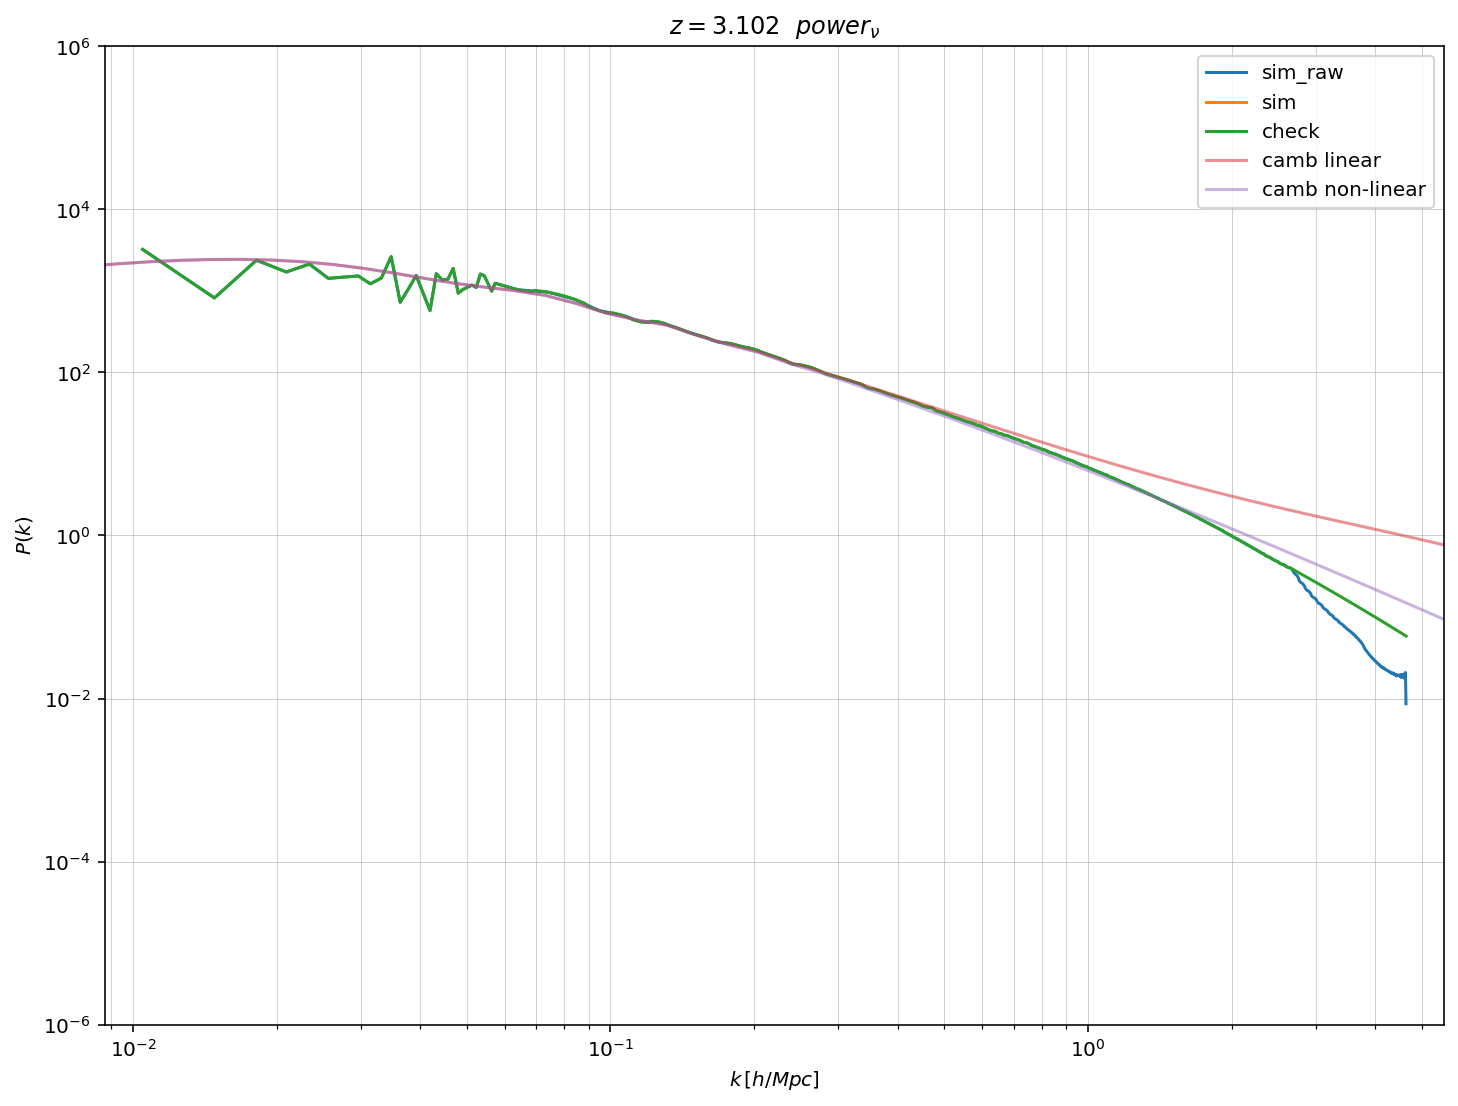

0 1


In [2]:
# 绘制功率谱powerpoint

# 加载功率谱
def loadpower(filename):
    n_row_xi = 6
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

# 计算红移处的功率谱
def cambpower(z):
    # 定义参数
    h0 = 0.6817
    H0 = h0*100  # 哈勃常数
    omch2 = 0.253209016*h0**2  # 普通物质的物质密度参数
    ombh2 = 0.048072486*h0**2  # 冷暗物质的物质密度参数
    omk = 0.0  # 曲率密度参数
    kmax = 200.0  # 最大k值
    neutrino_hierarchy='degenerate'
    num_massive_neutrinos=3
    nnu=3.044
    standard_neutrino_neff=3.044
    ns=0.9693
    As=2.122e-09

    # 创建CAMB参数对象
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=pars.omch2-pars.omnuh2
    pars.InitPower.set_params(As=As,ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax, nonlinear=True)
    pars.NonLinear = camb.model.NonLinear_none

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')

    pars.NonLinear = camb.model.NonLinear_both

    # 计算功率谱
    results = camb.get_results(pars)
    k, zout,pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')
    return k,pk[0],pk_lin[0]

path = '/home/cossim/cube_nu/output/2400_512_1_0.1_1'
path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = np.loadtxt(path+'/neutrinos/z_powerpoint.txt')
# kh = np.loadtxt(path+'/neutrinos/k_values.txt')
ptype = 'tot'
ftype = 'm'
mnu=0.1
i1 = 0
i2 = len(z_step)
ii = 1

counts = 0
for z in z_step[i1:i2][::ii]:
    Redshift = f'{z+0.0001:.3f}'
    ksim,pksim = loadpower(path+f'/neutrinos/Pk/{Redshift}_cicpower_global.bin')
    kh,pk = loadpower(path+f'/neutrinos/Pk/{Redshift}_cicpower_gall.bin')
    if np.sum(pk) == 0:
        # print('z = %s no power spectrum'%Redshift)   
        counts += 1
        continue
    k,pk_nl,pk_lin = cambpower(z)

    plt.figure(figsize=(12,9))
    plt.loglog(ksim,pksim[:,2],label = 'sim_raw',alpha=1)
    plt.loglog(ksim,pksim[:,4],label = 'sim',alpha=1)
    plt.loglog(kh,pk[:,4],label = 'check',alpha=1)
    plt.loglog(k,pk_nl,label = 'camb linear',alpha=0.5)
    plt.loglog(k,pk_lin,label = 'camb non-linear',alpha=0.5)
    plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
    plt.xlim([min(kh)/1.2, max(kh)*1.2])
    plt.xlabel('$k\,[h/{ Mpc}]$')
    plt.ylabel('$P(k)$')
    plt.legend(loc='upper right')
    plt.title('$z='+str(Redshift)+'\,\,\,\,power_{\\nu}$')
    plt.ylim(1e-6,1e6)
    # 添加上边和右边的坐标轴
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    plt.show()
    plt.close()
print(counts,len(z_step[i1:i2][::ii]))

0 1403


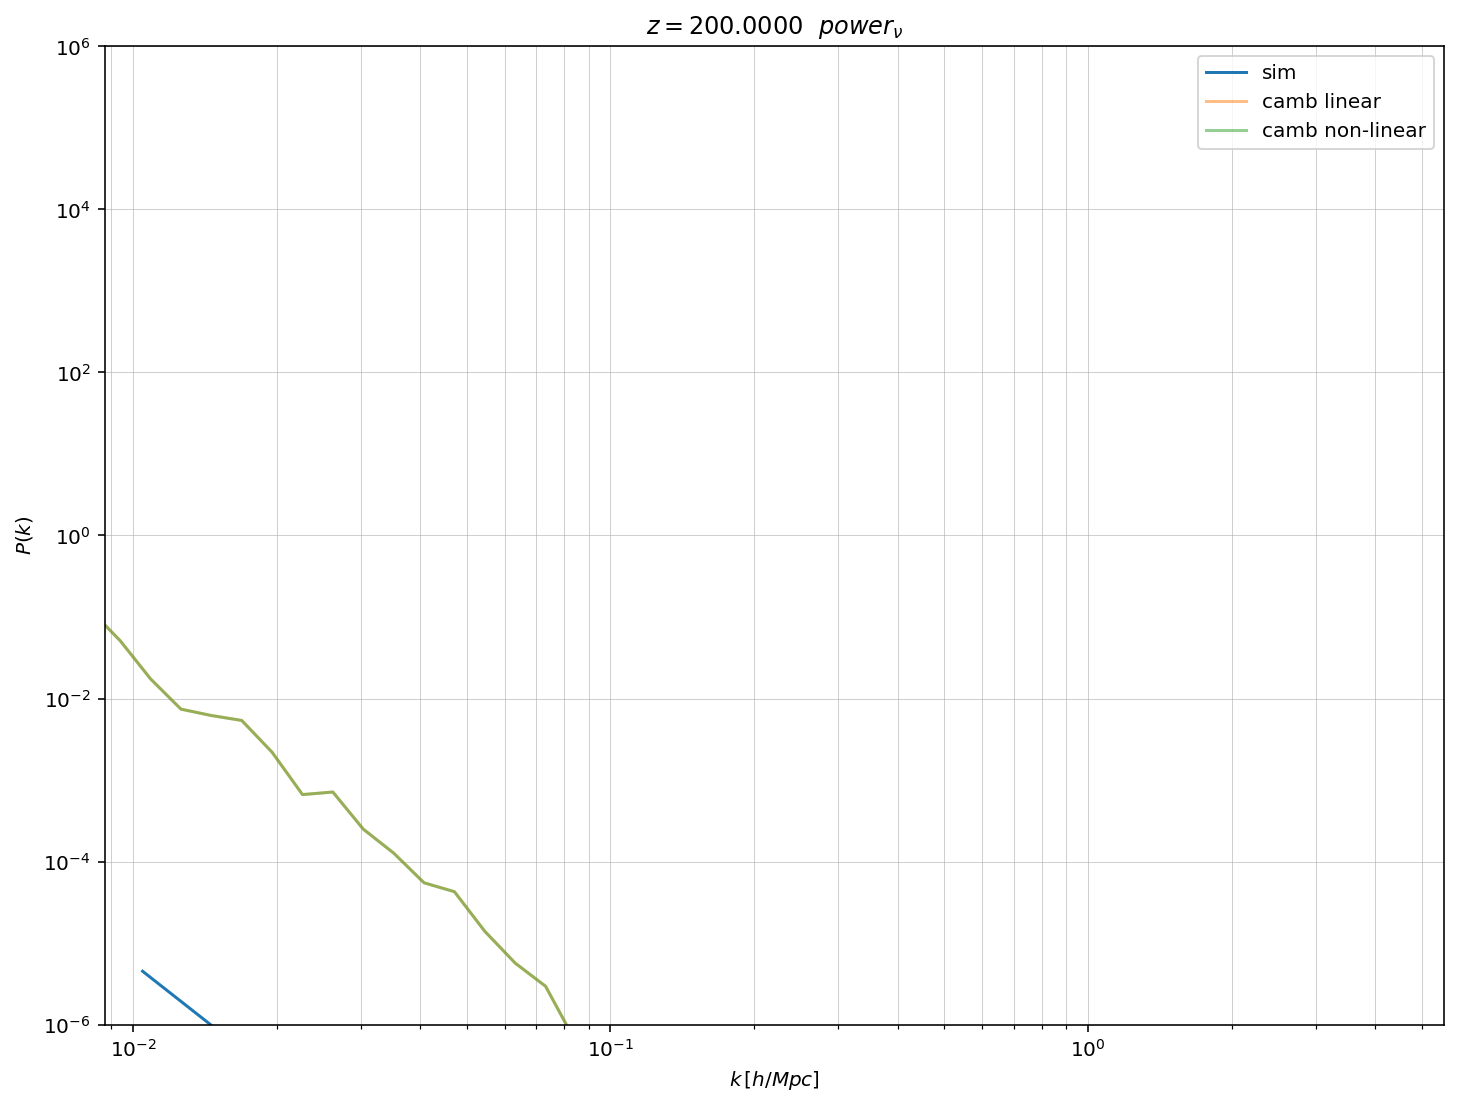

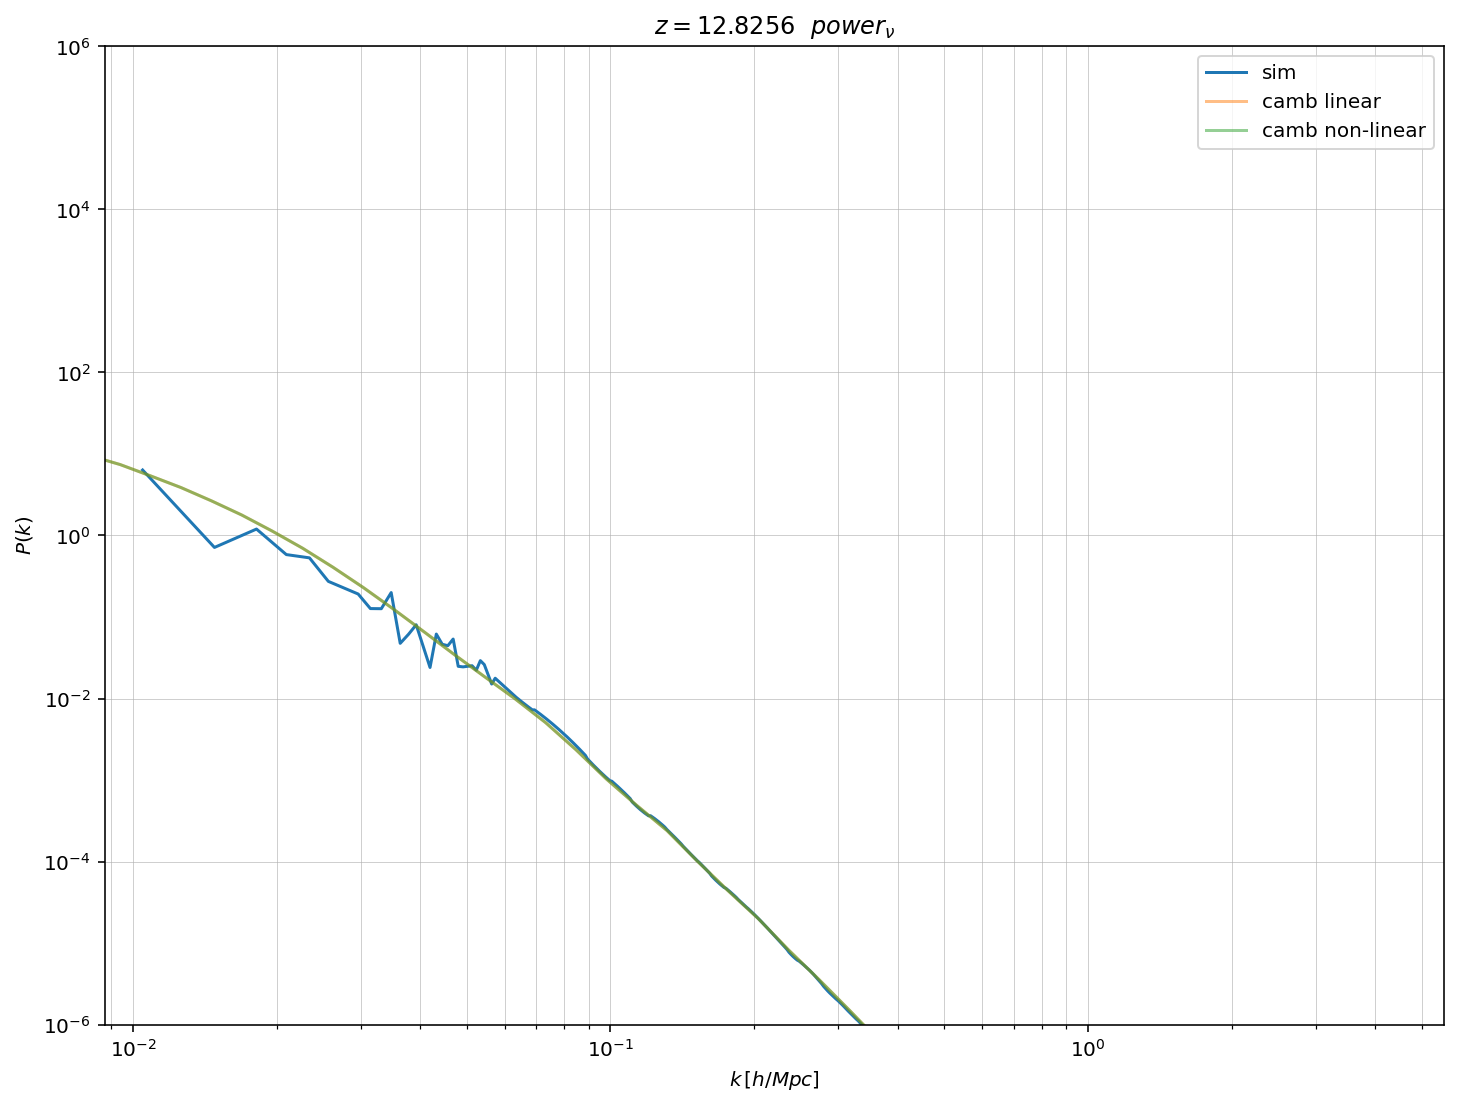

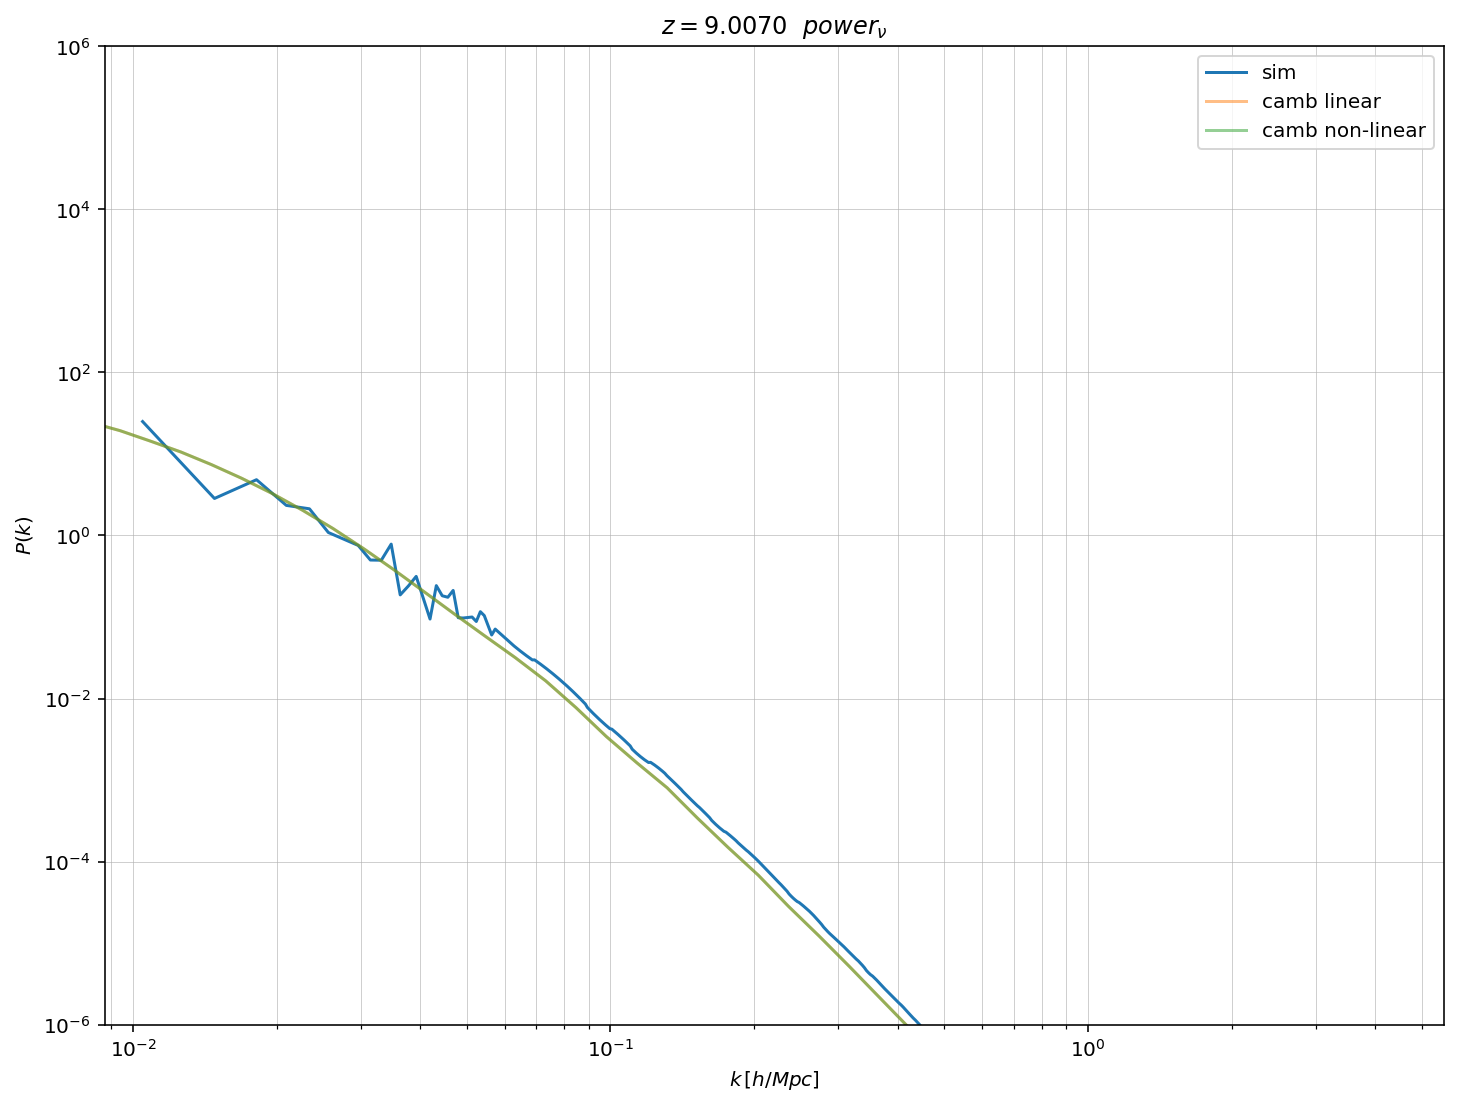

KeyboardInterrupt: 

In [4]:
# 绘制功率谱

# 加载功率谱
def loadpower(filename):
    n_row_xi = 10
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

# 计算红移处的功率谱
def cambpower(z):
    # 定义参数
    h0 = 0.6817
    H0 = h0*100  # 哈勃常数
    omch2 = 0.253209016*h0**2  # 普通物质的物质密度参数
    ombh2 = 0.048072486*h0**2  # 冷暗物质的物质密度参数
    omk = 0.0  # 曲率密度参数
    kmax = 200.0  # 最大k值
    neutrino_hierarchy='degenerate'
    num_massive_neutrinos=3
    nnu=3.044
    standard_neutrino_neff=3.044
    ns=0.9693
    As=2.122e-09

    # 创建CAMB参数对象
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=pars.omch2-pars.omnuh2
    pars.InitPower.set_params(As=As,ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax, nonlinear=True)
    pars.NonLinear = camb.model.NonLinear_none

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')

    pars.NonLinear = camb.model.NonLinear_both

    # 计算功率谱
    results = camb.get_results(pars)
    k, zout,pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')
    return k,pk[0],pk_lin[0]

path = '/home/cossim/cube_nu/output/2400_512_1_0.1_1'
path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = 1/np.fromfile(path+'/neutrinos/a_step.txt', dtype='float32')-1 
kh = np.loadtxt(path+'/neutrinos/k_values.txt')
ptype = 'nu'
ftype = 'nu'
mnu=0.1
i1 = 0
i2 = len(z_step)
ii = 50
print(i1,i2)

counts = 0
for i in range(i1,i2)[::ii]:
    z = z_step[i]
    Redshift = f'{z:.4f}'
    pk = np.fromfile(path+f'/neutrinos/Pk_{ftype}/Pk_{ftype}_{Redshift}.txt', dtype='float32')
    if np.sum(pk) == 0:
        # print('z = %s no power spectrum'%Redshift)   
        counts += 1
        continue
    k,pk_nl,pk_lin = cambpower(z_step[i+1])

    plt.figure(figsize=(12,9))
    plt.loglog(kh,pk,label = 'sim',alpha=1)
    plt.loglog(k,pk_nl,label = 'camb linear',alpha=0.5)
    plt.loglog(k,pk_lin,label = 'camb non-linear',alpha=0.5)
    plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
    plt.xlim([min(kh)/1.2, max(kh)*1.2])
    plt.xlabel('$k\,[h/{ Mpc}]$')
    plt.ylabel('$P(k)$')
    plt.legend(loc='upper right')
    plt.title('$z='+str(Redshift)+'\,\,\,\,power_{\\nu}$')
    plt.ylim(1e-6,1e6)
    # 添加上边和右边的坐标轴
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    plt.show()
    plt.close()
print(counts,len(z_step[i1:i2][::ii]))

In [7]:
from matplotlib.animation import FuncAnimation,PillowWriter
from tqdm import tqdm 

path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = 1 / np.fromfile(os.path.join(path, 'neutrinos/a_step.txt'), dtype='float32') - 1
kh = np.loadtxt(os.path.join(path, 'neutrinos/k_values.txt'))

ptype = 'nu'
ftype = 'nu'
mnu = 0.1
i1 = 0
i2 = len(z_step)
ii = 20  # 步长

# 获取所有要处理的索引
indices = list(range(i1, i2))[::ii]
valid_frames = []  # 存储 (z, pk_sim, k_camb, pk_nl, pk_lin)

print(f"Total frames to process: {len(indices)}")

# === 预加载所有有效帧数据 ===
for i in indices:
    z = z_step[i]
    Redshift = f"{z:.4f}"
    pk_file = os.path.join(path, f'neutrinos/Pk_{ftype}/Pk_{ftype}_{Redshift}.txt')
    
    if not os.path.exists(pk_file):
        print(f"Skip z={z:.4f}: file not found")
        continue
        
    pk = np.fromfile(pk_file, dtype='float32')
    if np.sum(pk) == 0:
        print(f"Skip z={z:.4f}: empty power spectrum")
        continue

    try:
        k_camb, pk_nl, pk_lin = cambpower(z_step[i+1])  # 假设 cambpower 返回 (k, pk_nl, pk_lin)
    except Exception as e:
        print(f"Skip z={z:.4f}: cambpower failed: {e}")
        continue

    valid_frames.append((z, pk, k_camb, pk_nl, pk_lin))

print(f"Valid frames: {len(valid_frames)}")

# === 创建动画 ===
fig, ax = plt.subplots(figsize=(12, 9))

# 设置坐标轴（固定范围）
ax.set_xlim(min(kh)/1.2, max(kh)*1.2)
ax.set_ylim(1e-6, 1e6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$k\,[h/{\rm Mpc}]$')
ax.set_ylabel(r'$P(k)$')
ax.grid(True, which='both', linewidth=0.3)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# 初始化空线条
line_sim, = ax.plot([], [], label='sim', alpha=1)
line_lin, = ax.plot([], [], label='camb linear', alpha=0.5)
line_nl,  = ax.plot([], [], label='camb non-linear', alpha=0.5)
title = ax.set_title('')
ax.legend(loc='upper right')

def animate(frame_idx):
    z, pk_sim, k_camb, pk_nl, pk_lin = valid_frames[frame_idx]
    line_sim.set_data(kh, pk_sim)
    line_lin.set_data(k_camb, pk_lin)
    line_nl.set_data(k_camb, pk_nl)
    title.set_text(rf'$z = {z:.4f},\quad P_{{\nu}}(k)$')
    return line_sim, line_lin, line_nl, title

anim = FuncAnimation(
    fig, animate, frames=tqdm(range(len(valid_frames))),
    interval=100,  # 每帧间隔毫秒（2fps）
    blit=True
)


# === 或保存为 GIF（不推荐用于长序列）===
output_file = f'power_spectrum_evolution_{ftype}.gif'
anim.save(output_file, writer=PillowWriter(fps=10))

plt.close(fig)
print("Done!")

Total frames to process: 71


  0%|          | 0/71 [00:00<?, ?it/s]

Valid frames: 71


  0%|          | 0/71 [00:00<?, ?it/s]


Done!


In [8]:
from matplotlib.animation import FuncAnimation,PillowWriter
from tqdm import tqdm 

path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = 1 / np.fromfile(os.path.join(path, 'neutrinos/a_step.txt'), dtype='float32') - 1
kh = np.loadtxt(os.path.join(path, 'neutrinos/k_values.txt'))

ptype = 'tot'
ftype = 'm'
mnu = 0.1
i1 = 0
i2 = len(z_step)
ii = 20  # 步长

# 获取所有要处理的索引
indices = list(range(i1, i2))[::ii]
valid_frames = []  # 存储 (z, pk_sim, k_camb, pk_nl, pk_lin)

print(f"Total frames to process: {len(indices)}")

# === 预加载所有有效帧数据 ===
for i in indices:
    z = z_step[i]
    Redshift = f"{z:.4f}"
    pk_file = os.path.join(path, f'neutrinos/Pk_{ftype}/Pk_{ftype}_{Redshift}.txt')
    
    if not os.path.exists(pk_file):
        print(f"Skip z={z:.4f}: file not found")
        continue
        
    pk = np.fromfile(pk_file, dtype='float32')
    if np.sum(pk) == 0:
        print(f"Skip z={z:.4f}: empty power spectrum")
        continue

    try:
        k_camb, pk_nl, pk_lin = cambpower(z_step[i+1])  # 假设 cambpower 返回 (k, pk_nl, pk_lin)
    except Exception as e:
        print(f"Skip z={z:.4f}: cambpower failed: {e}")
        continue

    valid_frames.append((z, pk, k_camb, pk_nl, pk_lin))

print(f"Valid frames: {len(valid_frames)}")

# === 创建动画 ===
fig, ax = plt.subplots(figsize=(12, 9))

# 设置坐标轴（固定范围）
ax.set_xlim(min(kh)/1.2, max(kh)*1.2)
ax.set_ylim(1e-6, 1e6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$k\,[h/{\rm Mpc}]$')
ax.set_ylabel(r'$P(k)$')
ax.grid(True, which='both', linewidth=0.3)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# 初始化空线条
line_sim, = ax.plot([], [], label='sim', alpha=1)
line_lin, = ax.plot([], [], label='camb linear', alpha=0.5)
line_nl,  = ax.plot([], [], label='camb non-linear', alpha=0.5)
title = ax.set_title('')
ax.legend(loc='upper right')

def animate(frame_idx):
    z, pk_sim, k_camb, pk_nl, pk_lin = valid_frames[frame_idx]
    line_sim.set_data(kh, pk_sim)
    line_lin.set_data(k_camb, pk_lin)
    line_nl.set_data(k_camb, pk_nl)
    title.set_text(rf'$z = {z:.4f},\quad P_{{\nu}}(k)$')
    return line_sim, line_lin, line_nl, title

anim = FuncAnimation(
    fig, animate, frames=tqdm(range(len(valid_frames))),
    interval=100,  # 每帧间隔毫秒（2fps）
    blit=True
)


# === 或保存为 GIF（不推荐用于长序列）===
output_file = f'power_spectrum_evolution_{ftype}.gif'
anim.save(output_file, writer=PillowWriter(fps=10))

plt.close(fig)
print("Done!")

Total frames to process: 71


  0%|          | 0/71 [00:00<?, ?it/s]

Valid frames: 71


Done!


In [12]:
from matplotlib.animation import FuncAnimation,PillowWriter
from tqdm import tqdm 

path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = np.loadtxt(path+'/neutrinos/z_powerpoint.txt')
ptype = 'tot'
ftype = 'm'
mnu = 0.1
i1 = 0
i2 = len(z_step)
ii = 1  # 步长

# 获取所有要处理的索引
indices = list(range(i1, i2))[::ii]
valid_frames = []  # 存储 (z, pk_sim, k_camb, pk_nl, pk_lin)

print(f"Total frames to process: {len(indices)}")

# === 预加载所有有效帧数据 ===
for i in indices:
    z = z_step[i]
    Redshift = f'{z+0.00001:.3f}'
    pk_file = os.path.join(path, f'neutrinos/Pk/{Redshift}_cicpower_global.bin')
    
    if not os.path.exists(pk_file):
        print(f"Skip z={z:.4f}: file not found")
        print(pk_file)
        continue
        
    ksim,pksim  = loadpower(pk_file)
    if np.sum(pk) == 0:
        print(f"Skip z={z:.4f}: empty power spectrum")
        continue

    pk_file = os.path.join(path, f'neutrinos/Pk/{Redshift}_cicpower_gall.bin')
    if not os.path.exists(pk_file):
        print(f"Skip z={z:.4f}: file not found")
        print(pk_file)
        continue
        
    kh,pk  = loadpower(pk_file)
    if np.sum(pk) == 0:
        print(f"Skip z={z:.4f}: empty power spectrum")
        continue

    try:
        k_camb, pk_nl, pk_lin = cambpower(z_step[i+1])  # 假设 cambpower 返回 (k, pk_nl, pk_lin)
    except Exception as e:
        print(f"Skip z={z:.4f}: cambpower failed: {e}")
        continue

    valid_frames.append((z, ksim, pksim, kh, pk, k_camb, pk_nl, pk_lin))

print(f"Valid frames: {len(valid_frames)}")

# === 创建动画 ===
fig, ax = plt.subplots(figsize=(12, 9))

# 设置坐标轴（固定范围）
ax.set_xlim(min(kh)/1.2, max(kh)*1.2)
ax.set_ylim(1e-6, 1e6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$k\,[h/{\rm Mpc}]$')
ax.set_ylabel(r'$P(k)$')
ax.grid(True, which='both', linewidth=0.3)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# 初始化空线条
line_sim, = ax.plot([], [], label='sim', alpha=1)
line_raw, = ax.plot([], [], label='sim_raw', alpha=1)
line_check, = ax.plot([], [], label='check', alpha=1)
line_lin, = ax.plot([], [], label='camb linear', alpha=0.5)
line_nl,  = ax.plot([], [], label='camb non-linear', alpha=0.5)
title = ax.set_title('')
ax.legend(loc='upper right')

def animate(frame_idx):
    z, ksim, pksim, kh, pk, k_camb, pk_nl, pk_lin = valid_frames[frame_idx]
    line_sim.set_data(ksim, pksim[:,4])
    line_raw.set_data(ksim, pksim[:,2])
    line_check.set_data(kh, pk[:,4])
    line_lin.set_data(k_camb, pk_lin)
    line_nl.set_data(k_camb, pk_nl)
    title.set_text(rf'$z = {z:.4f},\quad P_{{\nu}}(k)$')
    return line_sim, line_lin, line_nl, title

anim = FuncAnimation(
    fig, animate, frames=tqdm(range(len(valid_frames))),
    interval=100,  # 每帧间隔毫秒（2fps）
    blit=True
)


# === 或保存为 GIF（不推荐用于长序列）===
output_file = f'power_spectrum_evolution_{ftype}.gif'
anim.save(output_file, writer=PillowWriter(fps=10))

plt.close(fig)
print("Done!")

Total frames to process: 51
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/200.000_cicpower_global.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/200.000_cicpower_gall.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/39.200_cicpower_global.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/39.200_cicpower_gall.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/21.333_cicpower_global.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/21.333_cicpower_gall.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/14.462_cicpower_global.bin
load :/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/14.462_cicpower_gall.bin
Skip z=10.8235: file not found
/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/10.824_cicpower_global.bin
Skip z=8.5714: file not found
/home/cossim/cube_nu/output/GP600_512_1_0.1_2/neutrinos/Pk/8.572_cicpower_global.bin
load :/hom

KeyboardInterrupt: 

409 524


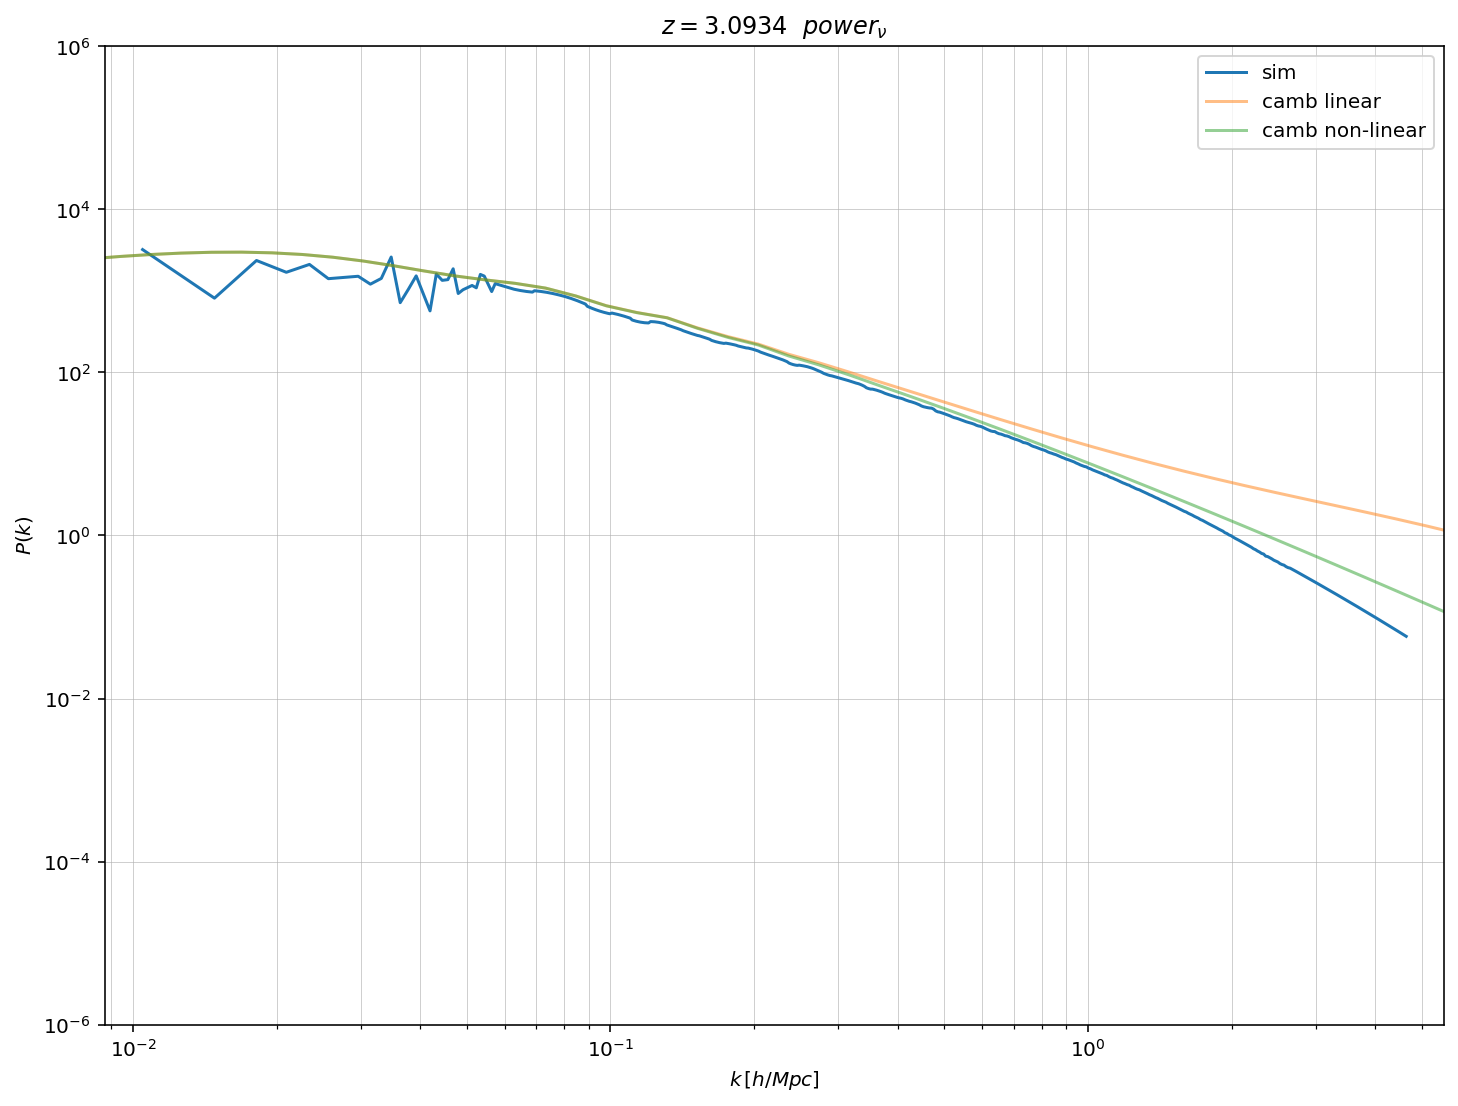

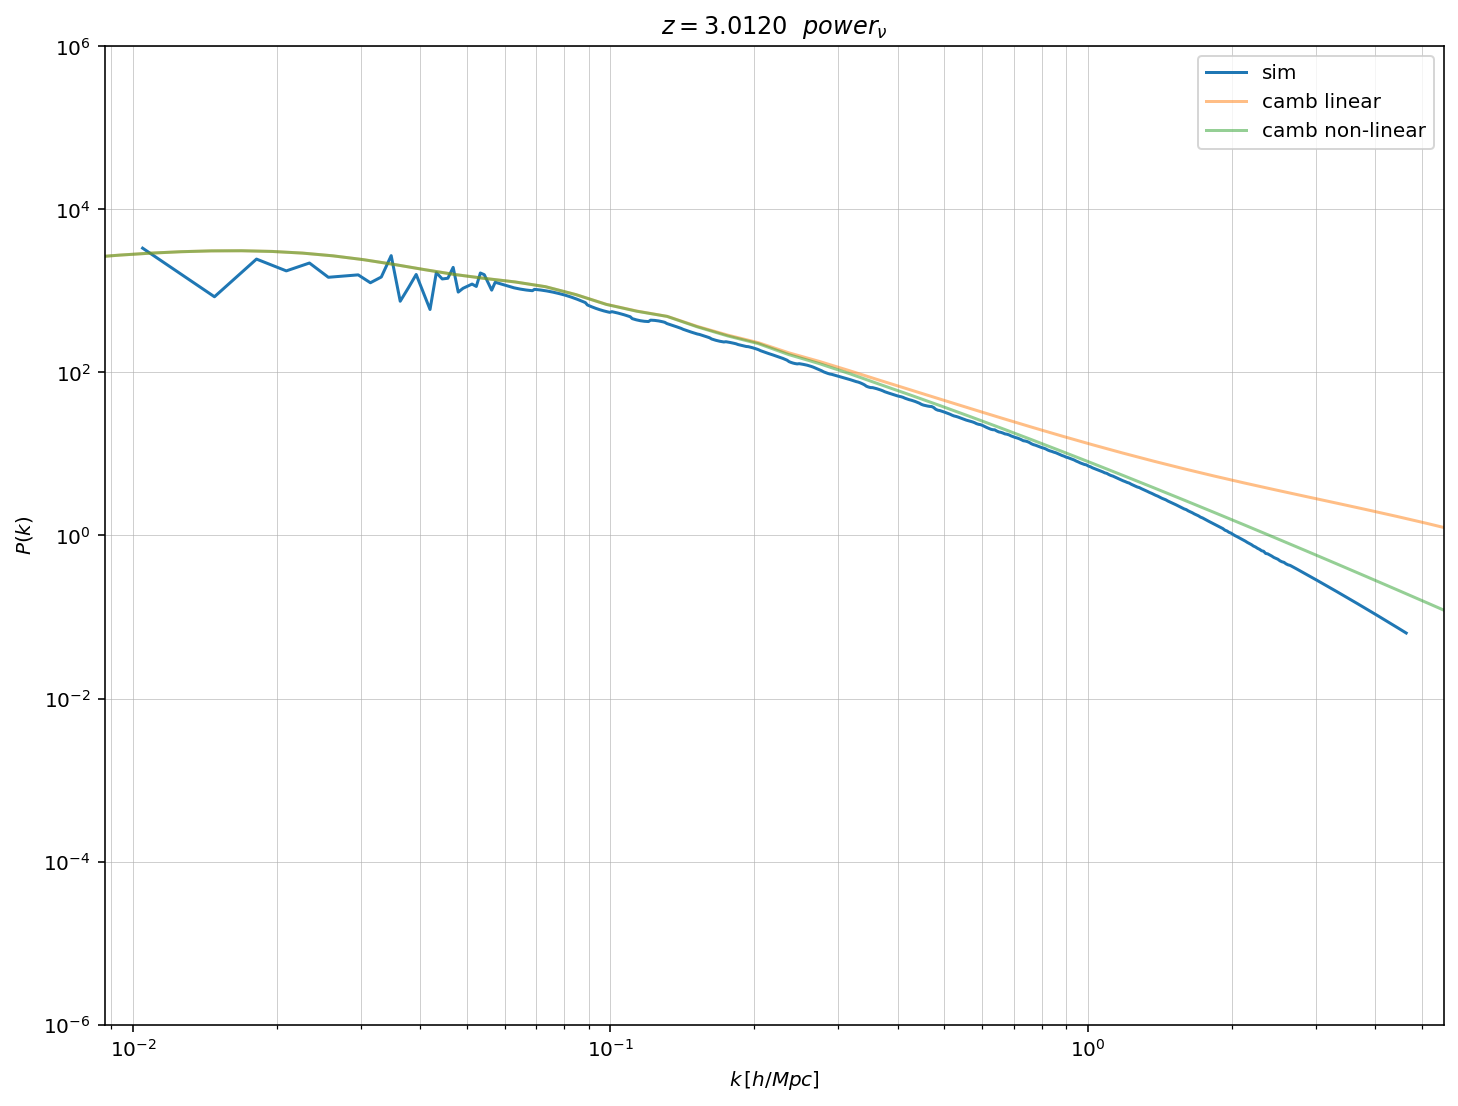

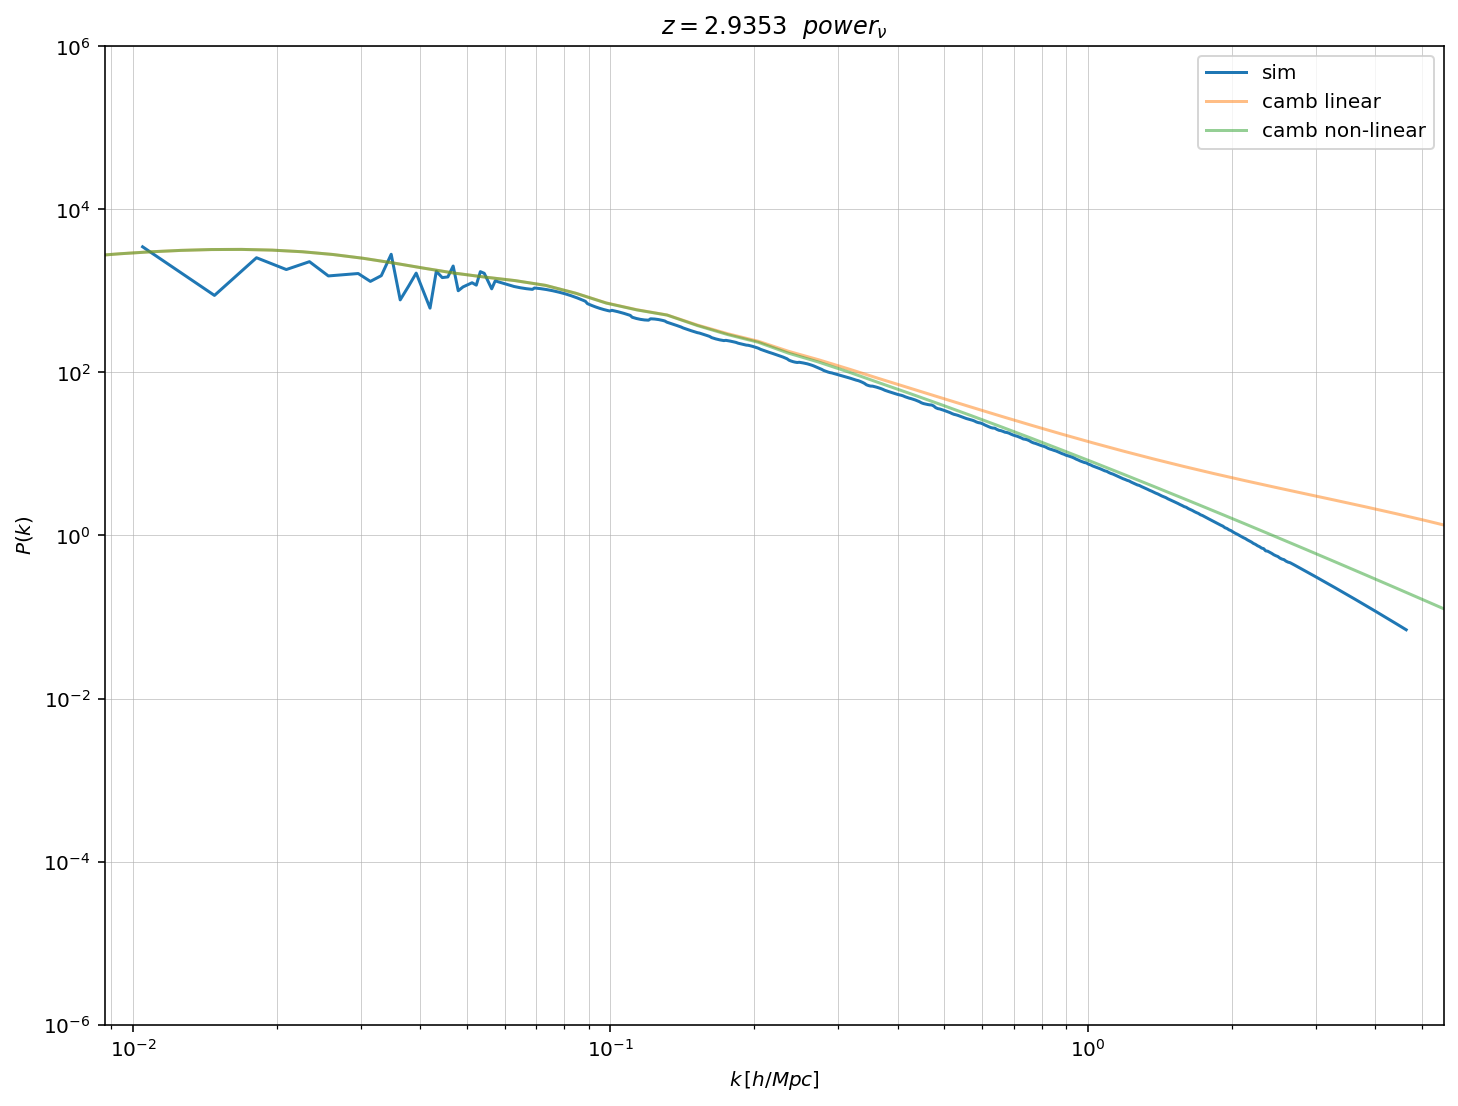

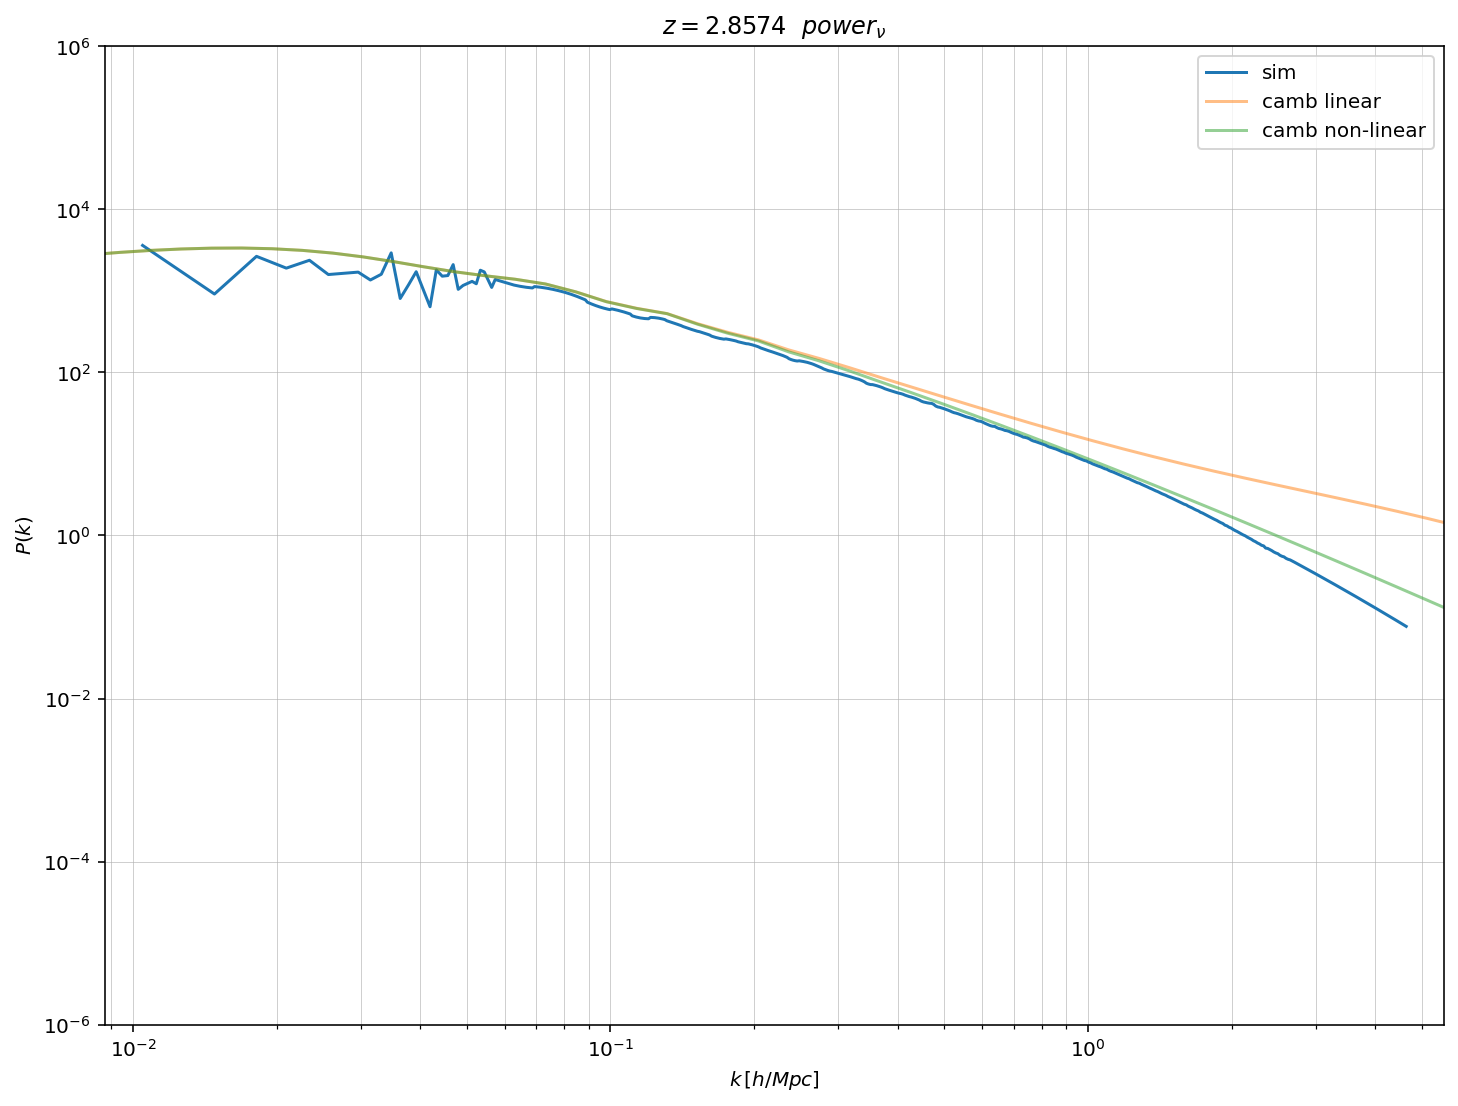

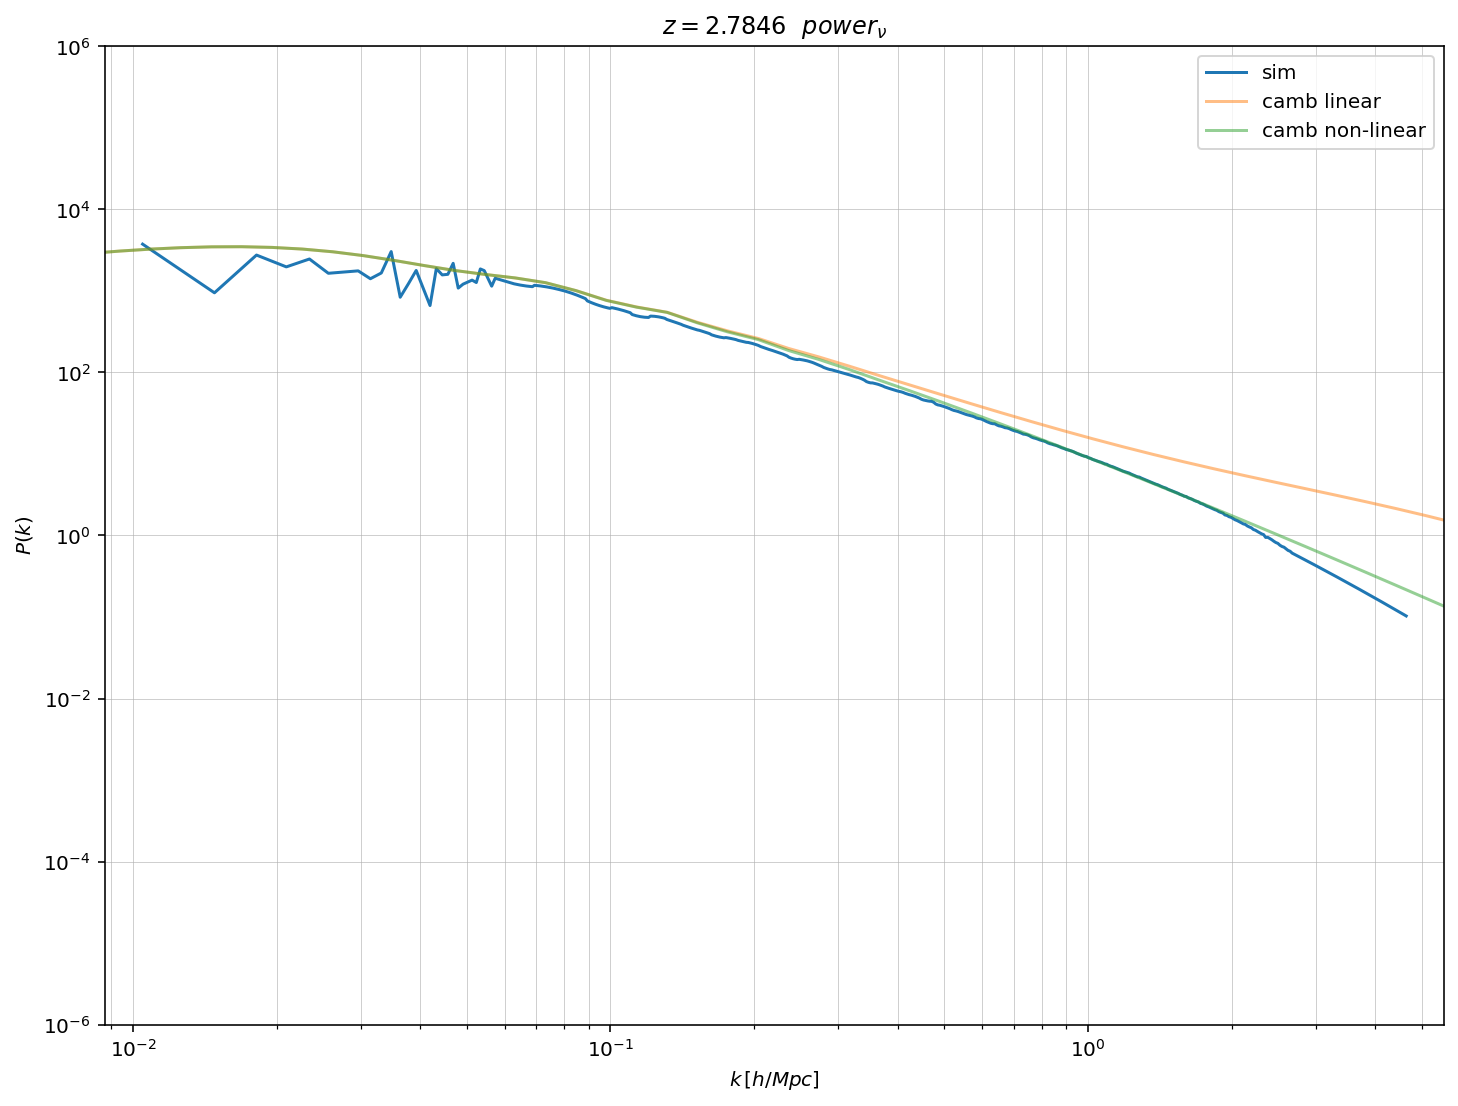

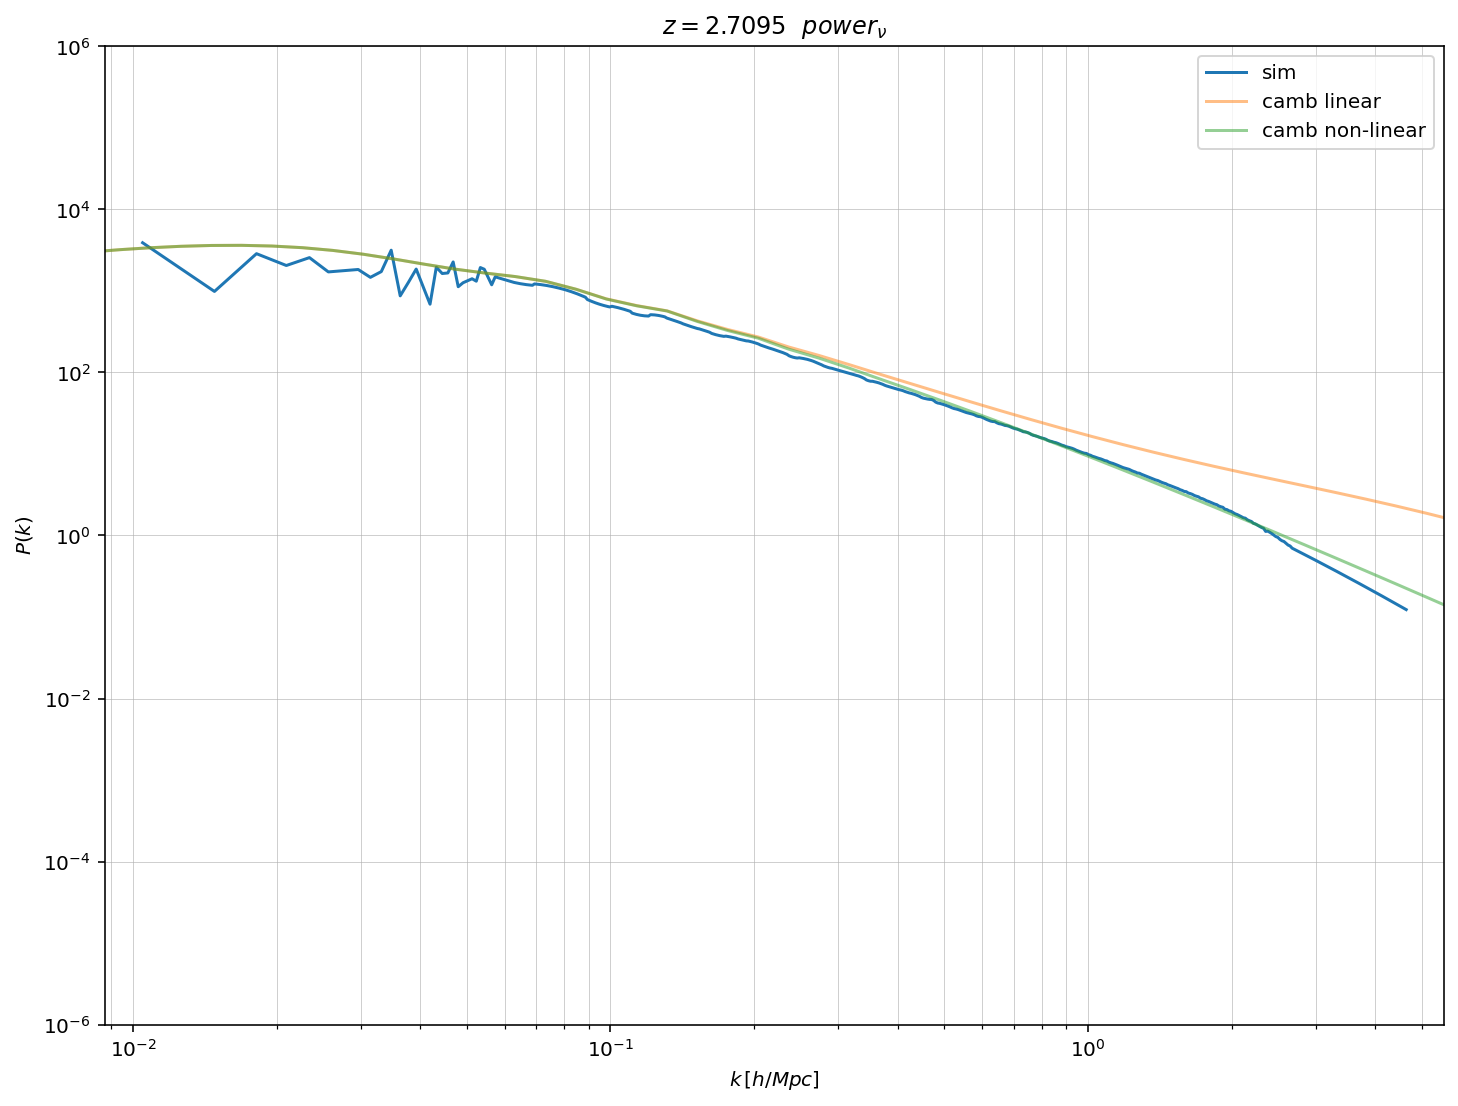

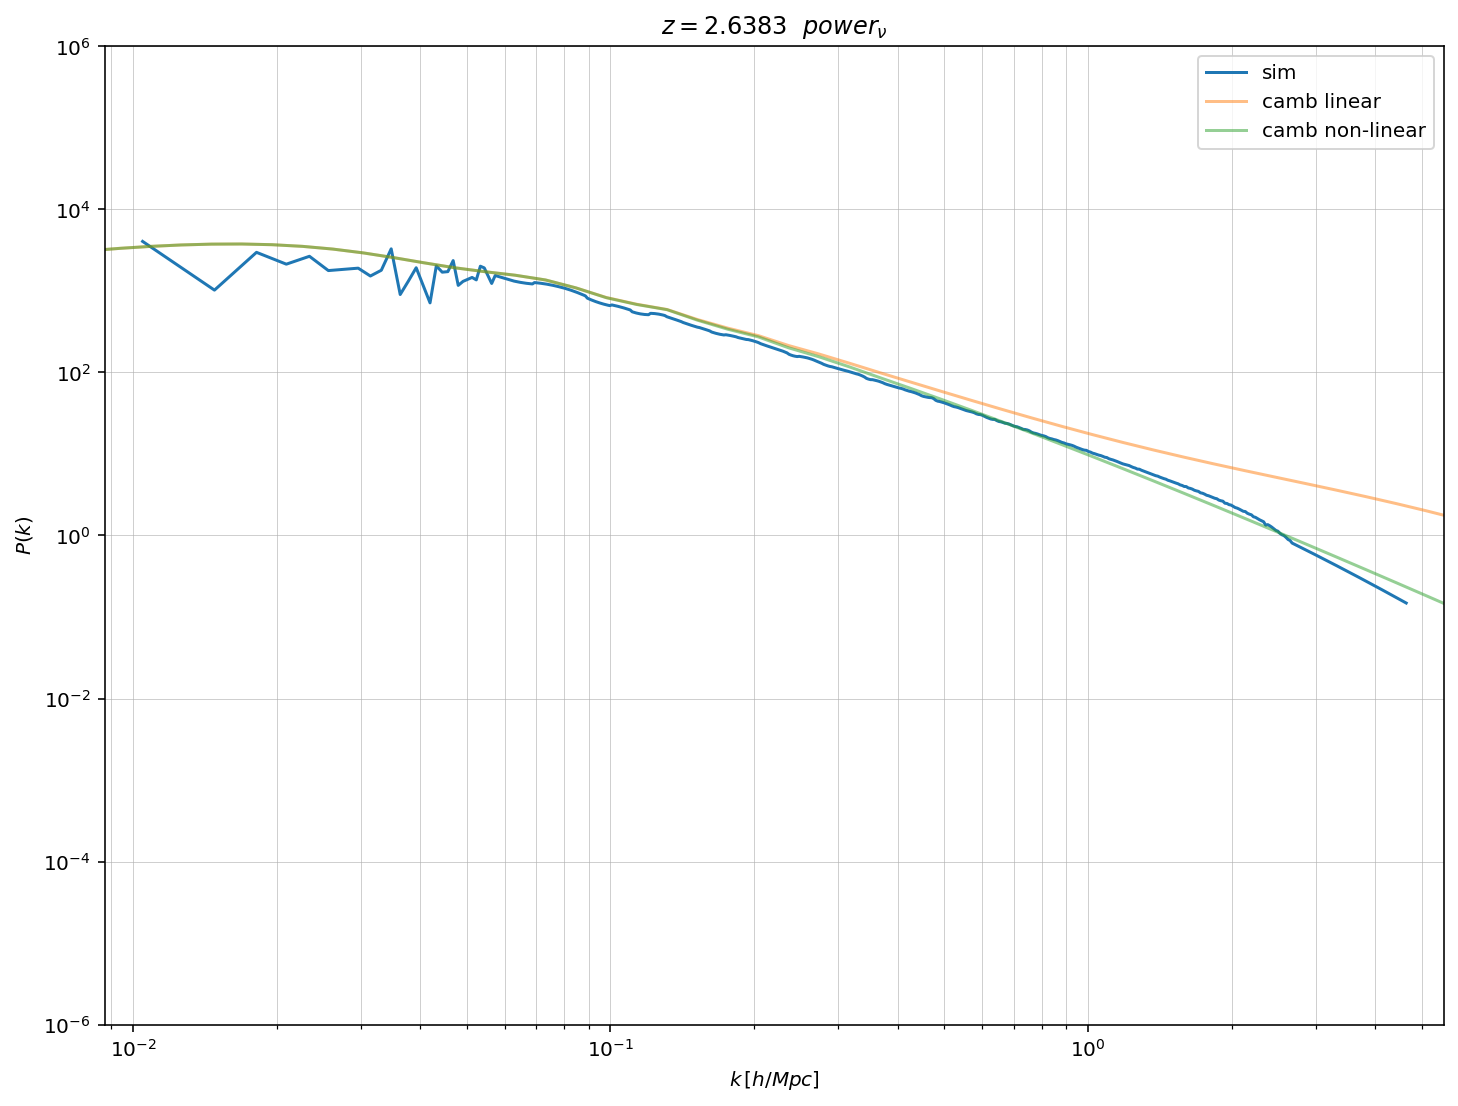

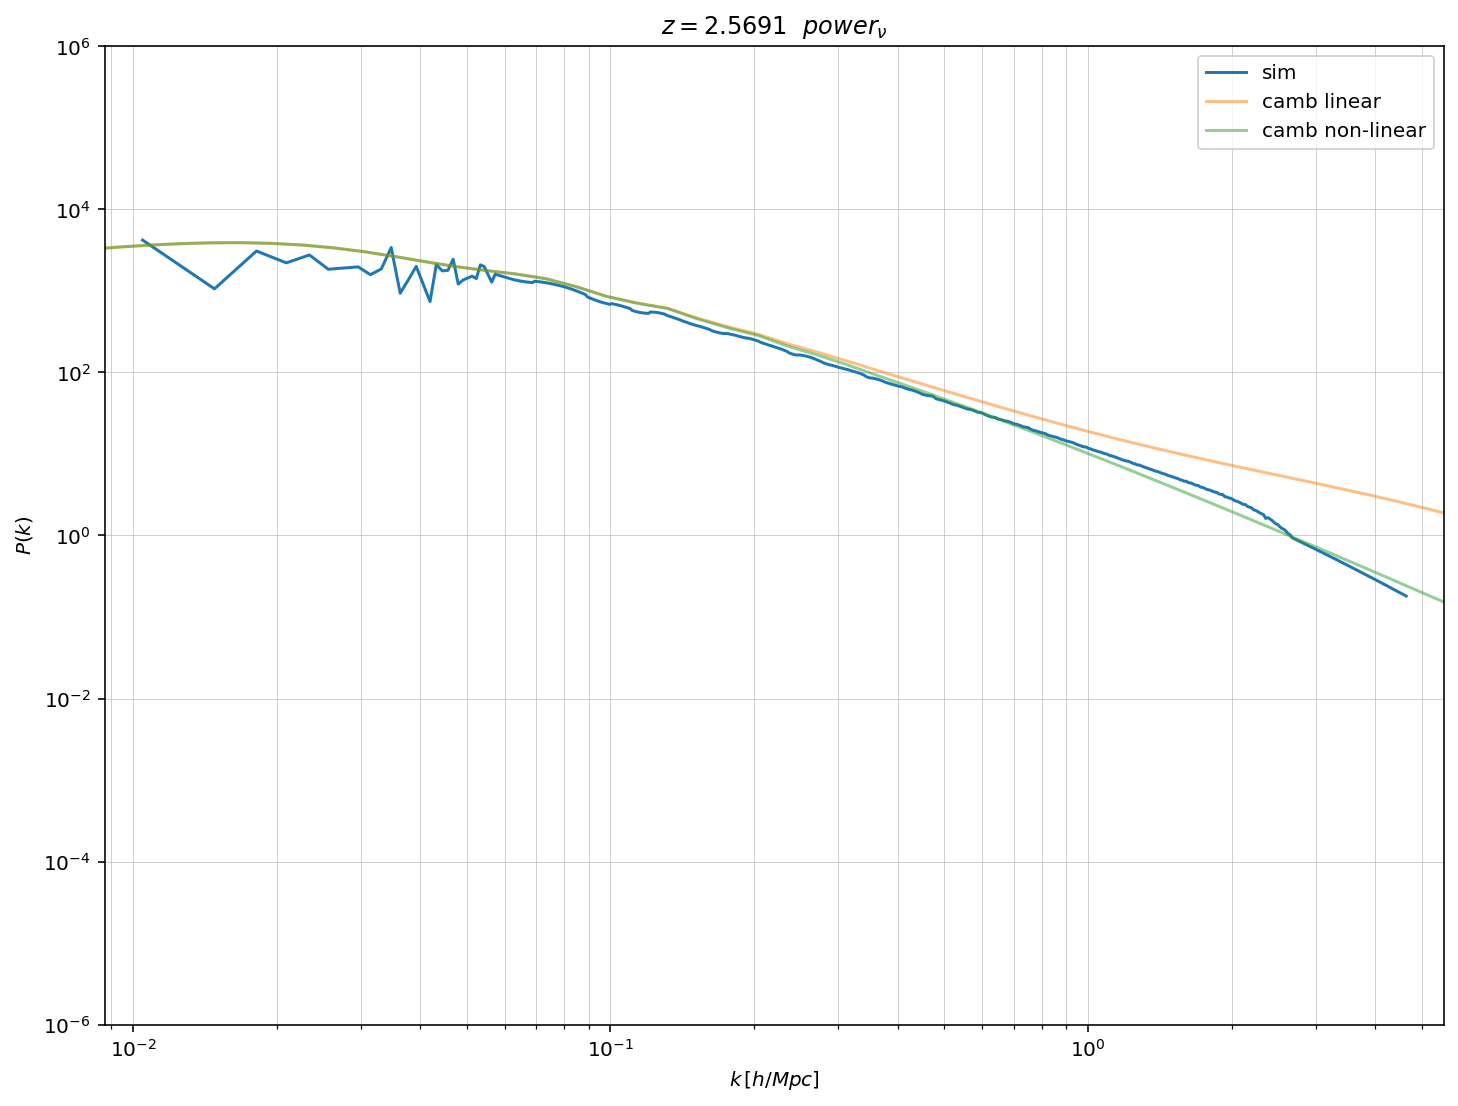

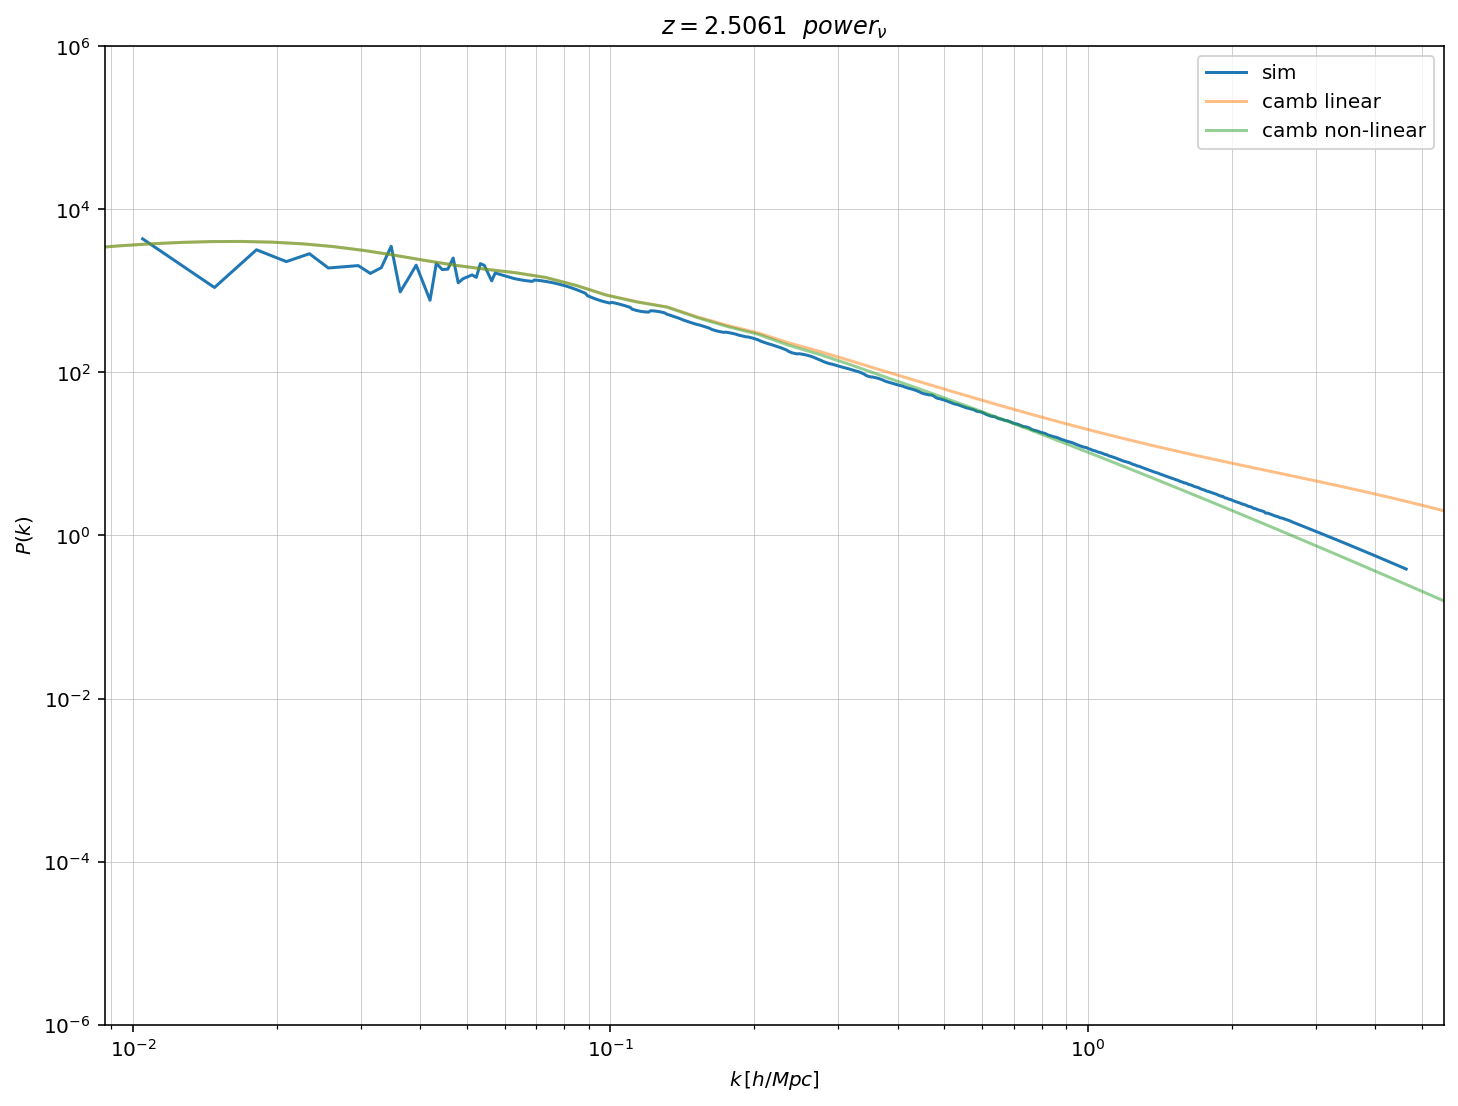

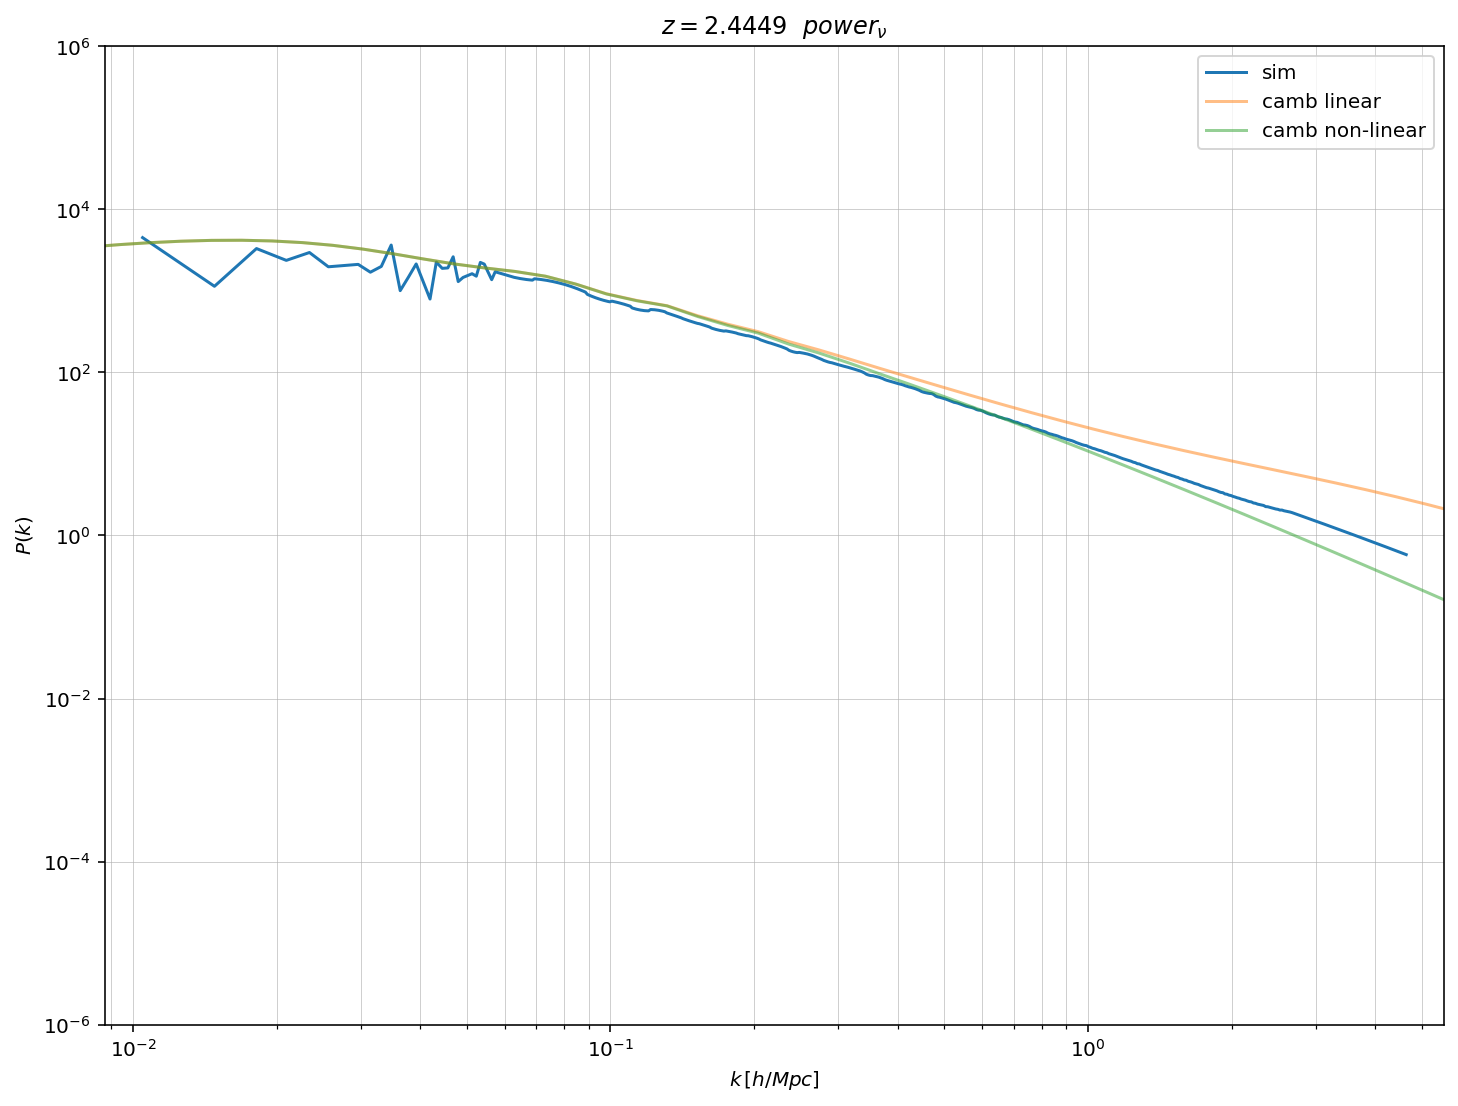

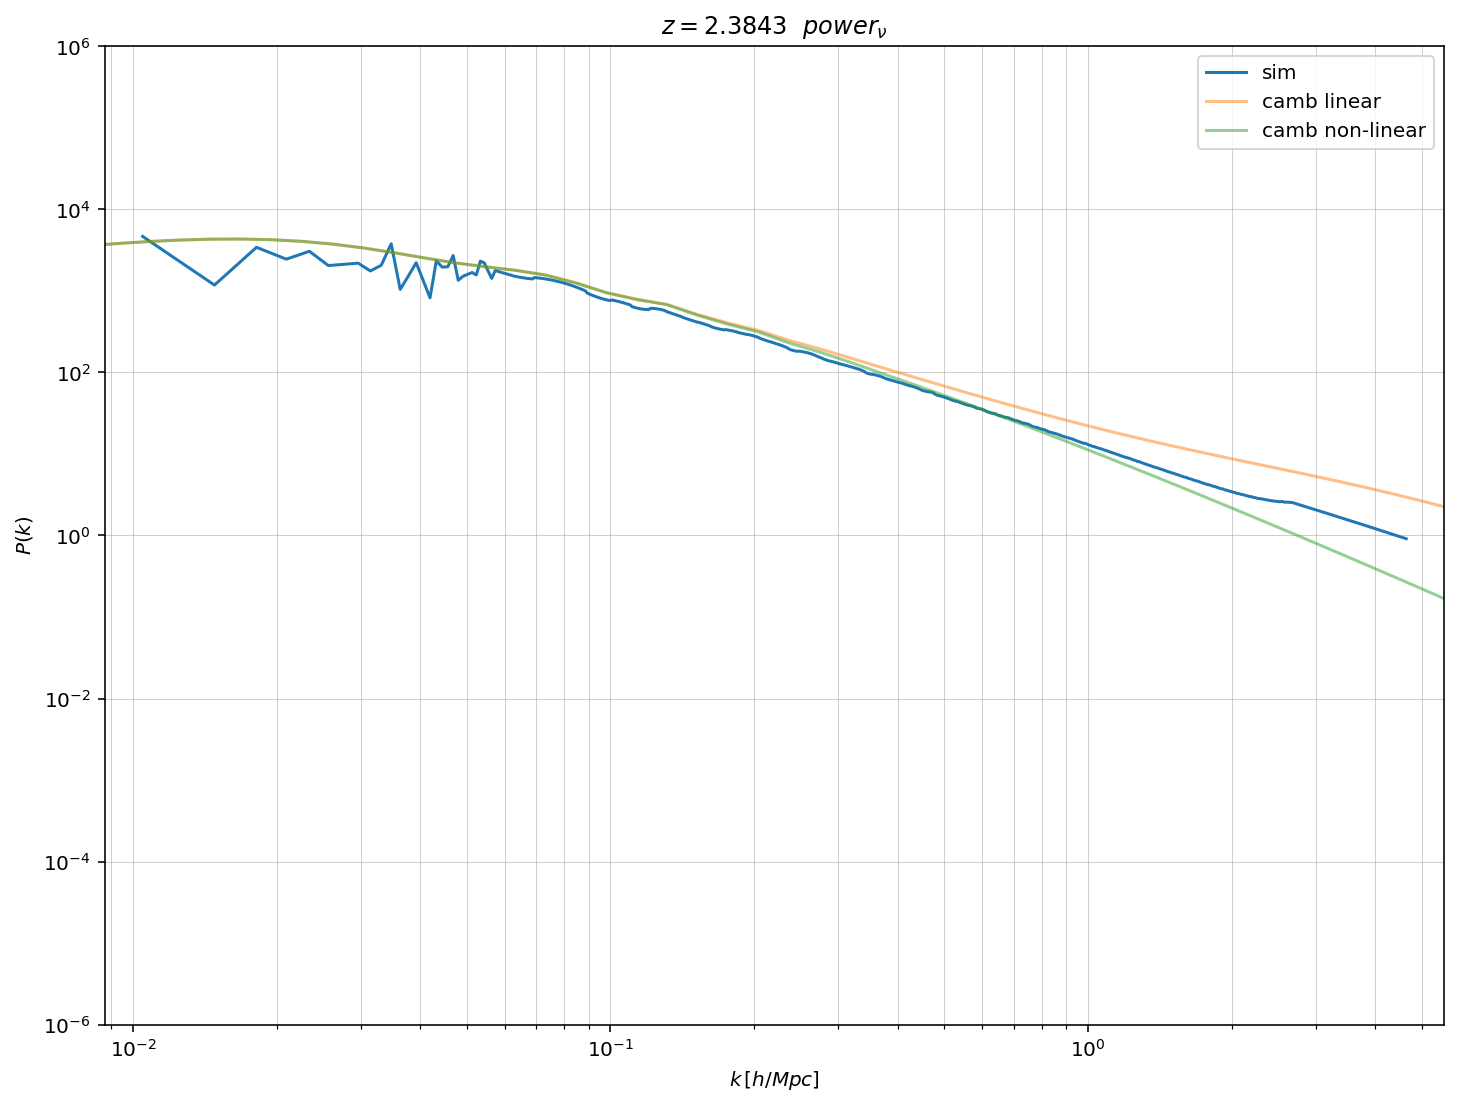

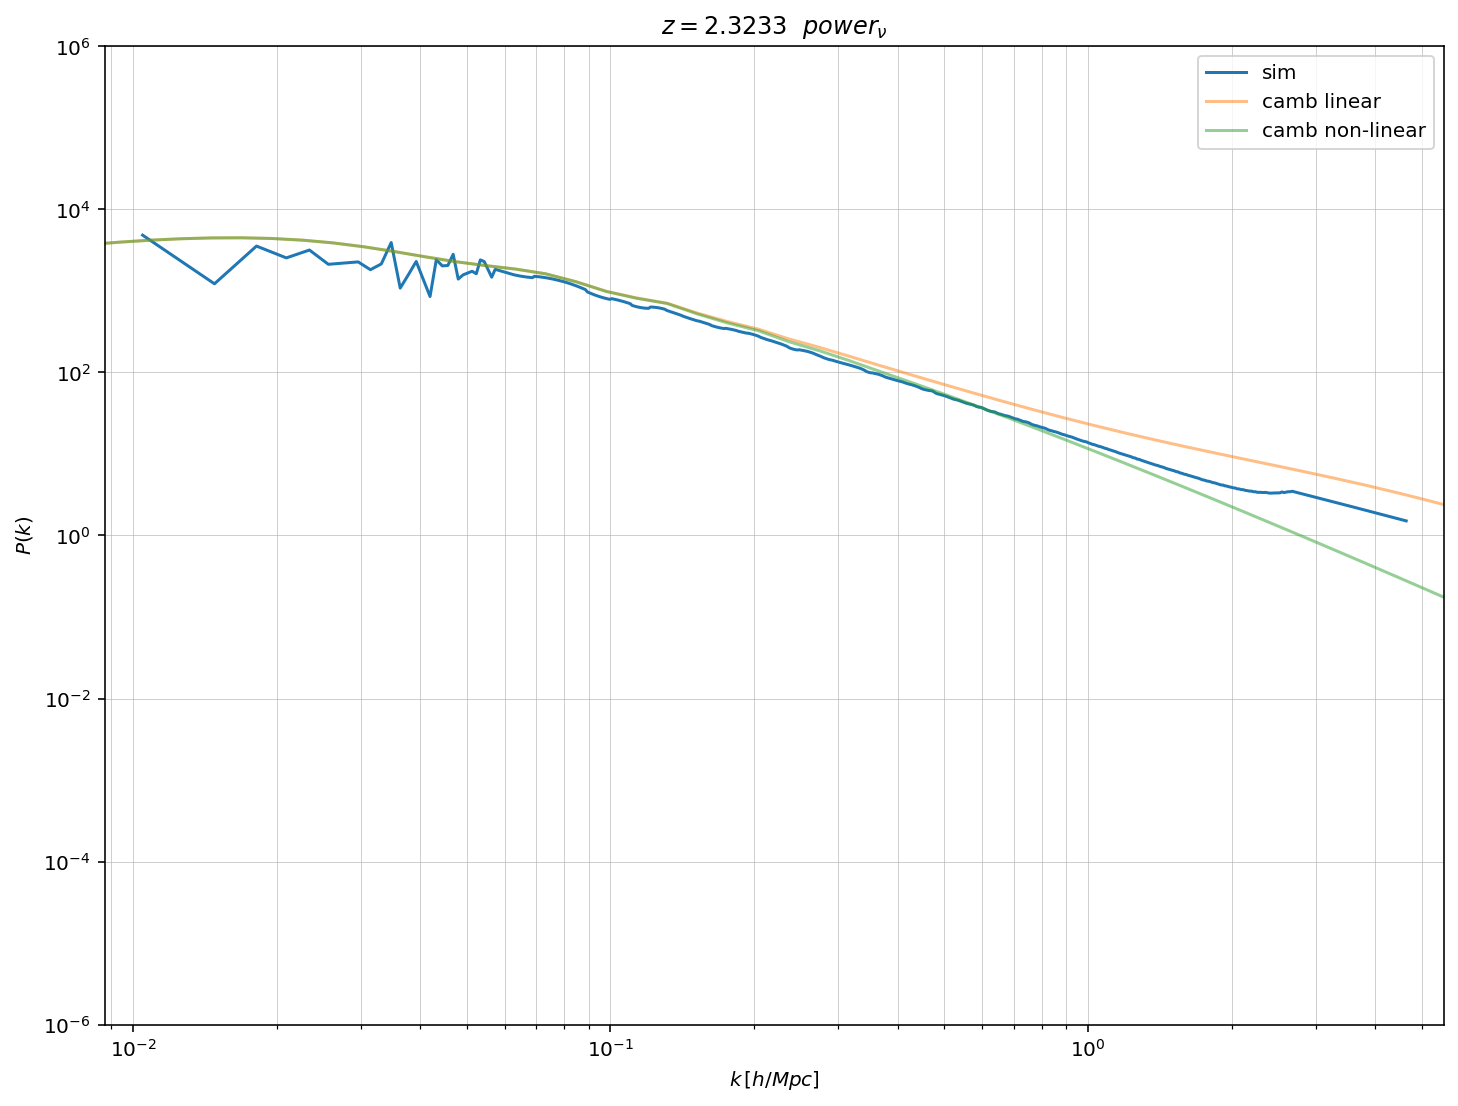

0 12


In [22]:
# 绘制功率谱

# 加载功率谱
def loadpower(filename):
    n_row_xi = 10
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

# 计算红移处的功率谱
def cambpower(z):
    # 定义参数
    h0 = 0.6817
    H0 = h0*100  # 哈勃常数
    omch2 = 0.253209016*h0**2  # 普通物质的物质密度参数
    ombh2 = 0.048072486*h0**2  # 冷暗物质的物质密度参数
    omk = 0.0  # 曲率密度参数
    kmax = 200.0  # 最大k值
    neutrino_hierarchy='degenerate'
    num_massive_neutrinos=3
    nnu=3.044
    standard_neutrino_neff=3.044
    ns=0.972
    As=2.6025e-09

    # 创建CAMB参数对象
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=pars.omch2-pars.omnuh2
    pars.InitPower.set_params(As=As,ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax, nonlinear=True)
    pars.NonLinear = camb.model.NonLinear_none

    # 计算功率谱
    # print(pars)
    results = camb.get_results(pars)
    k, zout,pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')

    pars.NonLinear = camb.model.NonLinear_both

    # 计算功率谱
    results = camb.get_results(pars)
    k, zout,pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints=100,var1=f'delta_{ptype}',var2=f'delta_{ptype}')
    return k,pk[0],pk_lin[0]

path = '/home/cossim/cube_nu/output/2400_512_1_0.1_1'
path = '/home/cossim/cube_nu/output/GP600_512_1_0.1_2'
z_step = 1/np.fromfile(path+'/neutrinos/a_step.txt', dtype='float32')-1 
kh = np.loadtxt(path+'/neutrinos/k_values.txt')
ptype = 'tot'
ftype = 'm'
mnu=0.1
i1 = np.where(z_step<3.1)[0][0]
i2 = np.where(z_step<2.3)[0][0]
ii = 10
print(i1,i2)

counts = 0
for z in z_step[i1:i2][::ii]:
    Redshift = f'{z:.4f}'
    pk = np.fromfile(path+f'/neutrinos/Pk_{ftype}/Pk_{ftype}_{Redshift}.txt', dtype='float32')
    if np.sum(pk) == 0:
        # print('z = %s no power spectrum'%Redshift)   
        counts += 1
        continue
    k,pk_nl,pk_lin = cambpower(z)

    plt.figure(figsize=(12,9))
    plt.loglog(kh,pk,label = 'sim',alpha=1)
    plt.loglog(k,pk_nl,label = 'camb linear',alpha=0.5)
    plt.loglog(k,pk_lin,label = 'camb non-linear',alpha=0.5)
    plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
    plt.xlim([min(kh)/1.2, max(kh)*1.2])
    plt.xlabel('$k\,[h/{ Mpc}]$')
    plt.ylabel('$P(k)$')
    plt.legend(loc='upper right')
    plt.title('$z='+str(Redshift)+'\,\,\,\,power_{\\nu}$')
    plt.ylim(1e-6,1e6)
    # 添加上边和右边的坐标轴
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    plt.show()
    plt.close()
print(counts,len(z_step[i1:i2][::ii]))

In [40]:
pk[0].shape

(100,)

In [44]:
np.fromfile(path+f'/neutrinos/Pk_nu/Pk_{ptype}_{z_step[1]:.4f}.txt', dtype='float32')

array([1.41738303e-04, 1.38225703e-04, 1.36417017e-04, 1.16407049e-04,
       1.01123282e-04, 8.10509955e-05, 5.51925514e-05, 4.35439724e-05,
       3.64047046e-05, 3.42673993e-05, 2.13803469e-05, 1.88979357e-05,
       1.75659734e-05, 9.47177159e-06, 1.15501534e-05, 9.45441661e-06,
       8.73234785e-06, 9.09577739e-06, 6.06847152e-06, 5.79255675e-06,
       5.82269513e-06, 5.48520347e-06, 6.47246770e-06, 6.21742629e-06,
       4.81262896e-06, 5.46003275e-06, 4.96217035e-06, 4.90635193e-06,
       4.84903012e-06, 4.78941865e-06, 4.72599595e-06, 4.65953008e-06,
       4.58716886e-06, 4.51177448e-06, 4.52903396e-06, 4.43270392e-06,
       4.32262550e-06, 4.20448987e-06, 4.07493553e-06, 3.93863002e-06,
       3.79454787e-06, 3.64451671e-06, 3.49176639e-06, 3.33339085e-06,
       3.18987554e-06, 3.03111233e-06, 2.88529463e-06, 2.73639489e-06,
       2.60380625e-06, 2.47177809e-06, 2.35692823e-06, 2.24591463e-06,
       2.15191449e-06, 2.05193078e-06, 1.98194539e-06, 1.91853610e-06,
      

In [ ]:
# 绘制功率谱

# 加载功率谱
def loadpower(filename):
    n_row_xi = 10
    fid = open(filename, 'rb')  # 以二进制模式打开文件

    xi = np.fromfile(fid, dtype='float32')  # 读取数据到一维数组
    fid.close()

    xi = np.reshape(xi, (int(len(xi) / n_row_xi), n_row_xi))  # 重新形状为二维数组
    ksim = xi[:, 1]  # 提取第二列作为 ksim
    print('load :'+filename)

    return ksim, xi

path1 = '../../output/old600_256_1_0.1_1'
path2 = '../../output/NH600_256_1_0.1_1'
Redshift = '20.0000'
z_checkpoint = np.loadtxt('../z_checkpoint.txt')
z = float(Redshift)

if (1):
    kh1 = np.loadtxt(path1+'/neutrinos/k_values.txt')
    # kh2 = np.loadtxt(path2+'/neutrinos/k_values.txt')
    pk1 = np.fromfile(path1+'/neutrinos/Pk_nu/Pk_nu_%s.txt'%Redshift, dtype='float32')
    pk2 = np.fromfile(path2+'/neutrinos/Pk_nu/Pk_nu_%s.txt'%Redshift, dtype='float32')

    plt.figure(figsize=(12,9))
    plt.loglog(kh1,pk1,label = 'old',alpha=0.5)
    plt.loglog(kh1,pk2,label = 'new',alpha=0.5)
    plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
    plt.xlim([min(kh1)/1.2, max(kh1)*1.2])
    # plt.ylim([1e-4, 1e3])
    plt.xlabel('$k\,[h/{ Mpc}]$')
    plt.ylabel('$P(k)$')
    plt.legend(loc='upper right')
    plt.title('$z='+str(Redshift)+'\,\,\,\,power_{mater}$')
    # plt.title('$z='+str(z)+'\,\,\,\,power_{mater}$')
    plt.ylim(1e-6,1e6)
    # 添加上边和右边的坐标轴
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    # savename = Path+'/fig/power_11'+str(Redshift)+'.jpg'
    # plt.savefig(savename, format='jpeg')
    plt.show()


    plt.figure(figsize=(12,9))
    plt.loglog(kh1,pk2/pk1-1,label = 'new/old-1',alpha=0.5)
    plt.grid(True, which='both', linewidth=0.3)  # 打开主要和次要网格线，linewidth为0.3
    plt.xlim([min(kh1)/1.2, max(kh1)*1.2])
    plt.yscale('linear')
    plt.ylim([-1, 1])
    plt.xlabel('$k\,[h/{ Mpc}]$')
    plt.ylabel('$P(k)$')
    plt.legend(loc='upper right')
    plt.title('$z='+str(Redshift)+'\,\,\,\,power_{mater}$')
    # 添加上边和右边的坐标轴
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    # savename = Path+'/fig/power_11'+str(Redshift)+'.jpg'
    # plt.savefig(savename, format='jpeg')
    plt.show()

In [ ]:
# test eta data
z_max = 200

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
import scipy.constants as C
import scipy.integrate as integrate
import time

# all in SI units
zeta3=1.20206
T_nu_0=1.9454
N_eff=3.044
N_eff_fake=1
m=0.1/5.6095888606e35 # 0.06eV to Kg
rho_c=7.65985e-10 # h=0.6736 here in rho_c is the energy density!
h=0.7
omu=3*zeta3/(2*np.pi**2)*(C.k*T_nu_0)**3/(C.hbar**3*C.c*rho_c)*N_eff_fake**(3/4)*m
# omuh2=omu*h**2
omuh2 = m*5.6095888606e35/93.14

# all the same, planck2018 values
ombh2=0.0463*h**2
omch2=0.2327*h**2-omuh2
omrh2=5.046734693877551e-05*h**2
omwh2=h**2-ombh2-omch2-omrh2-omuh2

# planck2018 values
pars = camb.CAMBparams()
#This function sets up with one massive neutrino and helium set using BBN consistency
pars.set_cosmology(H0=h*100, ombh2=ombh2, omch2=omch2, mnu=m*5.6095888606e35, omk=0, tau=0.06, nnu=3.044)
pars.InitPower.set_params(As=2.099e-9, ns=0.965, r=0)
results = camb.get_results(pars)
print("Omega_nu_h2 is calculated as "+f"{omu*h**2}")
print("Omega_nu_h2 is estimated as " +f"{m*5.6095888606e35/94}")
print("Omega_nu_h2 is camb as " +f"{pars.omnuh2}")
print(m*5.6095888606e35)
print(omwh2,omrh2,omch2,ombh2,omuh2,h)

def get_f_nr(a):
    def core1(u):
        return (u**2)/((1+np.exp(u))*np.sqrt(u**2+y**2))

    def F(y):
        def core0(u):
            return (u**2*np.sqrt(u**2+y**2))/(1+np.exp(u))
        
        f0 = 0

        for i in range(n):
            k1 = h*core0(i)
            k2 = h*core0(i+1/2)
            k3 = h*core0(i+1)
            f0 = f0 + (k1 + 4*k2 +k3)/6
        return f0

    sigma_nu = (4/11)**(1/3)
    # N_eff = 3.046
    k_b = 8.617342e-5
    T_gama = 2.7255
    Mass_nu = m*5.6095888606e35
    y = Mass_nu*a/(sigma_nu*N_eff*k_b*T_gama)

    h = 1
    n = 300
    f1 = 0

    for i in range(n):
        k1 = h*core1(i)
        k2 = h*core1(i+1/2)
        k3 = h*core1(i+1)
        f1 = f1 + (k1 + 4*k2 +k3)/6

    f_nr = y**2*f1/F(y)
    return f_nr

def f_nu(a):
    def core(y):
        cc=2/(3*zeta3)/a**3
        return cc*y**2/(np.exp(y)+1)*np.sqrt(1+(C.k*T_nu_0/C.c**2*N_eff_fake**(1/4)/(m*a)*y)**2)
    return integrate.quad(core, 0, 700)[0]

def Ha(a):
    # print(omwh2,omrh2,omch2,ombh2,omuh2,f_nu(a),h)
    return 100*np.sqrt(omwh2+omch2/a**3+ombh2/a**3+omrh2/a**4+omuh2*f_nu(a)+(N_eff-1)*5.61614e-6/a**4)

def Hz(z):
    return Ha(1/(1+z))

def get_line(y1,y2,x1,x2,x):
    a = (y2-y1)/(x2-x1)
    b = y1 - a*x1
    y = a*x+b
    return y

def interp_line(arr,ni,a=None):
    if a is None:
        a = range((len(arr)-1)*ni+1)
    # print('len_in=',len(arr)-1)
    arr_new =[]
    for i in range(0,len(arr)-1):
        arr_new.append(arr[i])
        for j in range(1,ni):
            arr_new.append(get_line(arr[i],arr[i+1],a[i*ni],a[i*ni+ni],a[i*ni+j] ))
    arr_new.append(arr[-1])
    arr_new = np.array(arr_new)
    # print('len_out',len(arr_new))
    return arr_new

def get_a(n,typ): #get array a
    z = [0]*n
    a = [0]*n
    z[0] = z_max
    if typ == 'line':
        a = np.linspace(1/(1+z[0]),1,n+1)
    elif typ =='log':
        log_a = [np.log(1/(1+z[0])),0]
        log_a = interp_line(log_a,n)
        a = np.exp(log_a)
    else:
        print('no such type')
        sys.exit()
    return a

a_arr = get_a(200,'line')
z_arr=1/a_arr-1 # z in [10^a,10^b]
eta_new=np.zeros(len(z_arr))
H_z=np.zeros(len(z_arr))
f_nu_z=np.zeros(len(z_arr))

T1 = time.time()
for i in range(len(z_arr)):
    eta_new[i]=results.conformal_time(z_arr[i])
    H_z[i] = Hz(z_arr[i])
    f_nu_z[i] = f_nu(1/(z_arr[i]+1))

np.savetxt('eta200.txt',eta_new,'%10.10f')
np.savetxt('Hz200.txt',H_z,'%10.10f')
np.savetxt('fnu200.txt',f_nu_z,'%10.10f')
np.savetxt('z200.txt',z_arr,'%2.4f')

In [ ]:

pk_path0 = '../../output_reps/1200_128_-1/'
pk_path1 = '../../output_reps/1200_128_-1old/'
z_values0 = np.loadtxt(pk_path0+'/neutrinos/z_powerpoint.txt')
z_values1 = np.loadtxt(pk_path1+'/neutrinos/z_powerpoint.txt')
kh_nl = np.loadtxt(pk_path0+'/neutrinos/k_values.txt')
kh_nl1 = np.loadtxt(pk_path1+'/neutrinos/k_values.txt')

mnu = 0.1
n = 50
ni= 5
z_max = 200
show=1
# for i in range(1,int(z_values.shape[0])):
#       z = z_values[i]
for z in z_values0:
      Pk_cdm_camb0 = np.loadtxt(pk_path0+'/neutrinos/Pk_cb_%.4f.txt'%z)
      Pk_cdm_camb1 = np.loadtxt(pk_path1+'/neutrinos/Pk_cb_%.4f.txt'%z)
      Pk = [
            [Pk_cdm_camb0]   +['Pk_{camb,new}','.5',8,'-',.7]
            ,[Pk_cdm_camb1]   +['Pk_{cube,old}','b',4,'-.',.7]
            ]

      plot_Pk2k(n,ni,kh_nl,'Pk\_cdm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)


      Pk_nu_camb0 = np.loadtxt(pk_path0+'/neutrinos/Pk_nu_%.4f.txt'%z)
      Pk_nu_camb1 = np.loadtxt(pk_path1+'/neutrinos/Pk_nu_%.4f.txt'%z)
      Pk = [
            [Pk_nu_camb0]   +['Pk_{camb,new}','.5',8,'-',.7]
            ,[Pk_nu_camb1]   +['Pk_{cube,old}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,'Pk\_nu','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)


      TF_camb0 = np.loadtxt(pk_path0+'/neutrinos/Tf_nu_%.4f.txt'%z)
      TF_camb1 = np.loadtxt(pk_path1+'/neutrinos/Tf_nu_%.4f.txt'%z)
      Pk = [
            [TF_camb0]   +['Tf_{camb,new}','.5',8,'-',.7]
            ,[TF_camb1]   +['Tf_{cube,old}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,'tf\_cdm2dm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)
      print(z)

In [ ]:
# Pk_nu test
from scipy.interpolate import RectBivariateSpline
size = 2
pk_path = '../../output/600_256_2_0.05_1'
z_steps = 1/(np.fromfile(pk_path+'/neutrinos/a_step.txt', dtype='float32'))-1
z_values = np.loadtxt(pk_path+'/neutrinos/z_powerpoint.txt')
kh_nl = np.loadtxt(pk_path+'/neutrinos/k_values.txt')

# f_nr_step = np.fromfile(pk_path+'/neutrinos/f_nr.txt', dtype='float32')
Pk_cdm_cambs=[]
Pk_nu_cambs=[]
TF_cambs=[]
i = 0
for z in z_values:
      Pk_cdm_cambs.append(np.loadtxt(pk_path+'/neutrinos/Pk_cb_%.4f.txt'%z))
      Pk_nu_cambs.append(np.loadtxt(pk_path+'/neutrinos/Pk_nu_%.4f.txt'%z))
      TF_cambs.append(np.loadtxt(pk_path+'/neutrinos/Tf_nu_%.4f.txt'%z))

# 创建插值函数
Pk_cdm_a = RectBivariateSpline(1/(z_values+1), kh_nl, Pk_cdm_cambs)
Pk_nu_a = RectBivariateSpline(1/(z_values+1), kh_nl, Pk_nu_cambs)
Tf_a = RectBivariateSpline(1/(z_values+1), kh_nl, TF_cambs)

n = 50
ni= 5
z_max = 200
show=1
mnu = 0.05
f_nu = 1-0.996073247864842
# for i in range(1,int(z_values.shape[0])):
i = -1
if(1):
      z = z_steps[i]
      z = 0.0002
      print(z,1/(z+1))
      Pk_cdm_camb = Pk_cdm_a(1/(z+1), kh_nl, grid=False)
      Pk_cdm_iqr = np.fromfile(pk_path+'/neutrinos/Pk_m/Pk_m_%.4f.txt'%z, dtype='float32')
      Pk = [
            [Pk_cdm_camb]   +['Pk_{camb}','.5',8,'-',.7]
            ,[Pk_cdm_iqr]   +['Pk_{cube,fort}','b',4,'-.',.7]
            ]

      plot_Pk2k(n,ni,kh_nl,r'Pk\_cdm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)


      Pk_nu_camb = Pk_nu_a(1/(z+1), kh_nl, grid=False)
      Pk_nu_iqr = np.fromfile(pk_path+'/neutrinos/Pk_nu/Pk_nu_%.4f.txt'%z, dtype='float32')
      Pk = [
            [Pk_nu_camb]   +['Pk_{camb}','.5',8,'-',.7]
            ,[Pk_nu_iqr]   +['Pk_{cube,fort}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,r'Pk\_nu','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)

      # TF_camb = Tf_z(z, kh_nl, grid=False)
      TF_iqr = np.fromfile(pk_path+'/neutrinos/tf/Tf_nu_%.4f.txt'%z, dtype='float32')

      # Pk = [
      #       [TF_camb]   +['Tf_{camb}','.5',8,'-',.7]
      #       ,[TF_iqr]   +['Tf_{cube,fort}','b',4,'-.',.7]
      #       ]
      # plot_Pk2k(n,ni,kh_nl,'tf\_cdm2dm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)

      TF_camb = (f_nu*get_f_nr(z)*np.sqrt(Pk_nu_camb)+(1-f_nu)*np.sqrt(Pk_cdm_camb))/np.sqrt(Pk_cdm_camb)
      # TF_iqr =  (f_nu*get_f_nr(z)*np.sqrt(Pk_nu_iqr)+(1-f_nu)*np.sqrt(Pk_cdm_iqr))/np.sqrt(Pk_cdm_iqr)

      Pk = [
            [TF_camb]   +['Tf_{camb}','.5',8,'-',.7]
            ,[TF_iqr]   +['Tf_{cube,py}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,r'tf\_cdm2dm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)

In [ ]:
# Pk_nu test
size = 1
path = '../../output_reps/1200_128_-1/'
z_values = np.loadtxt(pk_path+'/neutrinos/z_values.txt')
kh_nl = np.loadtxt(pk_path+'/neutrinos/k_values.txt')
# f_nr_step = np.fromfile(pk_path+'/neutrinos/f_nr.txt', dtype='float32')

n = 50
ni= 5
z_max = 200
show=0
for i in range(1,int(z_values.shape[0])):
# i = 10
# if(1):
      z = z_values[i]
      Pk_cdm_camb = np.loadtxt(pk_path+'/neutrinos/Pk_cb_%.4f.txt'%z)
      Pk_cdm_iqr = np.fromfile(pk_path+'/neutrinos/Pk/Pk_cb_%.4f.txt'%z, dtype='float32')
      Pk = [
            [Pk_cdm_camb]   +['Pk_{camb}','.5',8,'-',.7]
            ,[Pk_cdm_iqr]   +['Pk_{cube,fort}','b',4,'-.',.7]
            ]

      plot_Pk2k(n,ni,kh_nl,'Pk\_cdm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)


      Pk_nu_camb = np.loadtxt(pk_path+'/neutrinos/Pk_nu_%.4f.txt'%z)
      Pk_nu_iqr = np.fromfile(pk_path+'/neutrinos/Pk/Pk_nu_%.4f.txt'%z, dtype='float32')
      Pk = [
            [Pk_nu_camb]   +['Pk_{camb}','.5',8,'-',.7]
            ,[Pk_nu_iqr]   +['Pk_{cube,fort}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,'Pk\_nu','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)


      TF_camb = np.loadtxt(pk_path+'/neutrinos/Tf_nu_%.4f.txt'%z)
      TF_iqr = np.fromfile(pk_path+'/neutrinos/tf/Tf_nu_%.4f.txt'%z, dtype='float32')

      Pk = [
            [TF_camb]   +['Tf_{camb}','.5',8,'-',.7]
            ,[TF_iqr]   +['Tf_{cube,fort}','b',4,'-.',.7]
            ]
      plot_Pk2k(n,ni,kh_nl,'tf\_cdm2dm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False,show=show)
      print(z)

In [ ]:
# init
#set cosmology parm
H0=match_para('h0')*100
ombh2=match_para('omega_bar')*(H0/100)**2
omch2=match_para('omega_cdm')*(H0/100)**2
omk=0.0
neutrino_hierarchy='degenerate'
num_massive_neutrinos=3
mnu=match_para('Mass_nu')
nnu=3.044
standard_neutrino_neff=match_para('N_eff')
ns=match_para('n_s')
As=match_para('A_s')
z_max = 200

pi=np.pi
ratio_cs=int(match_para('ratio_cs'))
ratio_sf=np.array([1,2,4,6,8,12,16])
ng = int(match_para('ng'))
box = match_para('box')
nns = int(match_para('nns'))
nnt = int(match_para('nnt'))
nn = int(match_para('nn'))
ngp = int(ng/nnt)
ngb = int(match_para('ngb'))
ngt=int(ngp+2*ngb )
nfp=int(ngp/nns)*ratio_sf
nfb=ratio_sf*ratio_cs
nft=nfp+2*nfb
cic_iapm = int(match_para('cic_iapm'))-1
tile = box/nn/nnt*ngt/ngp
nw = int(ng/ratio_cs)
nw_global=int(nw*nn)
nyquist=int(nw_global/2)
subtile = box/nn/nnt/nns*(nft[5]/nfp[5])
ncbin = int(nyquist*np.sqrt(3.))
nnbin= int(np.max([nft[5],ngt])/2*np.sqrt(3.))
npbin  = int(ncbin+nnbin)
kmin = 2*pi/box
kmax = 2*pi/(box/nn/nnt/nns/nfp[5]*2/np.sqrt(3))
print(npbin,kmin,kmax)
n=50
ni=50

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
pars.omch2=omch2-pars.omnuh2
f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
pars.InitPower.set_params(ns=ns)
pars.set_matter_power(redshifts=[0,z_max],kmax=kmax)
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)
kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
kh_nl, z_nl,Pk_matter_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_tot',var2='delta_tot')
kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
kh_nl, z_nl,Pk_b_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_baryon',var2='delta_baryon')
print('f_nu=%.10f'%f_nu)


In [ ]:
# cic

import math

size = 2
mnu = 0.1


pi=np.pi
box = 400
ng = 128
nn = 1
npbin = math.ceil(ng*2*nn/2*(3**0.5))
kmin = 2*pi/box
kmax = 2*pi*npbin/box

print(npbin,kmin,kmax)
#set cosmology parm
H0=70.0
ombh2=0.0463*(H0/100)**2
omch2=0.2327*(H0/100)**2
omk=0.0
print(ombh2,omch2)
neutrino_hierarchy='degenerate'
num_massive_neutrinos=3
mnu=0.1
nnu=3.044
standard_neutrino_neff=3.044
ns=0.972
z_max = 200

n=50
ni=50
n_all=n*ni
n_PK = 150 # max num of Pk(z) at once

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
pars.omch2=omch2-pars.omnuh2
pars.InitPower.set_params(ns=ns)
pars.set_matter_power(redshifts=[0,z_max],kmax=kmax)
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)
kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
kh_nl, z_nl,Pk_mater_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_tot',var2='delta_tot')
kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')



In [ ]:
# Pk_CDM
z = 20

fid = open('../Pk_test/Pk_cdm_%.4f.txt'%z, 'rb')  # 以二进制模式打开文件
Pk_CDM_r = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组

Pk = [[Pk_CDM_r] +['Pk_{fort,cdm}' ,'g',6,'-',0.5],
      [Pk_cdm_nonlin[0]]   +['Pk_{camb,cdm}','r',2,'-',.5]]
plot_Pk2k(0,0,kh_nl,'Pk_{cdm}','m_{nu}=%.2f'%mnu,Pk,[0,1,None,None],show=1)

In [ ]:
# Pk_nu 

Dir = '/image1/'
Path_nu = '../../output1/1200_128_nu_01/neutrinos/'
z_checkpoint = np.loadtxt('../z_checkpoint.txt')
z = z_checkpoint[-1]
# z = 0.0006
mnu = 0.1
size = 1
show = 1
kh_r = np.loadtxt(Path_nu+'k_values.txt')# 读取数据到一维数组

def get_pk_nu(z0):

      pars = camb.CAMBparams()
      pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
      pars.omch2=omch2-pars.omnuh2
      f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
      pars.InitPower.set_params(ns=ns)
      pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
      pars.NonLinear = model.NonLinear_both
      results = camb.get_results(pars)
      results.calc_power_spectra(pars)
      kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
      print('f_nu = ',f_nu)
      print('z0   = ',z0)

      return Pk_nu_nonlin[0],Pk_cdm_nonlin[0],kh_nl


def plot_Pk2k1(stitle, s, Pk,show = 0):
    fig = plt.figure(figsize=(8*size, 6*size))
    gs = GridSpec(1, 1, hspace=0.05)
    
    # format the axes
    fontsize = 10*size
    font = {
            'weight': 'normal',
            'size': fontsize,
            }

    Pmax = 0
    Pmin = 1
    ax1 = fig.add_subplot(gs[0])
    for Pki in Pk:
        ax1.loglog(Pki[0], Pki[1], label=r'$%s(k)$'%Pki[2], color=Pki[3],linewidth=Pki[4], linestyle=Pki[5], alpha=Pki[6])
        Pmax = np.max([np.max(Pki[1]),Pmax])
        Pmin = np.min([np.min(Pki[1]),Pmin])

    ax1.set_xlabel(r'$k\, [h Mpc^{-1}]$', font)
    ax1.set_ylabel(r'$P(k)$', font)
    ax1.set_title(r'${%s}(k)_{Z_{max} = %d}\, \, \,math:%s$'%(stitle,z_max,s)+'\n',fontsize=fontsize)
    #设置坐标轴的粗细
    ax1.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
    ax1.grid(True, which='both', linestyle='dotted', linewidth=0.3)
    ax1.spines['bottom'].set_linewidth(1);#设置底部坐标轴的粗细
    ax1.spines['left'].set_linewidth(1);#设置左边坐标轴的粗细
    ax1.spines['right'].set_linewidth(1);#设置右边坐标轴的粗细
    ax1.spines['top'].set_linewidth(1);#设置上部坐标轴的粗细
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    # 设置y轴的范围
    print('Pk_range:',Pmax,Pmin)
    # if (Pmax >1 or Pmin<0.1):
    #     ax1.set_ylim(Pmin*(1/1.5),Pmax*1.5)
    # else:
    #     ax1.set_ylim(0.96,1)
    #     ax1.set_yscale('linear')
    # # ax1.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2, 1e4])
    # yticks, ytick_labels = plt.yticks()
    # ytick_labels[0].set_text(None)
    # ax1.set_yticklabels(ytick_labels)
    ax1.legend(loc='upper right', ncol=1, fontsize=fontsize)
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    ax1.set_xlim(kmin*(1/1.5), kmax*1.5)

    subtile = ((stitle.replace("\\",'')).replace("{",'')).replace("}",'')
    if show == 1:
        plt.show()
    else:
        os.system('mkdir -p image/%s'%subtile)
        # 关闭图形，但仍然保存图像文件
        plt.close()
        fig.savefig('./image/%s/%.2f_%s.jpg'%(subtile,z,s.replace('\\','')),dpi=300)
  
# for z in z_checkpoint[2:65]:
if (1):
      print('*'*20)
      print(z)
      fid = open(Path_nu+'Pk/Pk_nu_{:.4f}.txt'.format(z), 'rb')  # 以二进制模式打开文件
      Pk_nu_r = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
      Pk_nu_nonlin,Pk_cdm_nonlin,kh_nl = get_pk_nu(z)

      Pk = [
           [kh_r,Pk_nu_r] +['Pk_{fort,nu}' ,'r',2,'-',.5],
            [kh_nl,Pk_nu_nonlin]   +['Pk_{camb,nu}','.5',6,'-',0.5],
            # [(0.90*np.sqrt(Pk_nu_r))**2]   +['0.9*Pk_{fort,nu}','b',2,'-',0.5]
            ]
      plot_Pk2k1('Pk_{nu}','m_{nu}=%.2feV \,\,\, z = %.2f'%(mnu,z),Pk,show=show)

      fid = open(Path_nu+'Pk/Pk_step_{:.4f}.txt'.format(z), 'rb')  # 以二进制模式打开文件
      Pk_CDM_r = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组

      Pk = [
           [kh_r,Pk_CDM_r]   +['Pk_{fort,cdm}','r',2,'-',.5],
            [kh_nl,Pk_cdm_nonlin] +['Pk_{camb,cdm}' ,'.5',6,'-',0.5]
            ]
      plot_Pk2k1('Pk_{cdm}','m_{nu}=%.2feV \,\,\, z = %.2f'%(mnu,z),Pk,show=show)


      fid = open(Path_nu+'tf/Tf_nu_{:.4f}.txt'.format(z), 'rb')  # 以二进制模式打开文件
      TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
      TF_camb = ((1-f_nu)*np.sqrt(Pk_cdm_nonlin)+f_nu*(np.sqrt(Pk_nu_nonlin)))/np.sqrt(Pk_cdm_nonlin)

      
      Pk = [[kh_r,TF_iqr]   +['Tf_{fort,dm}','r',2,'-',.5],
            [kh_nl,TF_camb] +['Tf_{camb,dm}' ,'.5',6,'-',0.5]]
            
      plot_Pk2k1('TF','m_{nu}=%.2feV \,\,\, z = %.2f'%(mnu,z),Pk,show=show)

In [ ]:
# tf_F
import numpy as np
def pk_tf(z0):
      mnu = 0.5


      pi=np.pi
      box = 400
      nf = 64
      nns = 4
      nnt = 4
      nn = 1
      ng=128
      npbin = math.ceil(nf*nns*nnt*nn/2*(3**0.5))
      kmin = 2*pi/box
      kmax = 2*pi*npbin/box

      print(npbin,kmin,kmax)
      #set cosmology parm
      H0=70.0
      ombh2=0.0463*(H0/100)**2
      omch2=0.2327*(H0/100)**2
      omk=0.0
      print(ombh2,omch2)
      neutrino_hierarchy='degenerate'
      num_massive_neutrinos=3
      nnu=3.044
      standard_neutrino_neff=3.044
      ns=0.972
      z_max = 200

      pars = camb.CAMBparams()
      pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
      pars.omch2=omch2-pars.omnuh2
      f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
      pars.InitPower.set_params(ns=ns)
      pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
      pars.NonLinear = model.NonLinear_both
      results = camb.get_results(pars)
      results.calc_power_spectra(pars)
      kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
      # print('f_nu=%.10f'%f_nu)
      TF_camb_sim = ((1-f_nu)*np.sqrt(Pk_cdm_nonlin[0])+f_nu*(np.sqrt(Pk_nu_nonlin[0])))/np.sqrt(Pk_cdm_nonlin[0])

      return TF_camb_sim


z_checkpoint = np.loadtxt('../z_checkpoint.txt')#;n_checkpoint = len(z);a = 1. / (1. + z);num_step = np.zeros(n_checkpoint)
for z in z_checkpoint[56:]:
      print('+'*50+'\n%.3f'%z)
      fid = open('../Pk_test/Tf_nu_interp_%.4f.txt'%z, 'rb')  # 以二进制模式打开文件
      TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组

      TF_camb_sim = pk_tf(z)

      Pk = [
            [TF_camb_sim]   +['Tf_{camb}','.5',8,'-',.7]
            # ,[TF_r]   +['Tf_{cube,py}','g',4,'-',.7]
            ,[TF_iqr]   +['Tf_{cube,fort}','b',4,'-.',.7]
            ]
      # plot_Pk2k(n,ni,kh_nl,'tf_{cdm2dm,camb}','m_{nu}=%.2f ;z= %.4f'%(mnu,z),Pk)

      plot_Pk2k(n,ni,kh_nl,'tf_cdm2dm','m_{nu}=%.2f;z= %.3f'%(mnu,z),Pk,[1,0,None,None],sq=False)#,show=1)

In [ ]:
#tf1
import numpy as np
from matplotlib import pyplot as plt

def load_tf1(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(npen,nc_g,int(nc/2+1)))
    return tf
# nc = 32
# nc_g = 32 *1
# npen = 256
# tf1=load_tf1('/home/cbh/cube_nu_new/tf_test/Tf1%.4f.txt'%z)
# k_tf1=load_tf1('/home/cbh/cube_nu_new/tf_test/k_Tf1.txt')
# fid = open('./Tf_nu_interp_r.txt', 'rb')  # 以二进制模式打开文件
# TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
i =1
plt.figure()
plt.imshow(tf1[1, :, :], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$tf1_{yz%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf1[1, :, :], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$k\_tf1_{yz%d}$'%i)
plt.show()
plt.figure()
plt.imshow(tf1[:, 1, :], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$tf1_{zx%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf1[:, 1, :], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$k\_tf1_{zx%d}$'%i)
plt.show()
plt.figure()
plt.imshow(tf1[:, :, 1], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$tf1_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf1[:, :, 1], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$k\_tf1_{xy%d}$'%i)
plt.show()

In [ ]:
#tf2

n =64
# tf2=load_tf('/home/cbh/cube_nu_new/tf_test/Tf2.txt')
# k_tf2=load_tf('/home/cbh/cube_nu_new/tf_test/k_Tf2.txt')
# fid = open('./Tf_nu_interp_r.txt', 'rb')  # 以二进制模式打开文件
# TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
# # max = np.max(TF_iqr)
# # min = np.min(TF_iqr)


i=2
plt.figure()
plt.imshow(tf2[:, :, i], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.axis('equal')
plt.colorbar()
# plt.clim(min, max)
plt.title('$tf2_{xy%d}$'%i)
plt.show()

# for i in range(int(n/2+1)):
#     plt.figure()
#     plt.imshow(tf2[:, :, i], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
#     plt.axis('equal')
#     plt.colorbar()
#     plt.clim(min, max)
#     plt.title('$tf2_{xy%d}$'%i)
#     plt.savefig('./tf_fig/tf2_xy%d.jpg'%i)

# for i in range(int(n)):
#     plt.figure()
#     plt.imshow(tf2[i, :, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
#     plt.axis('equal')
#     plt.colorbar()
#     plt.clim(min, max)
#     plt.title('$tf2_{yz%d}$'%i)
#     plt.savefig('./tf_fig/tf2_yz%d.jpg'%i)

# for i in range(int(n)):
#     plt.figure()
#     plt.imshow(tf2[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
#     plt.axis('equal')
#     plt.colorbar()
#     plt.clim(min, max)
#     plt.title('$tf2_{zx%d}$'%i)
#     plt.savefig('./tf_fig/tf2_zx%d.jpg'%i)



In [ ]:
#tf3_2
n =32
# tf3_2=load_tf('/home/cbh/cube_nu_new/tf_test/Tf3_2.txt')
# k_tf3_2=load_tf('/home/cbh/cube_nu_new/tf_test/k_Tf3_2.txt')
# fid = open('./Tf_nu_interp_r.txt', 'rb')  # 以二进制模式打开文件
# TF_ iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
# i =1
plt.figure()
plt.imshow(tf3_2[:, :, i], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$tf3\_2_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf3_2[:, :, i], cmap='RdBu')
plt.axis('equal')
plt.colorbar()
plt.title('$k\_tf3\_2_{xy%d}$'%i)
plt.show()

In [ ]:
#tf3_8
n =128
# tf3_8=load_tf('/home/cbh/cube_nu_new/tf_test/Tf3_8.txt')
# k_tf3_8=load_tf('/home/cbh/cube_nu_new/tf_test/k_Tf3_8.txt')
# fid = open('./Tf_nu_interp_r.txt', 'rb')  # 以二进制模式打开文件
# TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
i =1
plt.figure()
plt.imshow(tf3_8[:, i,:], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.axis('equal')
plt.colorbar()
plt.title('$tf3\_8_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf3_8[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.axis('equal')
plt.colorbar()
plt.title('$k_tf3\_8_{xy%d}$'%i)
plt.show()
i =int(n/4)
plt.figure()
plt.imshow(tf3_8[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.axis('equal')
plt.colorbar()
plt.title('$tf3\_8_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf3_8[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.axis('equal')
plt.colorbar()
plt.title('$k_tf3\_8_{xy%d}$'%i)
plt.show()
print('tf3_8')

In [ ]:
# tf_k
z = 17.0070

def load_tf(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(n, n, int(n/2+1)))
    return tf
def load_tf1(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(npen,nc_g,int(nc/2+1)))
    return tf

import numpy as np
def pk_tf(z0):
      global mnu
      mnu = 0.1


      pi=np.pi
      box = 400
      nf = 64
      nns = 4
      nnt = 4
      nn = 2
      ng=128
      npbin = math.ceil(nf*nns*nnt*nn/2*(3**0.5))
      kmin = 2*pi/box
      kmax = 2*pi*npbin/box

      print(npbin,kmin,kmax)
      #set cosmology parm
      H0=70.0
      ombh2=0.0463*(H0/100)**2
      omch2=0.2327*(H0/100)**2
      omk=0.0
      print(ombh2,omch2)
      neutrino_hierarchy='degenerate'
      num_massive_neutrinos=3
      nnu=3.044
      standard_neutrino_neff=3.044
      ns=0.972
      z_max = 200

      pars = camb.CAMBparams()
      pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
      pars.omch2=omch2-pars.omnuh2
      f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
      pars.InitPower.set_params(ns=ns)
      pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
      pars.NonLinear = model.NonLinear_none
      results = camb.get_results(pars)
      kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      pars.NonLinear = model.NonLinear_both
      results.calc_power_spectra(pars)
      kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
      # print('f_nu=%.10f'%f_nu)
      TF_camb_sim = ((1-f_nu)*np.sqrt(Pk_cdm_nonlin[0])+f_nu*(np.sqrt(Pk_nu_nonlin[0])))/np.sqrt(Pk_cdm_nonlin[0])

      return TF_camb_sim


nw = 32
nc = nw
nc_g = nw *1
npen = nw


z_checkpoint = np.loadtxt('../z_checkpoint.txt')#;n_checkpoint = len(z);a = 1. / (1. + z);num_step = np.zeros(n_checkpoint)
for z in z_checkpoint[-2:-1]:
    fid = open('../Pk_test/Tf_nu_interp_2_2_%.4f.txt'%z, 'rb')  # 以二进制模式打开文件
    TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
    TF_camb_sim = TF_iqr
    tf1=load_tf1('../tf_test/tf1_%.4f.txt'%z)
    k_tf1=load_tf1('../tf_test/k_tf1_%.4f.txt'%z)
    n =64
    tf2=load_tf('../tf_test/tf2_%.4f.txt'%z)
    k_tf2=load_tf('../tf_test/k_tf2_%.4f.txt'%z)
    n=32
    tf3_2=load_tf('../tf_test/tf3_2_%.4f.txt'%z)
    k_tf3_2=load_tf('../tf_test/k_tf3_2_%.4f.txt'%z)
    n=64
    tf3_4=load_tf('../tf_test/tf3_4_%.4f.txt'%z)
    k_tf3_4=load_tf('../tf_test/k_tf3_4_%.4f.txt'%z)
    n=96
    tf3_6=load_tf('../tf_test/tf3_6_%.4f.txt'%z)
    k_tf3_6=load_tf('../tf_test/k_tf3_6_%.4f.txt'%z)
    n=128
    tf3_8=load_tf('../tf_test/tf3_8_%.4f.txt'%z)
    k_tf3_8=load_tf('../tf_test/k_tf3_8_%.4f.txt'%z)
    print('\n1'+'*'*30)
    stf1 = []
    k_stf1 = []
    index = ((kh_nl[0]/2 <= k_tf1) & (k_tf1 <= (kh_nl[0]+kh_nl[1])/2))
    nn = np.sum(index)
    if (nn >0):
        stf1.append(np.mean(tf1[index]))
        k_stf1.append(kh_nl[0])
        err = stf1[0]/TF_camb_sim[0]-1
        if (np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[0],nn,err))
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf1) & (k_tf1 <= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        if (nn >0):
            stf1.append(np.mean(tf1[index]))
            k_stf1.append(kh_nl[i])
            err = np.mean(tf1[index])/TF_camb_sim[i]-1
            if (np.abs(err)>1e-5):
                print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    print('\n2'+'*'*30)
    stf2 = []
    k_stf2 = []
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf2) & (k_tf2 <= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        stf2.append(np.mean(tf2[index]))
        k_stf2.append(kh_nl[i])
        err = np.mean(tf2[index])/TF_camb_sim[i]-1
        if (nn >0 and np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    print('\n3_2'+'*'*30)
    stf3_2 = []
    k_stf3_2 = []
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_2) & (k_tf3_2<= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        stf3_2.append(np.mean(tf3_2[index]))
        k_stf3_2.append(kh_nl[i])
        err = np.mean(tf3_2[index])/TF_camb_sim[i]-1
        if (nn >0 and np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    print('\n3_4'+'*'*30)
    stf3_4 = []
    k_stf3_4 = []
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_4) & (k_tf3_4 <= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        stf3_4.append(np.mean(tf3_4[index]))
        k_stf3_4.append(kh_nl[i])
        err = np.mean(tf3_4[index])/TF_camb_sim[i]-1
        if (nn >0 and np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    print('\n3_6'+'*'*30)
    stf3_6 = []
    k_stf3_6 = []
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_6) & (k_tf3_6 <= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        stf3_6.append(np.mean(tf3_6[index]))
        k_stf3_6.append(kh_nl[i])
        err = np.mean(tf3_6[index])/TF_camb_sim[i]-1
        if (nn >0 and np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    print('\n3_8'+'*'*30)
    stf3_8 = []
    k_stf3_8 = []
    for i in range(1,len(kh_nl)-1):
        index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_8) & (k_tf3_8 <= (kh_nl[i]+kh_nl[i+1])/2)
        nn = np.sum(index)
        stf3_8.append(np.mean(tf3_8[index]))
        k_stf3_8.append(kh_nl[i])
        err = np.mean(tf3_8[index])/TF_camb_sim[i]-1
        if (nn >0 and np.abs(err)>1e-5):
            print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))

    TF_camb_sim_m = np.sqrt(Pk_matter_nonlin[0])/np.sqrt(Pk_cdm_nonlin[0])
    TF_camb_sim_dm = pk_tf(z)

    Tf = [
        [kh_nl,TF_camb_sim_dm]   +['Tf_{camb,dm}','.3',8,'-',.4],
        [kh_nl,np.array(TF_iqr)]   +['Tf_{fort,dm}','b',6,'-.',.2],
        [k_stf1,stf1] +['Tf_{fort,tf1}' ,'brown',2,'-',.7],
        [k_stf2,stf2] +['Tf_{fort,tf2}' ,'maroon',2,'-',.7],
        [k_stf3_2,stf3_2] +['Tf_{fort,tf3\_2}' ,'sienna',2,'-',0.7],
        [k_stf3_4,stf3_4] +['Tf_{fort,tf3\_4}' ,'magenta',2,'-',0.7],
        [k_stf3_6,stf3_6] +['Tf_{fort,tf3\_6}' ,'chartreuse',2,'-',0.7],
        [k_stf3_8,stf3_8] +['Tf_{fort,tf3\_8}' ,'peru',2,'-',0.7]
        ]

    show = 1
    stitle = 'Tf_F'
    s = 'mass_nu=%.2feV'%mnu
    size =2

    if (1):
        fig = plt.figure(figsize=(8*size, 6*size))
        gs = GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
        # format the axes
        fontsize = 10*size
        font = {
                'weight': 'normal',
                'size': fontsize,
                }

        ax1 = fig.add_subplot(gs[0])
        for Tfi in Tf:
            ax1.loglog(Tfi[0], Tfi[1], label=r'$%s(k)$'%Tfi[2], color=Tfi[3],linewidth=Tfi[4], linestyle=Tfi[5], alpha=Tfi[6])

        ax1.set_xlabel(r'$k\, [h Mpc^{-1}]$', font)
        ax1.set_ylabel(r'$Tf(k)$', font)
        ax1.set_title(r'${%s}(k)_{(nstep=%d*%d,Z_{max} = %d)}\, \, \,math:%s$'%(stitle,n,ni,z_max,s)+'\n',fontsize=fontsize)
        #设置坐标轴的粗细
        ax1.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
        ax1.grid(True, which='both', linestyle='dotted', linewidth=0.3)
        ax1.spines['bottom'].set_linewidth(1);#设置底部坐标轴的粗细
        ax1.spines['left'].set_linewidth(1);#设置左边坐标轴的粗细
        ax1.spines['right'].set_linewidth(1);#设置右边坐标轴的粗细
        ax1.spines['top'].set_linewidth(1);#设置上部坐标轴的粗细
        ax1.set_xscale('log')
        ax1.set_yscale('linear')
        ax1.set_ylim(np.min(TF_camb_sim_dm)*0.998,1)
        yticks, ytick_labels = plt.yticks()
        ytick_labels[0].set_text(None)
        ax1.set_yticklabels(ytick_labels)
        ax1.legend(loc='upper right', ncol=1, fontsize=fontsize)
        legend = ax1.legend()
        legend.get_frame().set_alpha(0.5)
        ax1.set_xlim(kmin*(1/1.5), kmax*1.5)

        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2 = dplt(ax2,kh_nl, font,Tf[1][1:],Tf[0][1:],None,None,)
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_position([0.1, 0.3, 0.8, 0.6])
        ax2.set_position([0.1, 0.1, 0.8, 0.2])
        
        if show == 1:
            plt.show()
        else:
            plt.close()
            # fig.savefig(imagepath+'%s/%d/Pk_%s_%d_%d_%d_%s.jpg'%(typ,z_max,sP,z_max,n,ni,s.replace('\\','')),dpi=300)
            fig.savefig('./image/%s_%.4f_%s.jpg'%(stitle.replace("\\",''),z,s.replace('\\','')),dpi=300)
        # plt.close()


In [ ]:
def load_tf1(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(npen,nw,nyquist+1))
    print(fn,npen,nw,nyquist+1,p1.shape)
    return tf

import numpy as np

z=15.4200
tf_path = '../../output/400_128_nu2_2_2/neutrinos/tf/'
nc = ng/ratio_cs
nw = int(nc)
npen = int(nw/nn)
nn = int(nn)
nyquist =int(nyquist)
tf1 = [0]*nn**3
tf2 = [0]*nn**3
k_tf1 = [0]*nn**3
k_tf2 = [0]*nn**3
stf1 = [[]]*nn**3
k_stf1 = [[]]*nn**3
stf2 = [[]]*nn**3
k_stf2 = [[]]*nn**3



# z_checkpoint = np.loadtxt('../z_checkpoint.txt')#;n_checkpoint = len(z);a = 1. / (1. + z);num_step = np.zeros(n_checkpoint)
# for z in z_checkpoint[-2:-1]:
if (1):
    max_tf=0
    max_k=0
    min_k=10
    for i in range(nn**3):
        print(i)
        tf1[i]=load_tf1(tf_path+'tf1_%.4f_%d.txt'%(z,i+1))
        k_tf1[i]=load_tf1(tf_path+'k_tf1_%.4f_%d.txt'%(z,i+1))
        max_tf = max(max_tf,np.max(tf1[i][~np.isnan(tf1[i])]))
        max_k = max(max_k,np.max(k_tf1[i][~np.isnan(k_tf1[i])]))
        min_k = min(min_k,np.min(k_tf1[i][~np.isnan(k_tf1[i])]))
    print(max_tf)
    print(max_k)
    print(min_k)
    for i in range(nn**3):
        l =1
        plt.figure()
        plt.imshow(tf1[i][:, l, :], cmap='RdBu')
        # plt.axis('equal')
        plt.title('$tf1_{yz%d} nn=%d$'%(l,i+1))
        # plt.colorbar()
        ticks=np.linspace(1-f_nu, max_tf, 5)
        cbar = plt.colorbar(ticks=ticks, shrink=0.5, format='%.5f')
        cbar.mappable.set_clim(1-f_nu, max_tf)
        plt.show()
        plt.figure()
        plt.imshow(k_tf1[i][:, l, :], cmap='RdBu')
        # plt.axis('equal')
        ticks=np.linspace(min_k, max_k, 5)
        cbar = plt.colorbar(ticks=ticks, shrink=0.5, format='%.2f')
        cbar.mappable.set_clim(min_k, max_k)
        plt.title('$k1_{yz%d} nn=%d$'%(l,i+1))
        plt.show()

In [ ]:
# tf_k nn
z = 15.4200

def load_tf(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(n, n, int(n/2+1)))
    return tf
def load_tf1(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(npen,nw,nyquist+1))
    print(fn,npen,nw,nyquist+1,p1.shape)
    return tf

import numpy as np
def pk_tf(z0):
      global mnu
      mnu = 0.1


      pi=np.pi
      box = 400
      nf = 64
      nns = 4
      nnt = 4
      nn = 2
      ng=128
      npbin = math.ceil(nf*nns*nnt*nn/2*(3**0.5))
      kmin = 2*pi/box
      kmax = 2*pi*npbin/box

      print(npbin,kmin,kmax)
      #set cosmology parm
      H0=70.0
      ombh2=0.0463*(H0/100)**2
      omch2=0.2327*(H0/100)**2
      omk=0.0
      print(ombh2,omch2)
      neutrino_hierarchy='degenerate'
      num_massive_neutrinos=3
      nnu=3.044
      standard_neutrino_neff=3.044
      ns=0.972
      z_max = 200

      pars = camb.CAMBparams()
      pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
      pars.omch2=omch2-pars.omnuh2
      f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
      pars.InitPower.set_params(ns=ns)
      pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
      pars.NonLinear = model.NonLinear_none
      results = camb.get_results(pars)
      kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      pars.NonLinear = model.NonLinear_both
      results.calc_power_spectra(pars)
      kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
      # print('f_nu=%.10f'%f_nu)
      TF_camb_sim = ((1-f_nu)*np.sqrt(Pk_cdm_nonlin[0])+f_nu*(np.sqrt(Pk_nu_nonlin[0])))/np.sqrt(Pk_cdm_nonlin[0])

      return TF_camb_sim

tf_path = '../../output/400_128_nu2_2_2/neutrinos/tf/'
nc = ng/ratio_cs
nw = int(nc)
npen = int(nw/nn)
nn = int(nn)
nyquist =int(nyquist)
tf1 = [0]*nn**2
tf2 = [0]*nn**2
k_tf1 = [0]*nn**2
k_tf2 = [0]*nn**2
stf1 = [[]]*nn**2
k_stf1 = [[]]*nn**2
stf2 = [[]]*nn**2
k_stf2 = [[]]*nn**2


# z_checkpoint = np.loadtxt('../z_checkpoint.txt')#;n_checkpoint = len(z);a = 1. / (1. + z);num_step = np.zeros(n_checkpoint)
# for z in z_checkpoint[-2:-1]:
if (1):
    fid = open(tf_path+'Tf_nu_%.4f.txt'%z, 'rb')  # 以二进制模式打开文件
    TF_iqr = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组
    TF_camb_sim = TF_iqr
    for i in range(nn**2):
        print(i)
        tf1[i]=load_tf1(tf_path+'tf1_%.4f_%d.txt'%(z,i+1))
        k_tf1[i]=load_tf1(tf_path+'k_tf1_%.4f_%d.txt'%(z,i+1))
        n=64
        tf2[i]=load_tf(tf_path+'tf2_%.4f_%d.txt'%(z,i+1))
        k_tf2[i]=load_tf(tf_path+'k_tf2_%.4f_%d.txt'%(z,i+1))
        # n=32
        # tf3_2=load_tf('../tf_test/tf3_2_%.4f.txt'%z)
        # k_tf3_2=load_tf('../tf_test/k_tf3_2_%.4f.txt'%z)
        # n=64
        # tf3_4=load_tf('../tf_test/tf3_4_%.4f.txt'%z)
        # k_tf3_4=load_tf('../tf_test/k_tf3_4_%.4f.txt'%z)
        # n=96
        # tf3_6=load_tf('../tf_test/tf3_6_%.4f.txt'%z)
        # k_tf3_6=load_tf('../tf_test/k_tf3_6_%.4f.txt'%z)
        # n=128
        # tf3_8=load_tf('../tf_test/tf3_8_%.4f.txt'%z)
        # k_tf3_8=load_tf('../tf_test/k_tf3_8_%.4f.txt'%z)
        # print('\n1'+'*'*30)
        index = ((kh_nl[0]/2 <= k_tf1[i]) & (k_tf1[i] <= (kh_nl[0]+kh_nl[1])/2))
        count = np.sum(index)
        if (count >0):
            stf1[i].append(np.mean(tf1[i,index]))
            k_stf1[i].append(kh_nl[0])
            err = stf1[0]/TF_camb_sim[0]-1
            if (np.abs(err)>1e-5):
                print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[0],count,err))
        for i in range(1,len(kh_nl)-1):
            index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf1[i]) & (k_tf1[i] <= (kh_nl[i]+kh_nl[i+1])/2)
            count = np.sum(index)
            if (count >0):
                stf1[i].append(np.mean(tf1[i,index]))
                k_stf1[i].append(kh_nl[i])
                err = np.mean(tf1[i,index])/TF_camb_sim[i]-1
                if (np.abs(err)>1e-5):
                    print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],count,err))
        print('\n2'+'*'*30)
        for i in range(1,len(kh_nl)-1):
            index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf2[i]) & (k_tf2[i] <= (kh_nl[i]+kh_nl[i+1])/2)
            count = np.sum(index)
            stf2[i].append(np.mean(tf2[i,index]))
            k_stf2[i].append(kh_nl[i])
            err = np.mean(tf2[i,index])/TF_camb_sim[i]-1
            if (count >0 and np.abs(err)>1e-5):
                print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],count,err))
        # print('\n3_2'+'*'*30)
    # stf3_2 = []
    # k_stf3_2 = []
    # for i in range(1,len(kh_nl)-1):
    #     index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_2) & (k_tf3_2<= (kh_nl[i]+kh_nl[i+1])/2)
    #     nn = np.sum(index)
    #     stf3_2.append(np.mean(tf3_2[index]))
    #     k_stf3_2.append(kh_nl[i])
    #     err = np.mean(tf3_2[index])/TF_camb_sim[i]-1
    #     if (nn >0 and np.abs(err)>1e-5):
    #         print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    # print('\n3_4'+'*'*30)
    # stf3_4 = []
    # k_stf3_4 = []
    # for i in range(1,len(kh_nl)-1):
    #     index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_4) & (k_tf3_4 <= (kh_nl[i]+kh_nl[i+1])/2)
    #     nn = np.sum(index)
    #     stf3_4.append(np.mean(tf3_4[index]))
    #     k_stf3_4.append(kh_nl[i])
    #     err = np.mean(tf3_4[index])/TF_camb_sim[i]-1
    #     if (nn >0 and np.abs(err)>1e-5):
    #         print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    # print('\n3_6'+'*'*30)
    # stf3_6 = []
    # k_stf3_6 = []
    # for i in range(1,len(kh_nl)-1):
    #     index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_6) & (k_tf3_6 <= (kh_nl[i]+kh_nl[i+1])/2)
    #     nn = np.sum(index)
    #     stf3_6.append(np.mean(tf3_6[index]))
    #     k_stf3_6.append(kh_nl[i])
    #     err = np.mean(tf3_6[index])/TF_camb_sim[i]-1
    #     if (nn >0 and np.abs(err)>1e-5):
    #         print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))
    # print('\n3_8'+'*'*30)
    # stf3_8 = []
    # k_stf3_8 = []
    # for i in range(1,len(kh_nl)-1):
    #     index = ((kh_nl[i]+kh_nl[i-1])/2 <= k_tf3_8) & (k_tf3_8 <= (kh_nl[i]+kh_nl[i+1])/2)
    #     nn = np.sum(index)
    #     stf3_8.append(np.mean(tf3_8[index]))
    #     k_stf3_8.append(kh_nl[i])
    #     err = np.mean(tf3_8[index])/TF_camb_sim[i]-1
    #     if (nn >0 and np.abs(err)>1e-5):
    #         print('k:%1.3f    ; count:%5d     ; err:%.3e'%(kh_nl[i],nn,err))

    TF_camb_sim_m = np.sqrt(Pk_matter_nonlin[0])/np.sqrt(Pk_cdm_nonlin[0])
    TF_camb_sim_dm = pk_tf(z)

    Tf = [
        [kh_nl,TF_camb_sim_dm]   +['Tf_{camb,dm}','.3',8,'-',.4],
        [kh_nl,np.array(TF_iqr)]   +['Tf_{fort,dm}','b',6,'-.',.2],
        [k_stf1,stf1] +['Tf_{fort,tf1}' ,'brown',2,'-',.7],
        [k_stf2,stf2] +['Tf_{fort,tf2}' ,'maroon',2,'-',.7],
        # [k_stf3_2,stf3_2] +['Tf_{fort,tf3\_2}' ,'sienna',2,'-',0.7],
        # [k_stf3_4,stf3_4] +['Tf_{fort,tf3\_4}' ,'magenta',2,'-',0.7],
        # [k_stf3_6,stf3_6] +['Tf_{fort,tf3\_6}' ,'chartreuse',2,'-',0.7],
        # [k_stf3_8,stf3_8] +['Tf_{fort,tf3\_8}' ,'peru',2,'-',0.7]
        ]

    show = 1
    stitle = 'Tf_F'
    s = 'mass_nu=%.2feV'%mnu
    size =2

    if (1):
        fig = plt.figure(figsize=(8*size, 6*size))
        gs = GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
        # format the axes
        fontsize = 10*size
        font = {
                'weight': 'normal',
                'size': fontsize,
                }

        ax1 = fig.add_subplot(gs[0])
        for Tfi in Tf:
            ax1.loglog(Tfi[0], Tfi[1], label=r'$%s(k)$'%Tfi[2], color=Tfi[3],linewidth=Tfi[4], linestyle=Tfi[5], alpha=Tfi[6])

        ax1.set_xlabel(r'$k\, [h Mpc^{-1}]$', font)
        ax1.set_ylabel(r'$Tf(k)$', font)
        ax1.set_title(r'${%s}(k)_{(nstep=%d*%d,Z_{max} = %d)}\, \, \,math:%s$'%(stitle,n,ni,z_max,s)+'\n',fontsize=fontsize)
        #设置坐标轴的粗细
        ax1.tick_params(left=True, right=True, bottom=True, top=True, width=1, labelsize=fontsize*0.7, direction='in')
        ax1.grid(True, which='both', linestyle='dotted', linewidth=0.3)
        ax1.spines['bottom'].set_linewidth(1);#设置底部坐标轴的粗细
        ax1.spines['left'].set_linewidth(1);#设置左边坐标轴的粗细
        ax1.spines['right'].set_linewidth(1);#设置右边坐标轴的粗细
        ax1.spines['top'].set_linewidth(1);#设置上部坐标轴的粗细
        ax1.set_xscale('log')
        ax1.set_yscale('linear')
        ax1.set_ylim(np.min(TF_camb_sim_dm)*0.998,1)
        yticks, ytick_labels = plt.yticks()
        ytick_labels[0].set_text(None)
        ax1.set_yticklabels(ytick_labels)
        ax1.legend(loc='upper right', ncol=1, fontsize=fontsize)
        legend = ax1.legend()
        legend.get_frame().set_alpha(0.5)
        ax1.set_xlim(kmin*(1/1.5), kmax*1.5)

        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2 = dplt(ax2,kh_nl, font,Tf[1][1:],Tf[0][1:],None,None,)
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_position([0.1, 0.3, 0.8, 0.6])
        ax2.set_position([0.1, 0.1, 0.8, 0.2])
        
        if show == 1:
            plt.show()
        else:
            plt.close()
            # fig.savefig(imagepath+'%s/%d/Pk_%s_%d_%d_%d_%s.jpg'%(typ,z_max,sP,z_max,n,ni,s.replace('\\','')),dpi=300)
            fig.savefig('./image/%s_%.4f_%s.jpg'%(stitle.replace("\\",''),z,s.replace('\\','')),dpi=300)
        # plt.close()


In [ ]:
# Print_fnu
print(i)
f_nu = 0
#set cosmology parm
H0=70.0
ommh2 = 0.147
ombh2=0.0463*(H0/100)**2
omnuh2 = f_nu*ommh2
omch2= ommh2-ombh2-omnuh2
omk=0.0
print(ombh2,omch2)
neutrino_hierarchy='degenerate'
num_massive_neutrinos=3
mnu=omnuh2/((H0/100)**2)*93.14
nnu=3.044
standard_neutrino_neff=3.044
ns=0.972
z_max = 200
print(f_nu,ombh2,omnuh2,omch2,mnu)

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
# pars.omch2=omch2-pars.omnuh2
pars.InitPower.set_params(ns=ns)
pars.set_matter_power(redshifts=[0,z_max],kmax=kmax)
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)
kh_nl, z_nl,Pk_nu_nonlin0= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
kh_nl, z_nl,Pk_matter_nonlin0= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_tot',var2='delta_tot')
kh_nl, z_nl,Pk_cdm_nonlin0= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
kh_nl, z_nl,Pk_b_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_baryon',var2='delta_baryon')

TF_camb_sim_i=[0]*10
Pk = [0]*10
for i in range(10):
      print(i)
      f_nu = 0.01*(i+1)
      #set cosmology parm
      H0=70.0
      ommh2 = 0.147
      ombh2=0.0463*(H0/100)**2
      omnuh2 = f_nu*ommh2
      omch2= ommh2-ombh2-omnuh2
      omk=0.0
      print(ombh2,omch2)
      neutrino_hierarchy='degenerate'
      num_massive_neutrinos=3
      mnu=omnuh2*93.14
      nnu=3.044
      standard_neutrino_neff=3.044
      ns=0.972
      z_max = 200
      print(f_nu,ombh2,omnuh2,omch2,mnu)

      pars = camb.CAMBparams()
      pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
      # pars.omch2=omch2-pars.omnuh2
      pars.InitPower.set_params(ns=ns)
      pars.set_matter_power(redshifts=[0,z_max],kmax=kmax)
      pars.NonLinear = model.NonLinear_none
      results = camb.get_results(pars)
      kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      pars.NonLinear = model.NonLinear_both
      results.calc_power_spectra(pars)
      kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
      kh_nl, z_nl,Pk_matter_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_tot',var2='delta_tot')
      kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
      kh_nl, z_nl,Pk_b_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_baryon',var2='delta_baryon')
      TF_camb_sim_i[i] = Pk_matter_nonlin[0]/Pk_matter_nonlin0[0]
      Pk[i] =[TF_camb_sim_i[i]]   +['Pk_{f\_nu=%1.2f}/Pk_{f\_nu=0}'%f_nu,(i / 10, np.random.random(), np.random.random()),1,'-',.7]
# Pk = [
#       [TF_camb_sim_i[1]]   +['Tf_{f\_nu=0.01}','.5',8,'-',.7]
#       ]

plot_Pk2k(n,ni,kh_nl,'neutrinos_test','m_{nu}=',Pk,sq=False,show=1)

In [ ]:
import math
z0=0.01


def get_Pk_nonlin_CDM(n,typ):
    fid = open('./Pk_nu/a_values.txt')
    a = np.loadtxt(fid, dtype='float32')
    fid = open('./Pk_nu/tau_values.txt')
    tau = np.loadtxt(fid, dtype='float32')
    fid = open('./Pk_nu/z_values.txt')
    z_nonlin = np.loadtxt(fid, dtype='float32')
    fid = open('./Pk_nu/k_values.txt')
    kh_nonlin = np.loadtxt(fid, dtype='float32')
    Pk_nonlin_CDM = [0]*len(a)
    for i in range(len(a)):
        print(z_nonlin[i])
        fid = open('./Pk_nu/Pk_nu_%3.4f.dat.txt'%z_nonlin[i])
        Pk_nonlin_CDM[i] = np.loadtxt(fid, dtype='float32')
        
    return Pk_nonlin_CDM,kh_nonlin,z_nonlin,a,tau
    
def nu_z(z0):
    global C
    z_index=np.where(np.array(z_nonlin)<=z0)[0][0]
    z0 = z_nonlin[z_index]
    print('z_index',z_index,z0)
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=omch2-pars.omnuh2
    f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
    pars.InitPower.set_params(ns=ns)
    pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
    pars.NonLinear = model.NonLinear_none
    results = camb.get_results(pars)
    kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
    pars.NonLinear = model.NonLinear_both
    results.calc_power_spectra(pars)
    kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
    kh_nl, z_nl,Pk_matter_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_tot',var2='delta_tot')
    kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
    kh_nl, z_nl,Pk_b_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_baryon',var2='delta_baryon')

    h0=pars.H0/100.0
    M_nu=pars.omnuh2*93.14
    m_nu=M_nu/3.0

    omega_m=(pars.omch2+pars.ombh2+pars.omnuh2)/(h0**2)
    omega_l=1-omega_m
    C=299792.458*h0

    print(h0,m_nu,omega_m)
    Pk_nu_new=[0]*npbin
    Pk_nu_new1=[0]*npbin
    Pk_nu_new2=[0]*npbin

    s_pre =0
    s_post=0
    s_f=0

    results = camb.get_results(pars)
    H=results.hubble_parameter(z_max)
    H0_local=results.hubble_parameter(z0)

    omega_m_zi=(H0_local/H)**2*omega_m*(1+z_max)**3
    omega_l_zi=(H0_local)**2/H**2*omega_l
    f=omega_m_zi**(4.0/7.0)+omega_l_zi/70.0*(1+omega_m_zi/2.0)
    print(H0_local,H,(H0_local/H)**2,omega_m,H0_local,H)

    for i in range(1,z_index):
        # print(i,'sf=',s_f)
        s_f=s_f+0.5*(1/a[i-1]+1/a[i])*(tau[i]-tau[i-1]) #superconformal time s=integral(d(z)/a(z)) 
    # print(a)
    # print(tau)

    print("s_f=",s_f)
        
    for j in range(0,npbin):
        Pk_nu_new1[j]=L(s_f*kh_nonlin[j]/m_nu)*(Pk_nu_lin[1][j])**(0.5)*(1+s_f*a[0]*a[0]*H*f) #好像不对
    # print(np.array(Pk_nu_new1))
    # print(Pk_nu_lin[1])
    for i in range(1,z_index):
        s_pre=s_post
        s_post=s_pre+0.5*(1/a[i-1]+1/a[i])*(tau[i]-tau[i-1]) #superconformal time s=integral(d(z)/a(z))
        for j in range(0,npbin):
            Pk_nu_new2[j]=Pk_nu_new2[j]+(L((s_f-s_pre)*kh_nonlin[j]/m_nu)*(Pk_nl[i-1][j])**0.5*(s_f-s_pre)+L((s_f-s_post)*kh_nonlin[j]/m_nu)*(Pk_nl[i][j])**0.5*(s_f-s_post))*(tau[i]-tau[i-1])/2.0
        # print(i,'step',(tau[i]-tau[i-1])/2.0,s_pre,s_post) 
        # print(i,s_f,s_pre,'Lx1',[L((s_f-s_pre)*kh_lin[-3]/m_nu)*(Pk[i-1][-3])**0.5,L((s_f-s_pre)*kh_lin[-2]/m_nu)*(Pk[i-1][-2])**0.5,L((s_f-s_pre)*kh_lin[-1]/m_nu)*(Pk[i-1][-1])**0.5])    
        # # print((s_f-s_post),'Lx2',[L((s_f-s_post)*kh_lin[0]/m_nu)*(Pk[i][0])**0.5,L((s_f-s_post)*kh_lin[1]/m_nu)*(Pk[i][1])**0.5,L((s_f-s_post)*kh_lin[2]/m_nu)*(Pk[i][2])**0.5])    
        # print('Pk',Pk[i-1][-4:])  
        # print(i,'pk2',Pk_nu_new2[-3:])       
    # Pk_nu_new2=np.array(Pk_nu_new2)*1.5*omega_m*H0_local**2
    # print('pk2',1.5*omega_m*H0_local**2*np.array(Pk_nu_new2))
    for j in range(0,npbin):                                                       
        Pk_nu_new[j] = Pk_nu_new1[j]+Pk_nu_new2[j]*1.5*omega_m*H0_local**2
        Pk_nu_new[j] = Pk_nu_new[j]**2

    return Pk_nu_new,Pk_nu_nonlin,Pk_matter_nonlin,Pk_cdm_nonlin,z0


size = 1
mnu = 0.1


pi=np.pi
box = 400
nf = 64
nns = 4
nnt = 4
ng =128
nn = 1
npbin = math.ceil(nf*nns*nnt*nn/2*(3**0.5))
kmin = 2*pi/box
kmax = 2*pi*npbin/box

print(npbin,kmin,kmax)
#set cosmology parm
H0=70.0
ombh2=0.0463*(H0/100)**2
omch2=0.2327*(H0/100)**2
omk=0.0
neutrino_hierarchy='degenerate'
num_massive_neutrinos=3
mnu=0.1
nnu=3.044
standard_neutrino_neff=3.044
ns=0.972
As=2.6025e-09
z_max = 200

n=50
ni=50
n_all=n*ni
n_PK = 150 # max num of Pk(z) at once
Pk_nl,kh_nonlin,z_nonlin,a,tau = get_Pk_nonlin_CDM(n_all,'log')


In [ ]:
z = z_str[40]
print(z)
Pk_nu_new,Pk_nu_nonlin,Pk_matter_nonlin,Pk_cdm_nonlin,z0 = nu_z(float(z))
fid = open('../tf_test/Pk_nu_%s.txt'%z)
Pk_iqr = np.fromfile(fid, dtype='float32')
Pk = [[Pk_nu_nonlin[0]] +['Pk_{camb,nu}' ,'g',6,'-',0.5]
    ,[Pk_iqr]   +['Pk_{fort,nu}','y',2,'-',.5]
    ,[Pk_nu_new]   +['Pk_{simi,nu}','b',4,'-',.5]]

plot_Pk2k(n,ni,kh_nonlin,'Pk\_neutrinos','z=%.2f'%z0,Pk,[1,0,None,None],[2,1,None,None],show=1)

In [ ]:
import numpy as np
def load_tf1(fn):
    fid = open(fn, 'rb')
    # fid = open(fn, 'rb', 'big')  # big endian
    p1 = np.fromfile(fid, dtype=np.float32)  # real*4
    fid.close()
    tf = np.reshape(p1,(npen,nc_g,int(nc/2+1)))
    return tf
nw = 256
nc = nw
nc_g = nw *1
npen = nw
tf1=load_tf1('../tf_test/tf_cic1.txt')
k_tf1=load_tf1('../tf_test/k_tf_cic1.txt')
i =0
plt.figure()
plt.imshow(tf1[:, i,:], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.colorbar()
plt.title('$tf1_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf1[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.colorbar()
plt.title('$k\_tf1_{xy%d}$'%i)
i =int(nw/2)
plt.figure()
plt.imshow(tf1[:, i,:], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.colorbar()
plt.title('$tf1_{xy%d}$'%i)
plt.show()
plt.figure()
plt.imshow(k_tf1[:, i, :], cmap='RdBu')#,vmax=0.05,vmin=-0.05)
plt.colorbar()
plt.title('$k\_tf1_{xy%d}$'%i)

In [ ]:
import math

size = 1
mnu = 0.1


pi=np.pi
box = 400
nf = 64
nns = 4
nnt = 4
ng =128
nn = 1
npbin = math.ceil(nf*nns*nnt*nn/2*(3**0.5))
kmin = 2*pi/box
kmax = 2*pi*npbin/box

print(npbin,kmin,kmax)
#set cosmology parm
H0=70.0
ombh2=0.0463*(H0/100)**2
omch2=0.2327*(H0/100)**2
omk=0.0
neutrino_hierarchy='degenerate'
num_massive_neutrinos=3
mnu=0.5
nnu=3.044
standard_neutrino_neff=3.044
ns=0.972
As=2.6025e-09
z_max = 200

n=50
ni=50
n_all=n*ni
n_PK = 150 # max num of Pk(z) at once


def get_a(n,typ): #get array a
    a = [0]*n
    if typ == 'line':
        a = np.linspace(1/(1+z_max),1/(z0+1),n+1)
    elif typ =='log':
        log_a = [np.log(1/(1+z_max)),np.log(1/(1+z0))]
        log_a = interp_line(log_a,n)
        a = np.exp(log_a)
    else:
        print('no such type')
        sys.exit()
    return a

def get_Pk_nonlin_CDM(n,typ):
    a = get_a(n,typ)
    z = 1/a-1
    z.sort()
    nz = int(np.ceil(len(z)/n_PK))
    tau_i=[[0]*n_PK for i in range(0,nz)]
    Pk_nonlin_CDM = [0]*len(z)
    z_nonlin = [0]*len(z)
    tau = [0]*len(z)
    for i in range(0,nz):
        z_n=z[i*n_PK:(i+1)*n_PK]
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
        pars.omch2=omch2-pars.omnuh2
        pars.InitPower.set_params(ns=ns)
        print('i = %d/%d;z_max = %.3f;len = %d'%(i+1,nz,z_n[-1],len(z_n)))
        pars.set_matter_power(redshifts=z_n, kmax=20, nonlinear=True)
        pars.NonLinear = model.NonLinear_both
        results = camb.get_results(pars)
        kh_nonlin, z_nonlin[i*n_PK:i*n_PK+len(z_n)],Pk_nonlin_CDM[i*n_PK:i*n_PK+len(z_n)]= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')
        tau_i=results.conformal_time(z_n, presorted=True, tol=None)
        tau[i*n_PK:i*n_PK+len(z_n)]=tau_i/299792.458
        pars = 0

    tau.sort()
    return Pk_nonlin_CDM[::-1],kh_nonlin,z_nonlin[::-1],a,tau

def Lpk(X,Pk):
    T_nu0=0.000168
    X = X*kh_nonlin/m_nu
    L=(1+0.0168*(X*T_nu0*C)**2+0.0407*(X*T_nu0*C)**4)/(1+2.1734*(X*T_nu0*C)**2+1.6787*(X*T_nu0*C)**4.1811+0.1467*(X*T_nu0*C)**8)
    L_pk = L*np.sqrt(Pk)
    return L_pk

def get_pk():
    global pars,z_index,z0,C
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=omk, neutrino_hierarchy=neutrino_hierarchy, num_massive_neutrinos=num_massive_neutrinos, mnu=mnu, nnu=nnu, standard_neutrino_neff=standard_neutrino_neff)
    pars.omch2=omch2-pars.omnuh2
    f_nu = pars.omnuh2/(pars.omch2+pars.ombh2+pars.omnuh2)
    pars.InitPower.set_params(ns=ns)

    # z_index=np.where(np.array(z_nonlin)<=z0)[0][0]
    # z0 = z_nonlin[z_index]
    # print('z_index',z_index,z0)

    h0=pars.H0/100.0
    C=299792.458*h0

    pars.set_matter_power(redshifts=[z0,z_max],kmax=kmax)
    pars.NonLinear = model.NonLinear_none
    results = camb.get_results(pars)
    kh_nl, z_nl,Pk_nu_lin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
    pars.NonLinear = model.NonLinear_both
    results.calc_power_spectra(pars)
    kh_nl, z_nl,Pk_nu_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_nu',var2='delta_nu')
    kh_nl, z_nl,Pk_cdm_nonlin= results.get_matter_power_spectrum(minkh=kmin, maxkh=kmax, npoints = npbin,var1='delta_cdm',var2='delta_cdm')

    return Pk_nu_nonlin,Pk_nu_lin,Pk_cdm_nonlin[0],kh_nl

def nu_Pkn_old():
    global m_nu
    h0=pars.H0/100.0
    M_nu=pars.omnuh2*93.14
    m_nu=M_nu/3.0

    omega_m=(pars.omch2+pars.ombh2+pars.omnuh2)/(h0**2)
    omega_l=1-omega_m

    print(h0,m_nu,omega_m)
    Pk2=np.array([0]*npbin)
    Pk2_step = np.reshape((np.zeros(npbin*z_index)),[z_index,npbin])
    tau_step = np.zeros(z_index)

    s_pre = 0
    s_post = 0
    s_f=0

    results = camb.get_results(pars)
    H=results.hubble_parameter(z_max)
    H0_local=results.hubble_parameter(0)

    omega_m_zi=(H0_local/H)**2*omega_m*(1+z_max)**3
    omega_l_zi=(H0_local)**2/H**2*omega_l
    f=omega_m_zi**(4.0/7.0)+omega_l_zi/70.0*(1+omega_m_zi/2.0)
    print(H0_local,H,(H0_local/H)**2,omega_m*(1+z_max)**3,(H0_local)**2,H**2)

    for i in range(1,z_index):
        # print(i,'sf=',s_f)
        s_f=s_f+(1/a[i-1]+4/(a[i-1]+a[i])+1/a[i])*(tau[i]-tau[i-1])/4 #superconformal time s=integral(d(z)/a(z)) 
    # print(a)
    # print(tau)

    print("s_f=",s_f)
        
    Pk_nu_new1=Lpk(s_f,Pk_nu_lin[1])*(1+s_f*a[0]*a[0]*H*f)
    # L1 = Lpk(s_f,Pk_nl[0])*s_f
    # for i in range(1,z_index):
    #     s_pre=s_post
    #     s_post=s_pre+(1/a[i-1]+4/(a[i-1]+a[i])+1/a[i])*(tau[i]-tau[i-1])/4 #superconformal time s=integral(d(z)/a(z))
    #     L0 = L1
    #     L1 = Lpk((s_f-s_post),Pk_nl[i])*(s_f-s_post)
    #     Pk_nu_new2=Pk_nu_new2+(L1+L0)*(tau[i]-tau[i-1])


    s_pre = 0
    s_post = 0
    L1 = Lpk(s_f,Pk_nl[0])*s_f
    for i in range(1,z_index):
        s_pre=s_post
        s_post=s_pre+(1/a[i-1]+4/(a[i-1]+a[i])+1/a[i])*(tau[i]-tau[i-1])/4 #superconformal time s=integral(d(z)/a(z))
        L0 = L1
        tau_step[i] = tau[i]
        # print(Pk2_step[i,:].shape,L0.shape)
        Pk2_step[i,:] = L0
        # print(i,'step',[L0[0],L0[100],L0[200],L0[400],L0[800]],[Pk2_step[i][0],Pk2_step[i][100],Pk2_step[i][200],Pk2_step[i][400],Pk2_step[i][800]],tau[i])
        L1 = Lpk((s_f-s_post),Pk_nl[i])*(s_f-s_post)
        Pk2=Pk2+(L1+L0)*(tau[i]-tau[i-1])
        # print(i,L0[1],L1[1])
    Pk2_need = (np.sqrt(Pk_nu_nonlin[0])-Pk_nu_new1)/(1.5*omega_m*H0_local**2/2.0)

    return Pk_nu_new1,Pk2,Pk2_need,np.array(Pk2_step),tau_step

def get_line(y1,y2,x1,x2,x):
    a = (y2-y1)/(x2-x1)
    b = y1 - a*x1
    y = a*x+b
    return y

def interp_line_pk(Pk1,Pk2,s1,s2,tau1,tau2,a1,a2,n):
    # print(s1,s2,tau1,tau2,a1,a2,n)
    a_pk = (Pk1-Pk2)/(a1-a2)
    b_pk = Pk1 - a_pk*a1
    a_tau = (tau1-tau2)/(a1-a2)
    a_s = (s1-s2)/(1/a1-1/a2)
    b_s = s1 - a_s*(1/a1-1)
    a_i = (a2-a1)/n
    Pk_step = np.reshape(np.zeros(npbin*n),[n,npbin])
    tau_step = np.zeros(n)

    Pk = np.zeros(Pk1.shape)
    L1 = Lpk(s1,Pk1)*s1
    # print((Lpk(s1,Pk1)*s1)[1],(Lpk(s2,Pk2)*s2)[1])
    for i in range(n):
        ai = (a1+a_i*i)
        si = a_s*(1/ai-1)+b_s
        # print(a2-ai,s2-si,tau2-tau1-i*a_i*a_tau,(Pk2-(a_pk*ai+b_pk))[:3])

        L0 = L1
        Pk_step[i,:] = L0 
        tau_step[i] = tau1+i*a_i*a_tau
        # print(i,'step',[L0[0],L0[100],L0[200],L0[400],L0[800]],[Pk_step[i][0],Pk_step[i][100],Pk_step[i][200],Pk_step[i][400],Pk_step[i][800]],tau[i])
        L1 = Lpk(si,a_pk*ai+b_pk)*si
        Pk=Pk+(L1+L0)*(a_i*a_tau)
    return Pk,Pk_step,tau_step

def nu_Pkn_new():
    global m_nu
    h0=pars.H0/100.0
    M_nu=pars.omnuh2*93.14
    m_nu=M_nu/3.0

    omega_m=(pars.omch2+pars.ombh2+pars.omnuh2)/(h0**2)
    omega_l=1-omega_m
    C=299792.458*h0

    print(h0,m_nu,omega_m)
    Pk_nu_new2=np.array([0]*npbin)

    s_pre = 0
    s_post = 0
    s_f=0

    for i in range(1,z_index):
        s_f=s_f+(1/a[i-1]+4/(a[i-1]+a[i])+1/a[i])*(tau[i]-tau[i-1])/4 #superconformal time s=integral(d(z)/a(z)) 
    print("s_f=",s_f)

    s_pre = 0
    s_post = 0
    n=30
    Pk2_new_step = np.reshape(np.zeros(npbin*n*z_index),[n*z_index,npbin])
    tau_new_step = np.zeros(n*z_index)
    print(n,z_index,tau_new_step.shape)
    for i in range(1,z_index):
        s_pre=s_post
        s_post=s_pre+(1/a[i-1]+4/(a[i-1]+a[i])+1/a[i])*(tau[i]-tau[i-1])/4 #superconformal time s=integral(d(z)/a(z))
        (L,Pk2_new_step[i*n:(i+1)*n,:],tau_new_step[i*n:(i+1)*n]) = interp_line_pk(Pk_nl[i-1],Pk_nl[i],s_f-s_pre,s_f-s_post,tau[i-1],tau[i],a[i-1],a[i],n)
        # print(i,'new')#,Pk_nl[i-1][1],Pk_nl[i][1])
        Pk_nu_new2=Pk_nu_new2+L
    return Pk_nu_new2,np.array(Pk2_new_step),tau_new_step

   

# Pk_nu_new2 = np.array(Pk_nu_new2)                                             
# Pk_nu_new = (Pk_nu_new1+Pk_nu_new2*1.5*omega_m*H0_local**2/2.0)**2
# print(s_f,H0_local,'pk2',1.5*omega_m*H0_local**2*np.array(Pk_nu_new2[-3:]),Pk_nu_new1[-3:])
# print(omega_m,H0_local,'mu',Pk_nu_new[:4])


In [ ]:
# Pk_nu
import numpy as np
z0 = 19.85060

fid = open('../tf_test/Pk_nu_interp_r%.4f.txt'%z0, 'rb')  # 以二进制模式打开文件
Pk_nu_r = np.fromfile(fid, dtype='float32').tolist()  # 读取数据到一维数组

[Pk_nu_nonlin,Pk_nu_lin,Pk_cdm_nonlin,kh_nonlin] = get_pk()

Pk = [[Pk_nu_nonlin[0]] +['Pk_{camb,nu}' ,'g',2,'-',0.5]
     ,[Pk_nu_r]   +['Pk_{simi,nu}','y',2,'-',.7]
     # ,[Pk_nu_new_X]   +['Pk_{simi\_old,nu}','b',2,'-',.7]
     ]

plot_Pk2k(n,ni,kh_nonlin,'Pk\_neutrinos','z=%.2f'%z0,Pk,[1,0,None,None],show=1)